In [3]:
import pandas as pd
import numpy as np

print("MineGuard AI - Starting")

MineGuard AI - Starting


In [4]:
import pandas as pd

df = pd.read_csv("MineGuard_Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (2000, 12)


In [5]:
df.head()

,temperature_c,humidity_pct,pressure_hpa,mq4_ch4_ppm,mq135_gas_ppm,sound_db,vibration_g,temp_change_rate,ch4_change_rate,Hazard_Type,Risk_Level,Recommended_Action
0,25.24,55.04,1007.09,1924.20,161.13,64.94,0.21,0.147,19.386,Methane Accumulation,High Risk,Boost Ventilation Fan Speed & Alert Sector
1,24.96,50.45,1014.65,143.36,120.99,70.55,5.39,0.003,0.516,Worker Fall / Distress,High Risk,Dispatch Medical Team & Locate Worker via LoRa...
2,21.87,61.35,1014.38,115.66,85.23,103.77,5.10,-0.040,-1.415,Roof Fall / Rock Burst Risk,Critical Danger,Immediate Tunnel Evacuation: Structural Collap...
3,38.51,31.02,1014.08,441.52,335.44,69.40,0.31,1.110,10.601,Spontaneous Combustion / Fire,High Risk,Dispatch Fire Inspection Team & Seal Airflow
4,26.57,60.52,1013.66,162.06,60.22,47.40,0.24,0.017,1.024,Normal,Safe,Maintain Regular Monitoring


In [6]:
df.columns.tolist()

['temperature_c',
 'humidity_pct',
 'pressure_hpa',
 'mq4_ch4_ppm',
 'mq135_gas_ppm',
 'sound_db',
 'vibration_g',
 'temp_change_rate',
 'ch4_change_rate',
 'Hazard_Type',
 'Risk_Level',
 'Recommended_Action']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperature_c       2000 non-null   float64
 1   humidity_pct        2000 non-null   float64
 2   pressure_hpa        2000 non-null   float64
 3   mq4_ch4_ppm         2000 non-null   float64
 4   mq135_gas_ppm       2000 non-null   float64
 5   sound_db            2000 non-null   float64
 6   vibration_g         2000 non-null   float64
 7   temp_change_rate    2000 non-null   float64
 8   ch4_change_rate     2000 non-null   float64
 9   Hazard_Type         2000 non-null   object 
 10  Risk_Level          2000 non-null   object 
 11  Recommended_Action  2000 non-null   object 
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [8]:
df.isnull().sum()

temperature_c         0
humidity_pct          0
pressure_hpa          0
mq4_ch4_ppm           0
mq135_gas_ppm         0
sound_db              0
vibration_g           0
temp_change_rate      0
ch4_change_rate       0
Hazard_Type           0
Risk_Level            0
Recommended_Action    0
dtype: int64

In [9]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [10]:
# Show duplicate rows if any

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)])
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [11]:
print("Risk Level Distribution")
print("=" * 40)

risk_counts = df["Risk_Level"].value_counts()

print(risk_counts)

Risk Level Distribution
Risk_Level
Critical Danger    777
Safe               705
High Risk          427
Moderate Risk       91
Name: count, dtype: int64


In [12]:
print("\nRisk Level Percentage")
print("=" * 40)

risk_percentage = (
    df["Risk_Level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(risk_percentage)


Risk Level Percentage
Risk_Level
Critical Danger    38.85
Safe               35.25
High Risk          21.35
Moderate Risk       4.55
Name: proportion, dtype: float64


In [13]:
print("\nHazard Type Distribution")
print("=" * 40)

print(df["Hazard_Type"].value_counts())


Hazard Type Distribution
Hazard_Type
Normal                           705
Methane Accumulation             341
Spontaneous Combustion / Fire    312
Roof Fall / Rock Burst Risk      239
Toxic Gas / Poor Ventilation     235
Worker Fall / Distress           168
Name: count, dtype: int64


In [14]:
print("\nRecommended Action Distribution")
print("=" * 40)

print(df["Recommended_Action"].value_counts())


Recommended Action Distribution
Recommended_Action
Maintain Regular Monitoring                                705
Trigger Automated Fire Suppression & Evacuate              269
Immediate Evacuation & Cut Power Supply                    269
Immediate Tunnel Evacuation: Structural Collapse Threat    239
Dispatch Medical Team & Locate Worker via LoRa Beacon      168
Activate Auxiliary Air Scrubbers & Ventilate               144
Inspect Ventilation Ducts & Airflow Dampers                 91
Boost Ventilation Fan Speed & Alert Sector                  72
Dispatch Fire Inspection Team & Seal Airflow                43
Name: count, dtype: int64


In [15]:
print("Risk Levels:")
print(df["Risk_Level"].unique())

print("\nHazard Types:")
print(df["Hazard_Type"].unique())

print("\nRecommended Actions:")
print(df["Recommended_Action"].unique())

Risk Levels:
['High Risk' 'Critical Danger' 'Safe' 'Moderate Risk']

Hazard Types:
['Methane Accumulation' 'Worker Fall / Distress'
 'Roof Fall / Rock Burst Risk' 'Spontaneous Combustion / Fire' 'Normal'
 'Toxic Gas / Poor Ventilation']

Recommended Actions:
['Boost Ventilation Fan Speed & Alert Sector'
 'Dispatch Medical Team & Locate Worker via LoRa Beacon'
 'Immediate Tunnel Evacuation: Structural Collapse Threat'
 'Dispatch Fire Inspection Team & Seal Airflow'
 'Maintain Regular Monitoring'
 'Activate Auxiliary Air Scrubbers & Ventilate'
 'Trigger Automated Fire Suppression & Evacuate'
 'Immediate Evacuation & Cut Power Supply'
 'Inspect Ventilation Ducts & Airflow Dampers']


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_c,2000.0,29.451015,8.612467,18.340,24.31000,26.2800,30.14000,57.970
humidity_pct,2000.0,61.531630,14.249018,28.090,56.00000,61.7550,66.98000,95.890
pressure_hpa,2000.0,1010.577575,4.330109,993.790,1008.04000,1011.0500,1013.50000,1022.510
mq4_ch4_ppm,2000.0,696.541255,1081.894594,33.970,137.32500,213.5450,664.53500,4796.870
mq135_gas_ppm,2000.0,176.047055,165.612427,20.760,64.26750,94.3100,251.79250,679.030
sound_db,2000.0,65.264200,18.624077,37.010,52.18750,60.5950,72.76500,121.900
vibration_g,2000.0,0.988480,1.658140,0.040,0.14000,0.2100,0.37000,6.500
temp_change_rate,2000.0,0.390547,0.837165,-0.183,0.00100,0.0500,0.20300,3.498
ch4_change_rate,2000.0,9.936065,20.035115,-3.390,0.00975,1.3115,6.83425,84.865


In [17]:
# Check minimum and maximum values of important sensor readings

sensor_columns = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g",
    "temp_change_rate",
    "ch4_change_rate"
]

for column in sensor_columns:
    print(
        f"{column:20s} "
        f"Min = {df[column].min():.3f} | "
        f"Max = {df[column].max():.3f}"
    )

temperature_c        Min = 18.340 | Max = 57.970
humidity_pct         Min = 28.090 | Max = 95.890
pressure_hpa         Min = 993.790 | Max = 1022.510
mq4_ch4_ppm          Min = 33.970 | Max = 4796.870
mq135_gas_ppm        Min = 20.760 | Max = 679.030
sound_db             Min = 37.010 | Max = 121.900
vibration_g          Min = 0.040 | Max = 6.500
temp_change_rate     Min = -0.183 | Max = 3.498
ch4_change_rate      Min = -3.390 | Max = 84.865


In [18]:
non_negative_columns = [
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

for column in non_negative_columns:
    negative_count = (df[column] < 0).sum()
    
    print(f"{column:20s}: {negative_count} negative values")

humidity_pct        : 0 negative values
pressure_hpa        : 0 negative values
mq4_ch4_ppm         : 0 negative values
mq135_gas_ppm       : 0 negative values
sound_db            : 0 negative values
vibration_g         : 0 negative values


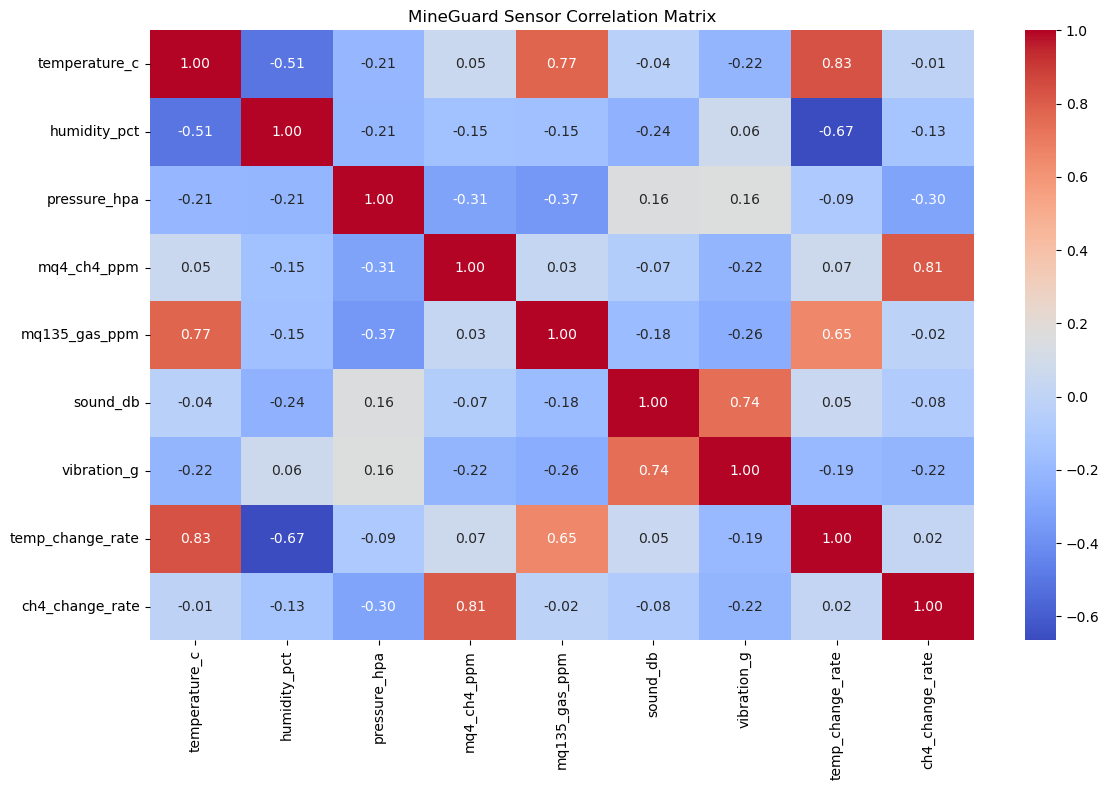

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("MineGuard Sensor Correlation Matrix")
plt.tight_layout()
plt.show()

In [20]:
risk_summary = df.groupby("Risk_Level")[sensor_columns].mean()

risk_summary

,temperature_c,humidity_pct,pressure_hpa,mq4_ch4_ppm,mq135_gas_ppm,sound_db,vibration_g,temp_change_rate,ch4_change_rate
Risk_Level,,,,,,,,,
Critical Danger,33.845830,53.521145,1009.709086,1354.266486,230.392149,76.940656,1.287864,0.833154,21.357508
High Risk,29.255152,69.423138,1008.861335,511.403466,242.194169,65.065738,2.012740,0.271351,6.695464
Moderate Risk,31.294396,88.425604,1005.914396,292.207033,279.972308,44.598022,0.111209,0.046088,0.993374
Safe,24.488057,62.109106,1013.176156,135.967844,62.673787,55.183007,0.151390,0.019393,0.465228


In [21]:
risk_summary.round(2)

,temperature_c,humidity_pct,pressure_hpa,mq4_ch4_ppm,mq135_gas_ppm,sound_db,vibration_g,temp_change_rate,ch4_change_rate
Risk_Level,,,,,,,,,
Critical Danger,33.85,53.52,1009.71,1354.27,230.39,76.94,1.29,0.83,21.36
High Risk,29.26,69.42,1008.86,511.40,242.19,65.07,2.01,0.27,6.70
Moderate Risk,31.29,88.43,1005.91,292.21,279.97,44.60,0.11,0.05,0.99
Safe,24.49,62.11,1013.18,135.97,62.67,55.18,0.15,0.02,0.47


In [22]:
# ==========================================
# MineGuard - Feature Relationship Check
# ==========================================

print("Temperature relationship")
print("=" * 50)

print(
    df[["temperature_c", "temp_change_rate"]]
    .corr()
)

print("\nMethane relationship")
print("=" * 50)

print(
    df[["mq4_ch4_ppm", "ch4_change_rate"]]
    .corr()
)

Temperature relationship
                  temperature_c  temp_change_rate
temperature_c           1.00000           0.83448
temp_change_rate        0.83448           1.00000

Methane relationship
                 mq4_ch4_ppm  ch4_change_rate
mq4_ch4_ppm          1.00000          0.80614
ch4_change_rate      0.80614          1.00000


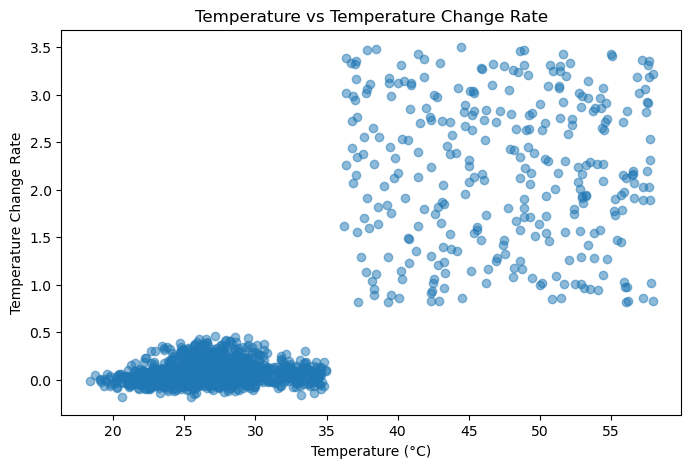

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["temperature_c"],
    df["temp_change_rate"],
    alpha=0.5
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Temperature Change Rate")
plt.title("Temperature vs Temperature Change Rate")

plt.show()

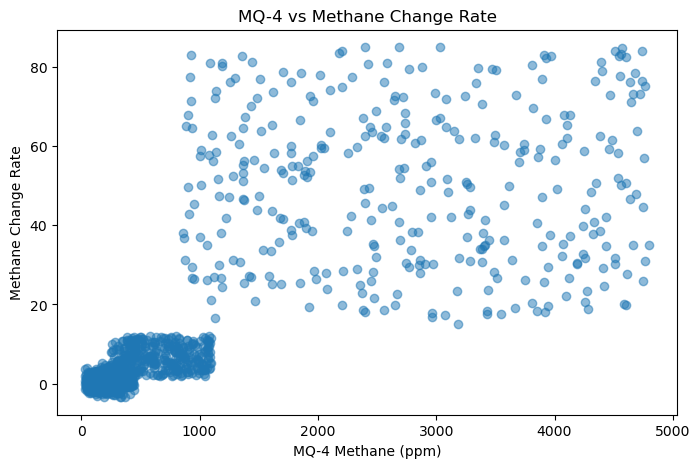

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["mq4_ch4_ppm"],
    df["ch4_change_rate"],
    alpha=0.5
)

plt.xlabel("MQ-4 Methane (ppm)")
plt.ylabel("Methane Change Rate")
plt.title("MQ-4 vs Methane Change Rate")

plt.show()

In [25]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [26]:
risk_hazard_table = pd.crosstab(
    df["Risk_Level"],
    df["Hazard_Type"]
)

risk_hazard_table

Hazard_Type,Methane Accumulation,Normal,Roof Fall / Rock Burst Risk,Spontaneous Combustion / Fire,Toxic Gas / Poor Ventilation,Worker Fall / Distress
Risk_Level,,,,,,
Critical Danger,269,0,239,269,0,0
High Risk,72,0,0,43,144,168
Moderate Risk,0,0,0,0,91,0
Safe,0,705,0,0,0,0


In [27]:
risk_hazard_percentage = pd.crosstab(
    df["Risk_Level"],
    df["Hazard_Type"],
    normalize="index"
) * 100

risk_hazard_percentage.round(2)

Hazard_Type,Methane Accumulation,Normal,Roof Fall / Rock Burst Risk,Spontaneous Combustion / Fire,Toxic Gas / Poor Ventilation,Worker Fall / Distress
Risk_Level,,,,,,
Critical Danger,34.62,0.0,30.76,34.62,0.00,0.00
High Risk,16.86,0.0,0.00,10.07,33.72,39.34
Moderate Risk,0.00,0.0,0.00,0.00,100.00,0.00
Safe,0.00,100.0,0.00,0.00,0.00,0.00


In [28]:
risk_action_table = pd.crosstab(
    df["Risk_Level"],
    df["Recommended_Action"]
)

risk_action_table

Recommended_Action,Activate Auxiliary Air Scrubbers & Ventilate,Boost Ventilation Fan Speed & Alert Sector,Dispatch Fire Inspection Team & Seal Airflow,Dispatch Medical Team & Locate Worker via LoRa Beacon,Immediate Evacuation & Cut Power Supply,Immediate Tunnel Evacuation: Structural Collapse Threat,Inspect Ventilation Ducts & Airflow Dampers,Maintain Regular Monitoring,Trigger Automated Fire Suppression & Evacuate
Risk_Level,,,,,,,,,
Critical Danger,0,0,0,0,269,239,0,0,269
High Risk,144,72,43,168,0,0,0,0,0
Moderate Risk,0,0,0,0,0,0,91,0,0
Safe,0,0,0,0,0,0,0,705,0


In [29]:
print("Checking feature correlations with target-related numeric variables")
print("=" * 60)

print(
    df.groupby("Risk_Level")[
        [
            "temperature_c",
            "humidity_pct",
            "pressure_hpa",
            "mq4_ch4_ppm",
            "mq135_gas_ppm",
            "sound_db",
            "vibration_g",
            "temp_change_rate",
            "ch4_change_rate"
        ]
    ].mean().round(2)
)

Checking feature correlations with target-related numeric variables
                 temperature_c  humidity_pct  pressure_hpa  mq4_ch4_ppm  \
Risk_Level                                                                
Critical Danger          33.85         53.52       1009.71      1354.27   
High Risk                29.26         69.42       1008.86       511.40   
Moderate Risk            31.29         88.43       1005.91       292.21   
Safe                     24.49         62.11       1013.18       135.97   

                 mq135_gas_ppm  sound_db  vibration_g  temp_change_rate  \
Risk_Level                                                                
Critical Danger         230.39     76.94         1.29              0.83   
High Risk               242.19     65.07         2.01              0.27   
Moderate Risk           279.97     44.60         0.11              0.05   
Safe                     62.67     55.18         0.15              0.02   

                 ch4_change_ra

In [30]:
FEATURES = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

In [31]:
TARGET = "Risk_Level"

In [32]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [33]:
print("Rows:", len(df))
print("Unique rows:", df.drop_duplicates().shape[0])

Rows: 2000
Unique rows: 2000


In [34]:
# ==========================================
# MineGuard - Raw Sensor Data Validation
# ==========================================

sensor_columns = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

print("=" * 60)
print("MINEGUARD SENSOR DATA VALIDATION")
print("=" * 60)

for column in sensor_columns:

    print(f"\n{column}")
    print("-" * 40)

    print("Minimum :", df[column].min())
    print("Maximum :", df[column].max())
    print("Mean    :", round(df[column].mean(), 3))
    print("Median  :", round(df[column].median(), 3))
    print("Std Dev :", round(df[column].std(), 3))

MINEGUARD SENSOR DATA VALIDATION

temperature_c
----------------------------------------
Minimum : 18.34
Maximum : 57.97
Mean    : 29.451
Median  : 26.28
Std Dev : 8.612

humidity_pct
----------------------------------------
Minimum : 28.09
Maximum : 95.89
Mean    : 61.532
Median  : 61.755
Std Dev : 14.249

pressure_hpa
----------------------------------------
Minimum : 993.79
Maximum : 1022.51
Mean    : 1010.578
Median  : 1011.05
Std Dev : 4.33

mq4_ch4_ppm
----------------------------------------
Minimum : 33.97
Maximum : 4796.87
Mean    : 696.541
Median  : 213.545
Std Dev : 1081.895

mq135_gas_ppm
----------------------------------------
Minimum : 20.76
Maximum : 679.03
Mean    : 176.047
Median  : 94.31
Std Dev : 165.612

sound_db
----------------------------------------
Minimum : 37.01
Maximum : 121.9
Mean    : 65.264
Median  : 60.595
Std Dev : 18.624

vibration_g
----------------------------------------
Minimum : 0.04
Maximum : 6.5
Mean    : 0.988
Median  : 0.21
Std Dev : 1.658


In [35]:
# ==========================================
# MineGuard AI - Data Cleaning
# ==========================================

clean_df = df.copy()

print("Original shape:", clean_df.shape)
print("Working on a copy of the raw dataset.")

Original shape: (2000, 12)
Working on a copy of the raw dataset.


In [36]:
# Standardize column names

clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
)

print(clean_df.columns.tolist())

['temperature_c', 'humidity_pct', 'pressure_hpa', 'mq4_ch4_ppm', 'mq135_gas_ppm', 'sound_db', 'vibration_g', 'temp_change_rate', 'ch4_change_rate', 'hazard_type', 'risk_level', 'recommended_action']


In [37]:
clean_df["mq4_ch4_ppm"]

0       1924.20
1        143.36
2        115.66
3        441.52
4        162.06
         ...   
1995    1067.57
1996     163.16
1997     171.46
1998     143.09
1999     135.85
Name: mq4_ch4_ppm, Length: 2000, dtype: float64

In [38]:
# Clean categorical columns

categorical_columns = [
    "hazard_type",
    "risk_level",
    "recommended_action"
]

for column in categorical_columns:
    clean_df[column] = (
        clean_df[column]
        .astype(str)
        .str.strip()
    )

print("Categorical values cleaned.")

Categorical values cleaned.


In [39]:
# Check missing values after cleaning

missing_values = clean_df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
temperature_c         0
humidity_pct          0
pressure_hpa          0
mq4_ch4_ppm           0
mq135_gas_ppm         0
sound_db              0
vibration_g           0
temp_change_rate      0
ch4_change_rate       0
hazard_type           0
risk_level            0
recommended_action    0
dtype: int64


In [40]:
# Check infinite values

numeric_columns = clean_df.select_dtypes(
    include=np.number
).columns

infinite_values = np.isinf(
    clean_df[numeric_columns]
).sum()

print("Infinite values:")
print(infinite_values)

Infinite values:
temperature_c       0
humidity_pct        0
pressure_hpa        0
mq4_ch4_ppm         0
mq135_gas_ppm       0
sound_db            0
vibration_g         0
temp_change_rate    0
ch4_change_rate     0
dtype: int64


In [41]:
# ==========================================
# Numerical Data Validation
# ==========================================

sensor_columns = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g",
    "temp_change_rate",
    "ch4_change_rate"
]

for column in sensor_columns:
    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors="coerce"
    )

print(clean_df[sensor_columns].dtypes)

temperature_c       float64
humidity_pct        float64
pressure_hpa        float64
mq4_ch4_ppm         float64
mq135_gas_ppm       float64
sound_db            float64
vibration_g         float64
temp_change_rate    float64
ch4_change_rate     float64
dtype: object


In [42]:
# ==========================================
# Physical Range Validation
# ==========================================

non_negative_columns = [
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

print("Negative value check")
print("=" * 50)

for column in non_negative_columns:
    
    count = (clean_df[column] < 0).sum()
    
    print(f"{column:20s}: {count}")

Negative value check
humidity_pct        : 0
pressure_hpa        : 0
mq4_ch4_ppm         : 0
mq135_gas_ppm       : 0
sound_db            : 0
vibration_g         : 0


In [43]:
# ==========================================
# Risk Label Validation
# ==========================================

expected_risk_levels = {
    "Safe",
    "Moderate Risk",
    "High Risk",
    "Critical Danger"
}

actual_risk_levels = set(
    clean_df["risk_level"].unique()
)

print("Expected risk levels:")
print(expected_risk_levels)

print("\nActual risk levels:")
print(actual_risk_levels)

unexpected_risk_levels = actual_risk_levels - expected_risk_levels

print("\nUnexpected risk levels:")
print(unexpected_risk_levels)

Expected risk levels:
{'Safe', 'High Risk', 'Moderate Risk', 'Critical Danger'}

Actual risk levels:
{'High Risk', 'Moderate Risk', 'Critical Danger', 'Safe'}

Unexpected risk levels:
set()


In [44]:
expected_hazards = {
    "Normal",
    "Methane Accumulation",
    "Spontaneous Combustion / Fire",
    "Roof Fall / Rock Burst Risk",
    "Toxic Gas / Poor Ventilation",
    "Worker Fall / Distress"
}

actual_hazards = set(
    clean_df["hazard_type"].unique()
)

print("Unexpected hazard types:")
print(actual_hazards - expected_hazards)

Unexpected hazard types:
set()


In [45]:
print("=" * 60)
print("FINAL CLEAN DATASET CHECK")
print("=" * 60)

print("Shape:", clean_df.shape)

print("\nMissing values:")
print(clean_df.isnull().sum().sum())

print("\nDuplicate rows:")
print(clean_df.duplicated().sum())

print("\nRisk distribution:")
print(clean_df["risk_level"].value_counts())

print("\nHazard distribution:")
print(clean_df["hazard_type"].value_counts())

FINAL CLEAN DATASET CHECK
Shape: (2000, 12)

Missing values:
0

Duplicate rows:
0

Risk distribution:
risk_level
Critical Danger    777
Safe               705
High Risk          427
Moderate Risk       91
Name: count, dtype: int64

Hazard distribution:
hazard_type
Normal                           705
Methane Accumulation             341
Spontaneous Combustion / Fire    312
Roof Fall / Rock Burst Risk      239
Toxic Gas / Poor Ventilation     235
Worker Fall / Distress           168
Name: count, dtype: int64


In [46]:
# Save cleaned dataset

clean_df.to_csv(
    "MineGuard_Cleaned.csv",
    index=False
)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [47]:
BASE_FEATURES = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

In [48]:
TARGET = "risk_level"

In [49]:
# ==========================================
# MineGuard AI - ML Data Preparation
# ==========================================

import pandas as pd
import numpy as np

ml_df = pd.read_csv("MineGuard_Cleaned.csv")

print("Dataset loaded.")
print("Shape:", ml_df.shape)

Dataset loaded.
Shape: (2000, 12)


In [50]:
# Features used by the baseline ML model

FEATURES = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

TARGET = "risk_level"

X = ml_df[FEATURES]
y = ml_df[TARGET]

print("Features:")
print(FEATURES)

print("\nTarget:")
print(TARGET)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['temperature_c', 'humidity_pct', 'pressure_hpa', 'mq4_ch4_ppm', 'mq135_gas_ppm', 'sound_db', 'vibration_g']

Target:
risk_level

X shape: (2000, 7)
y shape: (2000,)


In [51]:
print("X:")
display(X.head())

print("\ny:")
display(y.head())

X:


,temperature_c,humidity_pct,pressure_hpa,mq4_ch4_ppm,mq135_gas_ppm,sound_db,vibration_g
0,25.24,55.04,1007.09,1924.20,161.13,64.94,0.21
1,24.96,50.45,1014.65,143.36,120.99,70.55,5.39
2,21.87,61.35,1014.38,115.66,85.23,103.77,5.10
3,38.51,31.02,1014.08,441.52,335.44,69.40,0.31
4,26.57,60.52,1013.66,162.06,60.22,47.40,0.24



y:


0          High Risk
1          High Risk
2    Critical Danger
3          High Risk
4               Safe
Name: risk_level, dtype: object

In [52]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Risk classes:")
print(label_encoder.classes_)

Risk classes:
['Critical Danger' 'High Risk' 'Moderate Risk' 'Safe']


In [53]:
for number, label in enumerate(label_encoder.classes_):
    print(number, "→", label)

0 → Critical Danger
1 → High Risk
2 → Moderate Risk
3 → Safe


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 1600
Testing samples : 400


In [55]:
print("Training class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training class distribution:
0    622
1    341
2     73
3    564
Name: count, dtype: int64

Testing class distribution:
0    155
1     86
2     18
3    141
Name: count, dtype: int64


In [56]:
print("Training features:")
print(X_train.columns.tolist())

print("\nTest features:")
print(X_test.columns.tolist())

Training features:
['temperature_c', 'humidity_pct', 'pressure_hpa', 'mq4_ch4_ppm', 'mq135_gas_ppm', 'sound_db', 'vibration_g']

Test features:
['temperature_c', 'humidity_pct', 'pressure_hpa', 'mq4_ch4_ppm', 'mq135_gas_ppm', 'sound_db', 'vibration_g']


In [57]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [58]:
y_pred = rf_model.predict(X_test)

print("Predictions generated.")
print("Number of predictions:", len(y_pred))

Predictions generated.
Number of predictions: 400


In [59]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", round(accuracy * 100, 2), "%")

Random Forest Accuracy: 95.5 %


In [60]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        digits=4
    )
)

                 precision    recall  f1-score   support

Critical Danger     0.9255    0.9613    0.9430       155
      High Risk     0.9250    0.8605    0.8916        86
  Moderate Risk     1.0000    1.0000    1.0000        18
           Safe     1.0000    1.0000    1.0000       141

       accuracy                         0.9550       400
      macro avg     0.9626    0.9554    0.9587       400
   weighted avg     0.9550    0.9550    0.9546       400



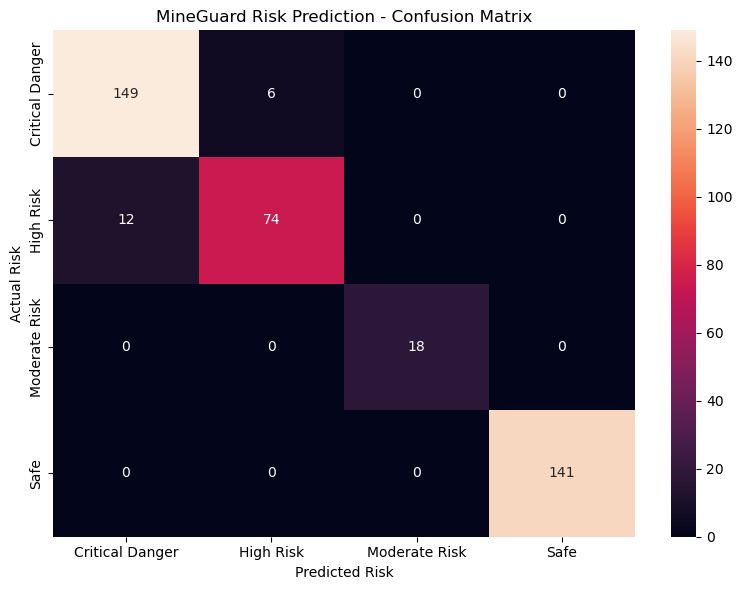

In [61]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.title("MineGuard Risk Prediction - Confusion Matrix")

plt.tight_layout()
plt.show()

In [62]:
feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

         Feature  Importance
4  mq135_gas_ppm    0.256264
5       sound_db    0.178413
1   humidity_pct    0.147827
6    vibration_g    0.146407
3    mq4_ch4_ppm    0.134929
0  temperature_c    0.102970
2   pressure_hpa    0.033191


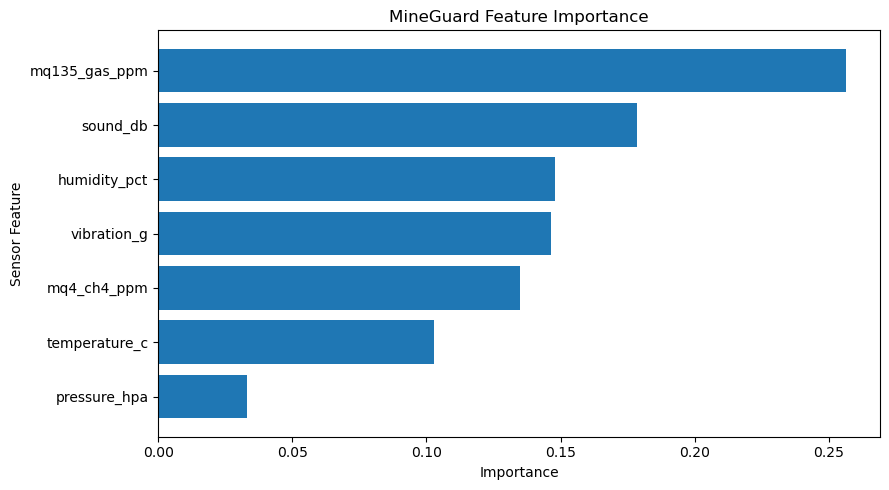

In [63]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Sensor Feature")
plt.title("MineGuard Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## PHASE 4 — Decision Tree Baseline

In [64]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


In [65]:
dt_pred = dt_model.predict(X_test)

print("Decision Tree predictions generated.")

Decision Tree predictions generated.


In [66]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy * 100, 2),
    "%"
)

Decision Tree Accuracy: 95.5 %


In [67]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        dt_pred,
        target_names=label_encoder.classes_,
        digits=4
    )
)

                 precision    recall  f1-score   support

Critical Danger     0.9477    0.9355    0.9416       155
      High Risk     0.8864    0.9070    0.8966        86
  Moderate Risk     1.0000    1.0000    1.0000        18
           Safe     1.0000    1.0000    1.0000       141

       accuracy                         0.9550       400
      macro avg     0.9585    0.9606    0.9595       400
   weighted avg     0.9553    0.9550    0.9551       400



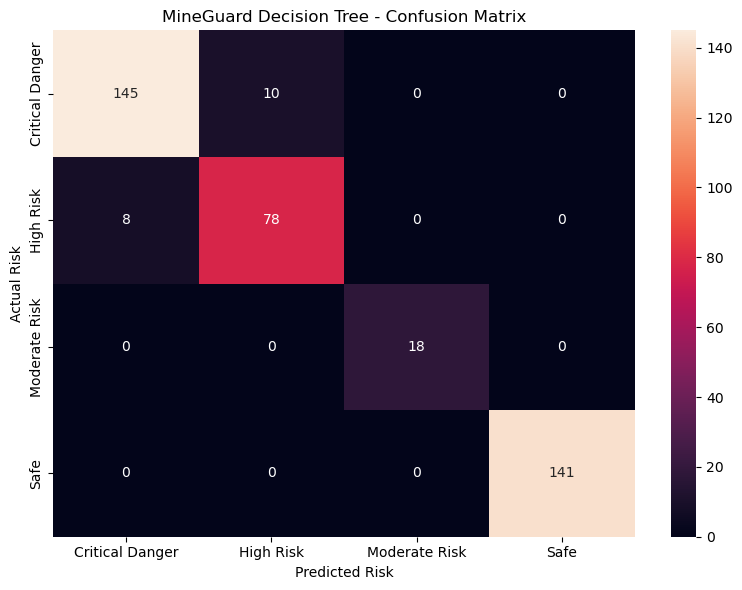

In [68]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.title("MineGuard Decision Tree - Confusion Matrix")

plt.tight_layout()
plt.show()

In [69]:
dt_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": dt_model.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

print(dt_importance)

         Feature  Importance
1   humidity_pct    0.258433
6    vibration_g    0.233808
4  mq135_gas_ppm    0.207230
3    mq4_ch4_ppm    0.202566
0  temperature_c    0.047872
5       sound_db    0.043661
2   pressure_hpa    0.006431


## Xg Boost Model 

In [70]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [71]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [72]:
xgb_pred = xgb_model.predict(X_test)

print("XGBoost predictions generated.")

XGBoost predictions generated.


In [73]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(
    "XGBoost Accuracy:",
    round(xgb_accuracy * 100, 2),
    "%"
)

XGBoost Accuracy: 94.5 %


In [74]:
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=label_encoder.classes_,
        digits=4
    )
)

                 precision    recall  f1-score   support

Critical Danger     0.9236    0.9355    0.9295       155
      High Risk     0.8810    0.8605    0.8706        86
  Moderate Risk     1.0000    1.0000    1.0000        18
           Safe     1.0000    1.0000    1.0000       141

       accuracy                         0.9450       400
      macro avg     0.9511    0.9490    0.9500       400
   weighted avg     0.9448    0.9450    0.9449       400



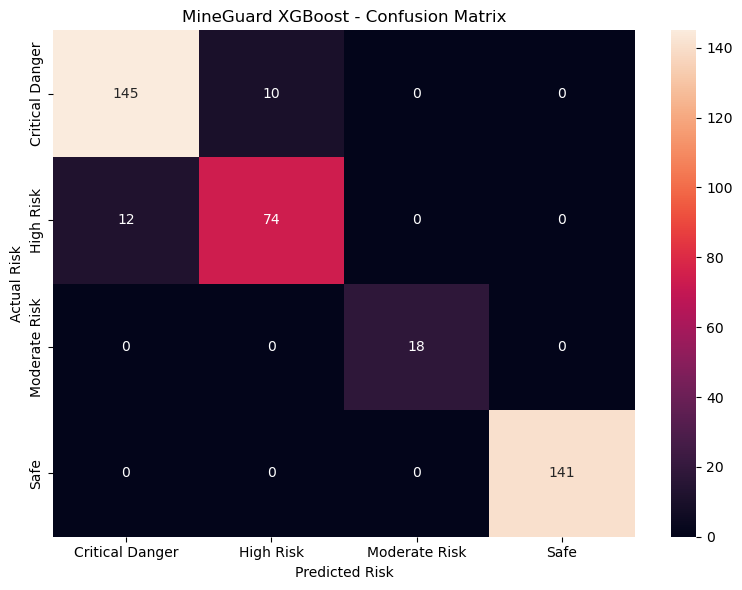

In [75]:
xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.title("MineGuard XGBoost - Confusion Matrix")

plt.tight_layout()
plt.show()

In [76]:
xgb_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print(xgb_importance)

         Feature  Importance
3    mq4_ch4_ppm    0.229232
6    vibration_g    0.210289
5       sound_db    0.171251
4  mq135_gas_ppm    0.159074
1   humidity_pct    0.124684
0  temperature_c    0.076522
2   pressure_hpa    0.028948


## PHASE 6 — Model Cross-Validation

In [77]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ==========================================
# Stratified 5-Fold Cross Validation
# ==========================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------
# Models
# ------------------------------------------

models = {

    "Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=len(label_encoder.classes_),
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )
}

# ------------------------------------------
# Evaluation metrics
# ------------------------------------------

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
    "critical_recall": "recall_macro"
}

# ------------------------------------------
# Run CV
# ------------------------------------------

cv_results = []

for name, model in models.items():

    print(f"\nRunning: {name}")

    results = cross_validate(
        model,
        X,
        y_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy Mean": results["test_accuracy"].mean(),
        "Accuracy Std": results["test_accuracy"].std(),
        "Macro F1 Mean": results["test_macro_f1"].mean(),
        "Macro F1 Std": results["test_macro_f1"].std(),
        "Weighted F1 Mean": results["test_weighted_f1"].mean(),
        "Critical Recall Mean": results["test_critical_recall"].mean()
    })

cv_summary = pd.DataFrame(cv_results)

print("\n==========================================")
print("MINEGUARD 5-FOLD CROSS-VALIDATION")
print("==========================================")

display(
    cv_summary.round(4)
)


Running: Decision Tree

Running: Random Forest

Running: XGBoost

MINEGUARD 5-FOLD CROSS-VALIDATION


,Model,Accuracy Mean,Accuracy Std,Macro F1 Mean,Macro F1 Std,Weighted F1 Mean,Critical Recall Mean
0,Decision Tree,0.9425,0.0055,0.9463,0.0046,0.9423,0.9439
1,Random Forest,0.9470,0.0124,0.9495,0.0111,0.9462,0.9462
2,XGBoost,0.9505,0.0118,0.9535,0.0107,0.9502,0.9529


In [78]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import recall_score

critical_class = list(label_encoder.classes_).index("Critical Danger")

critical_cv_results = []

for name, model in models.items():

    cv_pred = cross_val_predict(
        model,
        X,
        y_encoded,
        cv=cv,
        n_jobs=-1,
        method="predict"
    )

    critical_recall = recall_score(
        y_encoded,
        cv_pred,
        labels=[critical_class],
        average=None
    )[0]

    critical_cv_results.append({
        "Model": name,
        "Critical Danger Recall": critical_recall
    })

critical_summary = pd.DataFrame(critical_cv_results)

print("==========================================")
print("CRITICAL DANGER CROSS-VALIDATION RECALL")
print("==========================================")

display(
    critical_summary.round(4)
)

CRITICAL DANGER CROSS-VALIDATION RECALL


,Model,Critical Danger Recall
0,Decision Tree,0.9344
1,Random Forest,0.9601
2,XGBoost,0.9472


In [79]:
final_cv_comparison = cv_summary[
    [
        "Model",
        "Accuracy Mean",
        "Accuracy Std",
        "Macro F1 Mean",
        "Macro F1 Std",
        "Weighted F1 Mean"
    ]
].merge(
    critical_summary,
    on="Model"
)

print("==========================================")
print("MINEGUARD MODEL LEADERBOARD")
print("==========================================")

display(
    final_cv_comparison.round(4)
)

MINEGUARD MODEL LEADERBOARD


,Model,Accuracy Mean,Accuracy Std,Macro F1 Mean,Macro F1 Std,Weighted F1 Mean,Critical Danger Recall
0,Decision Tree,0.9425,0.0055,0.9463,0.0046,0.9423,0.9344
1,Random Forest,0.9470,0.0124,0.9495,0.0111,0.9462,0.9601
2,XGBoost,0.9505,0.0118,0.9535,0.0107,0.9502,0.9472


In [80]:
print("Temporal Feature Statistics")
print("=" * 50)

print("\nTemperature Change Rate:")
print(ml_df["temp_change_rate"].describe())

print("\nMethane Change Rate:")
print(ml_df["ch4_change_rate"].describe())

Temporal Feature Statistics

Temperature Change Rate:
count    2000.000000
mean        0.390547
std         0.837165
min        -0.183000
25%         0.001000
50%         0.050000
75%         0.203000
max         3.498000
Name: temp_change_rate, dtype: float64

Methane Change Rate:
count    2000.000000
mean        9.936065
std        20.035115
min        -3.390000
25%         0.009750
50%         1.311500
75%         6.834250
max        84.865000
Name: ch4_change_rate, dtype: float64


In [81]:
print("\nFirst 15 temporal feature values:")
display(
    ml_df[
        [
            "temperature_c",
            "temp_change_rate",
            "mq4_ch4_ppm",
            "ch4_change_rate"
        ]
    ].head(15)
)


First 15 temporal feature values:


,temperature_c,temp_change_rate,mq4_ch4_ppm,ch4_change_rate
0,25.24,0.147,1924.20,19.386
1,24.96,0.003,143.36,0.516
2,21.87,-0.040,115.66,-1.415
3,38.51,1.110,441.52,10.601
4,26.57,0.017,162.06,1.024
5,26.13,0.089,153.56,-0.254
6,25.58,0.046,107.36,1.560
7,31.77,0.059,181.64,-1.877
8,42.32,2.239,928.23,3.580
9,26.97,-0.007,243.11,-0.347


In [82]:
print("Temporal Feature Correlations")
print("=" * 50)

print(
    ml_df[
        [
            "temperature_c",
            "temp_change_rate",
            "mq4_ch4_ppm",
            "ch4_change_rate"
        ]
    ].corr().round(3)
)

Temporal Feature Correlations
                  temperature_c  temp_change_rate  mq4_ch4_ppm  \
temperature_c             1.000             0.834        0.051   
temp_change_rate          0.834             1.000        0.068   
mq4_ch4_ppm               0.051             0.068        1.000   
ch4_change_rate          -0.012             0.018        0.806   

                  ch4_change_rate  
temperature_c              -0.012  
temp_change_rate            0.018  
mq4_ch4_ppm                 0.806  
ch4_change_rate             1.000  


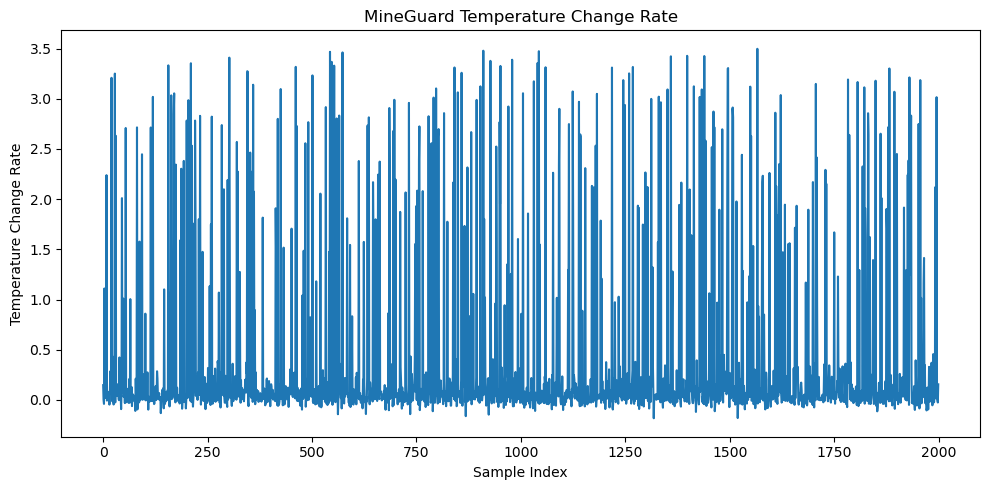

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    ml_df["temp_change_rate"].values
)

plt.xlabel("Sample Index")
plt.ylabel("Temperature Change Rate")
plt.title("MineGuard Temperature Change Rate")

plt.tight_layout()
plt.show()

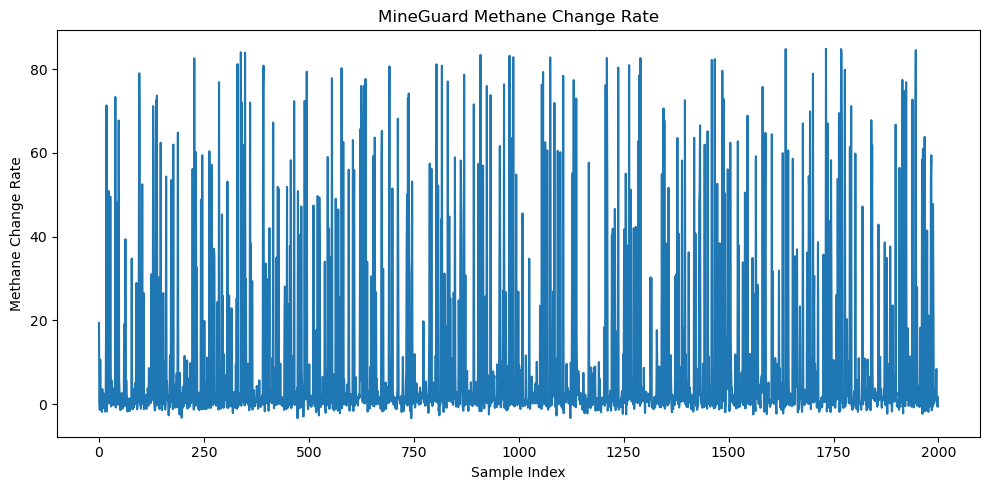

In [84]:
plt.figure(figsize=(10, 5))

plt.plot(
    ml_df["ch4_change_rate"].values
)

plt.xlabel("Sample Index")
plt.ylabel("Methane Change Rate")
plt.title("MineGuard Methane Change Rate")

plt.tight_layout()
plt.show()

In [85]:
import numpy as np

temp_diff = df["temperature_c"].diff()

comparison_temp = pd.DataFrame({
    "temperature_c": df["temperature_c"],
    "temp_change_rate": df["temp_change_rate"],
    "actual_difference": temp_diff
})

display(comparison_temp.head(20))

,temperature_c,temp_change_rate,actual_difference
0,25.24,0.147,NaN
1,24.96,0.003,-0.28
2,21.87,-0.040,-3.09
3,38.51,1.110,16.64
4,26.57,0.017,-11.94
5,26.13,0.089,-0.44
6,25.58,0.046,-0.55
7,31.77,0.059,6.19
8,42.32,2.239,10.55
9,26.97,-0.007,-15.35


In [95]:
ch4_diff = df["mq4_ch4_ppm"].diff()

comparison_ch4 = pd.DataFrame({
    "mq4_ch4_ppm": df["mq4_ch4_ppm"],
    "ch4_change_rate": df["ch4_change_rate"],
    "actual_difference": ch4_diff
})

display(comparison_ch4.head(20))

,mq4_ch4_ppm,ch4_change_rate,actual_difference
0,1924.20,19.386,NaN
1,143.36,0.516,-1780.84
2,115.66,-1.415,-27.70
3,441.52,10.601,325.86
4,162.06,1.024,-279.46
5,153.56,-0.254,-8.50
6,107.36,1.560,-46.20
7,181.64,-1.877,74.28
8,928.23,3.580,746.59
9,243.11,-0.347,-685.12


In [96]:
temp_pct = df["temperature_c"].pct_change()
ch4_pct = df["mq4_ch4_ppm"].pct_change()

print("Temperature:")
display(
    pd.DataFrame({
        "existing": df["temp_change_rate"],
        "pct_change": temp_pct
    }).head(20)
)

print("\nMethane:")
display(
    pd.DataFrame({
        "existing": df["ch4_change_rate"],
        "pct_change": ch4_pct
    }).head(20)
)

Temperature:


,existing,pct_change
0,0.147,NaN
1,0.003,-0.011094
2,-0.040,-0.123798
3,1.110,0.760860
4,0.017,-0.310049
5,0.089,-0.016560
6,0.046,-0.021049
7,0.059,0.241986
8,2.239,0.332074
9,-0.007,-0.362713



Methane:


,existing,pct_change
0,19.386,NaN
1,0.516,-0.925496
2,-1.415,-0.193220
3,10.601,2.817396
4,1.024,-0.632950
5,-0.254,-0.052450
6,1.560,-0.300860
7,-1.877,0.691878
8,3.580,4.110273
9,-0.347,-0.738093


In [97]:
print("Temperature change-rate correlation:")
print(
    df["temp_change_rate"]
    .corr(df["temperature_c"].diff())
)

print("\nMethane change-rate correlation:")
print(
    df["ch4_change_rate"]
    .corr(df["mq4_ch4_ppm"].diff())
)

Temperature change-rate correlation:
0.5942219592566549

Methane change-rate correlation:
0.5578184765107029


In [98]:
print("FEATURES USED BY MINEGUARD")
print("=" * 50)

for feature in FEATURES:
    print(feature)

print("\nNumber of features:", len(FEATURES))

print("\nTarget:")
print("Risk_Level")


FEATURES USED BY MINEGUARD
temperature_c
humidity_pct
pressure_hpa
mq4_ch4_ppm
mq135_gas_ppm
sound_db
vibration_g

Number of features: 7

Target:
Risk_Level


In [99]:
import numpy as np

print("MineGuard Training Target Distribution")
print("=" * 50)

counts = np.bincount(y_train)

for class_id, count in enumerate(counts):
    class_name = label_encoder.inverse_transform([class_id])[0]
    print(f"{class_name:<20} {count}")

print("\nPercentage Distribution")
print("=" * 50)

total = len(y_train)

for class_id, count in enumerate(counts):
    class_name = label_encoder.inverse_transform([class_id])[0]
    percentage = (count / total) * 100
    print(f"{class_name:<20} {percentage:.2f}%")

MineGuard Training Target Distribution
Critical Danger      622
High Risk            341
Moderate Risk        73
Safe                 564

Percentage Distribution
Critical Danger      38.88%
High Risk            21.31%
Moderate Risk        4.56%
Safe                 35.25%


In [100]:
np.bincount(y_train)      

array([622, 341,  73, 564])

In [101]:
print("Label Mapping")
print("=" * 50)

for i, label in enumerate(label_encoder.classes_):
    print(i, "→", label)

Label Mapping
0 → Critical Danger
1 → High Risk
2 → Moderate Risk
3 → Safe


In [102]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross-Validation created successfully!")

5-Fold Stratified Cross-Validation created successfully!


In [103]:
# ============================================
# REBUILD MINEGUARD TRAINING DATA
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

FEATURES = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

TARGET = "Risk_Level"

# Features
X = df[FEATURES].copy()

# Target
y = df[TARGET].copy()

# Encode target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("MineGuard training data rebuilt successfully!")
print("=" * 50)

print("Total samples :", len(X))
print("Training      :", len(X_train))
print("Testing       :", len(X_test))
print("Features      :", X.shape[1])

print("\nLabel Mapping")
print("=" * 50)

for i, label in enumerate(label_encoder.classes_):
    print(f"{i} → {label}")

print("\nTraining Target Distribution")
print("=" * 50)

import numpy as np

counts = np.bincount(y_train)

for class_id, count in enumerate(counts):
    label = label_encoder.inverse_transform([class_id])[0]
    print(f"{label:<20} {count}")

MineGuard training data rebuilt successfully!
Total samples : 2000
Training      : 1600
Testing       : 400
Features      : 7

Label Mapping
0 → Critical Danger
1 → High Risk
2 → Moderate Risk
3 → Safe

Training Target Distribution
Critical Danger      622
High Risk            341
Moderate Risk        73
Safe                 564


In [104]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_params = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 5, 8, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=30,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("\n" + "=" * 60)
print("BEST RANDOM FOREST RESULTS")
print("=" * 60)

print("\nBest Parameters:")
print(rf_search.best_params_)

print("\nBest CV Macro F1:")
print(round(rf_search.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

BEST RANDOM FOREST RESULTS

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}

Best CV Macro F1:
0.9434


In [105]:
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,30
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [106]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Best tuned Random Forest
best_rf = rf_search.best_estimator_

# Prediction on untouched test set
rf_tuned_pred = best_rf.predict(X_test)

# Accuracy
rf_tuned_accuracy = accuracy_score(
    y_test,
    rf_tuned_pred
)

print("=" * 60)
print("MINEGUARD TUNED RANDOM FOREST - TEST RESULTS")
print("=" * 60)

print(f"\nTest Accuracy: {rf_tuned_accuracy:.4f}")
print(f"Test Accuracy: {rf_tuned_accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        rf_tuned_pred,
        target_names=label_encoder.classes_,
        digits=4
    )
)

# Confusion matrix
cm_rf_tuned = confusion_matrix(
    y_test,
    rf_tuned_pred
)

print("\nConfusion Matrix")
print("=" * 60)
print(cm_rf_tuned)

# Critical Danger Recall
critical_class = 0

critical_recall = (
    cm_rf_tuned[critical_class, critical_class]
    / cm_rf_tuned[critical_class].sum()
)

print("\nCritical Danger Recall")
print("=" * 60)
print(f"{critical_recall:.4f}")
print(f"{critical_recall * 100:.2f}%")

MINEGUARD TUNED RANDOM FOREST - TEST RESULTS

Test Accuracy: 0.9575
Test Accuracy: 95.75%

Classification Report
                 precision    recall  f1-score   support

Critical Danger     0.9423    0.9484    0.9453       155
      High Risk     0.9059    0.8953    0.9006        86
  Moderate Risk     1.0000    1.0000    1.0000        18
           Safe     1.0000    1.0000    1.0000       141

       accuracy                         0.9575       400
      macro avg     0.9620    0.9609    0.9615       400
   weighted avg     0.9574    0.9575    0.9574       400


Confusion Matrix
[[147   8   0   0]
 [  9  77   0   0]
 [  0   0  18   0]
 [  0   0   0 141]]

Critical Danger Recall
0.9484
94.84%


In [107]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# ============================================
# MINEGUARD XGBOOST HYPERPARAMETER TUNING
# ============================================

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_params = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=30,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# IMPORTANT:
# Tune ONLY on training data
xgb_search.fit(X_train, y_train)

print("\n" + "=" * 60)
print("BEST XGBOOST RESULTS")
print("=" * 60)

print("\nBest Parameters:")
print(xgb_search.best_params_)

print("\nBest CV Macro F1:")
print(round(xgb_search.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

BEST XGBOOST RESULTS

Best Parameters:
{'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.8}

Best CV Macro F1:
0.9462


In [108]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================
# MINEGUARD TUNED XGBOOST - TEST EVALUATION
# ============================================

best_xgb = xgb_search.best_estimator_

# Predict on untouched test set
xgb_tuned_pred = best_xgb.predict(X_test)

# Accuracy
xgb_tuned_accuracy = accuracy_score(
    y_test,
    xgb_tuned_pred
)

print("=" * 60)
print("MINEGUARD TUNED XGBOOST - TEST RESULTS")
print("=" * 60)

print(f"\nTest Accuracy: {xgb_tuned_accuracy:.4f}")
print(f"Test Accuracy: {xgb_tuned_accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        xgb_tuned_pred,
        target_names=label_encoder.classes_,
        digits=4
    )
)

# Confusion matrix
cm_xgb_tuned = confusion_matrix(
    y_test,
    xgb_tuned_pred
)

print("\nConfusion Matrix")
print("=" * 60)
print(cm_xgb_tuned)

# Critical Danger Recall
critical_class = 0

critical_recall = (
    cm_xgb_tuned[critical_class, critical_class]
    / cm_xgb_tuned[critical_class].sum()
)

print("\nCritical Danger Recall")
print("=" * 60)
print(f"{critical_recall:.4f}")
print(f"{critical_recall * 100:.2f}%")

MINEGUARD TUNED XGBOOST - TEST RESULTS

Test Accuracy: 0.9450
Test Accuracy: 94.50%

Classification Report
                 precision    recall  f1-score   support

Critical Danger     0.9182    0.9419    0.9299       155
      High Risk     0.8902    0.8488    0.8690        86
  Moderate Risk     1.0000    1.0000    1.0000        18
           Safe     1.0000    1.0000    1.0000       141

       accuracy                         0.9450       400
      macro avg     0.9521    0.9477    0.9497       400
   weighted avg     0.9447    0.9450    0.9447       400


Confusion Matrix
[[146   9   0   0]
 [ 13  73   0   0]
 [  0   0  18   0]
 [  0   0   0 141]]

Critical Danger Recall
0.9419
94.19%


In [112]:
# ============================================================
# MINEGUARD - REBUILD BASELINE RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

print("=" * 65)
print("REBUILDING MINEGUARD BASELINE RANDOM FOREST")
print("=" * 65)

# Create baseline Random Forest
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train ONLY on training data
rf.fit(X_train, y_train)

print("\nBaseline Random Forest trained successfully!")

print("Training samples:", X_train.shape[0])
print("Features:", X_train.shape[1])

print("\nRandom Forest Classes:")
print(rf.classes_)

REBUILDING MINEGUARD BASELINE RANDOM FOREST

Baseline Random Forest trained successfully!
Training samples: 1600
Features: 7

Random Forest Classes:
[0 1 2 3]


In [113]:
# ============================================================
# MINEGUARD BASELINE RANDOM FOREST
# FOUR RISK PROBABILITIES
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("MINEGUARD BASELINE RANDOM FOREST - RISK PROBABILITIES")
print("=" * 70)

# ------------------------------------------------------------
# Generate probabilities
# ------------------------------------------------------------

rf_probabilities = rf.predict_proba(X_test)

# ------------------------------------------------------------
# Convert encoded classes to actual risk names
# ------------------------------------------------------------

risk_classes = label_encoder.inverse_transform(rf.classes_)

print("\nRandom Forest Class Order:")
for encoded, name in zip(rf.classes_, risk_classes):
    print(f"{encoded} -> {name}")

# ------------------------------------------------------------
# Create probability DataFrame
# ------------------------------------------------------------

risk_probability_df = pd.DataFrame(
    rf_probabilities,
    columns=risk_classes
)

# ------------------------------------------------------------
# Percentage probabilities
# ------------------------------------------------------------

risk_probability_percent = (
    risk_probability_df * 100
).round(2)

# ------------------------------------------------------------
# Predicted risk
# ------------------------------------------------------------

risk_probability_percent["Predicted_Risk"] = (
    risk_probability_df.idxmax(axis=1)
)

# ------------------------------------------------------------
# Actual risk
# ------------------------------------------------------------

risk_probability_percent["Actual_Risk"] = (
    label_encoder.inverse_transform(y_test)
)

# ------------------------------------------------------------
# Confidence
# ------------------------------------------------------------

risk_probability_percent["Confidence_%"] = (
    risk_probability_df.max(axis=1) * 100
).round(2)

# ------------------------------------------------------------
# Display first 20
# ------------------------------------------------------------

print("\nFirst 20 MineGuard Risk Predictions")
print("=" * 70)

display(
    risk_probability_percent[
        [
            "Critical Danger",
            "High Risk",
            "Moderate Risk",
            "Safe",
            "Predicted_Risk",
            "Confidence_%",
            "Actual_Risk"
        ]
    ].head(20)
)

MINEGUARD BASELINE RANDOM FOREST - RISK PROBABILITIES

Random Forest Class Order:
0 -> Critical Danger
1 -> High Risk
2 -> Moderate Risk
3 -> Safe

First 20 MineGuard Risk Predictions


,Critical Danger,High Risk,Moderate Risk,Safe,Predicted_Risk,Confidence_%,Actual_Risk
0,3.0,3.0,0.0,94.0,Safe,94.0,Safe
1,0.0,2.0,98.0,0.0,Moderate Risk,98.0,Moderate Risk
2,91.0,5.0,0.0,4.0,Critical Danger,91.0,Critical Danger
3,99.0,1.0,0.0,0.0,Critical Danger,99.0,Critical Danger
4,0.0,98.0,2.0,0.0,High Risk,98.0,High Risk
5,96.0,4.0,0.0,0.0,Critical Danger,96.0,Critical Danger
6,36.0,63.0,0.0,1.0,High Risk,63.0,High Risk
7,47.0,53.0,0.0,0.0,High Risk,53.0,High Risk
8,0.0,100.0,0.0,0.0,High Risk,100.0,High Risk
9,0.0,0.0,0.0,100.0,Safe,100.0,Safe


In [114]:
# ============================================================
# MINEGUARD RANDOM FOREST - CONFIDENCE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("MINEGUARD RANDOM FOREST - CONFIDENCE ANALYSIS")
print("=" * 70)

# Average probability for each class
average_probabilities = (
    risk_probability_df.mean() * 100
).round(2)

print("\nAverage Risk Probability (%)")
print("=" * 70)

print(average_probabilities)

# Overall confidence
confidence_values = (
    risk_probability_df.max(axis=1) * 100
)

print("\nModel Confidence")
print("=" * 70)

print(
    f"Average Confidence : {confidence_values.mean():.2f}%"
)

print(
    f"Minimum Confidence : {confidence_values.min():.2f}%"
)

print(
    f"Maximum Confidence : {confidence_values.max():.2f}%"
)


MINEGUARD RANDOM FOREST - CONFIDENCE ANALYSIS

Average Risk Probability (%)
Critical Danger    38.64
High Risk          22.23
Moderate Risk       4.18
Safe               34.94
dtype: float64

Model Confidence
Average Confidence : 90.91%
Minimum Confidence : 51.00%
Maximum Confidence : 100.00%


In [117]:
# ============================================================
# MINEGUARD - CRITICAL DANGER PROBABILITY ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("MINEGUARD CRITICAL DANGER PROBABILITY ANALYSIS")
print("=" * 70)

critical_predictions = risk_probability_percent[
    risk_probability_percent["Predicted_Risk"] == "Critical Danger"
].copy()

print(
    "\nNumber of Critical Danger Predictions:",
    len(critical_predictions)
)

if len(critical_predictions) > 0:

    print("\nCritical Danger Probability Statistics")
    print("=" * 70)

    print(
        critical_predictions[
            "Critical Danger"
        ].describe().round(2)
    )

    print("\nFirst 20 Critical Danger Predictions")
    print("=" * 70)

    display(
        critical_predictions[
            [
                "Critical Danger",
                "High Risk",
                "Moderate Risk",
                "Safe",
                "Predicted_Risk",
                "Confidence_%",
                "Actual_Risk"
            ]
        ].head(20)
    )


MINEGUARD CRITICAL DANGER PROBABILITY ANALYSIS

Number of Critical Danger Predictions: 163

Critical Danger Probability Statistics
count    163.00
mean      87.81
std       14.20
min       51.00
25%       83.00
50%       94.00
75%       98.00
max      100.00
Name: Critical Danger, dtype: float64

First 20 Critical Danger Predictions


,Critical Danger,High Risk,Moderate Risk,Safe,Predicted_Risk,Confidence_%,Actual_Risk
2,91.0,5.0,0.0,4.0,Critical Danger,91.0,Critical Danger
3,99.0,1.0,0.0,0.0,Critical Danger,99.0,Critical Danger
5,96.0,4.0,0.0,0.0,Critical Danger,96.0,Critical Danger
15,94.0,6.0,0.0,0.0,Critical Danger,94.0,Critical Danger
16,100.0,0.0,0.0,0.0,Critical Danger,100.0,Critical Danger
17,92.0,8.0,0.0,0.0,Critical Danger,92.0,Critical Danger
18,97.0,3.0,0.0,0.0,Critical Danger,97.0,Critical Danger
20,100.0,0.0,0.0,0.0,Critical Danger,100.0,Critical Danger
22,64.0,36.0,0.0,0.0,Critical Danger,64.0,High Risk
24,72.0,28.0,0.0,0.0,Critical Danger,72.0,High Risk


In [120]:
# ============================================================
# MINEGUARD AI DECISION ENGINE - STEP 1
# ML PROBABILITY DECISION
# ============================================================

import pandas as pd
import numpy as np

def mineguard_ml_prediction(sensor_data):
    """
    Generate MineGuard risk probabilities using
    the baseline Random Forest.
    """

    # Ensure correct feature order
    features = [
        "temperature_c",
        "humidity_pct",
        "pressure_hpa",
        "mq4_ch4_ppm",
        "mq135_gas_ppm",
        "sound_db",
        "vibration_g"
    ]

    # Create one-row DataFrame
    X_input = pd.DataFrame(
        [sensor_data],
        columns=features
    )

    # Get probabilities
    probabilities = rf.predict_proba(X_input)[0]

    # Convert class numbers to names
    class_names = label_encoder.inverse_transform(
        rf.classes_
    )

    # Create probability dictionary
    probability_dict = {
        class_name: float(probability)
        for class_name, probability
        in zip(class_names, probabilities)
    }

    # Determine ML prediction
    predicted_risk = max(
        probability_dict,
        key=probability_dict.get
    )

    # Confidence
    confidence = probability_dict[predicted_risk]

    return {
        "probabilities": probability_dict,
        "predicted_risk": predicted_risk,
        "confidence": confidence
    }

In [121]:
# ============================================================
# TEST MINEGUARD ML DECISION ENGINE
# ============================================================

sample = X_test.iloc[0].to_dict()

result = mineguard_ml_prediction(sample)

print("=" * 65)
print("MINEGUARD ML PREDICTION")
print("=" * 65)

print("\nSensor Input:")
for feature, value in sample.items():
    print(f"{feature:20s}: {value:.3f}")

print("\nRisk Probabilities:")
for risk, probability in result["probabilities"].items():
    print(
        f"{risk:20s}: "
        f"{probability * 100:.2f}%"
    )

print("\nML Prediction:")
print(result["predicted_risk"])

print(
    f"\nML Confidence: "
    f"{result['confidence'] * 100:.2f}%"
)

MINEGUARD ML PREDICTION

Sensor Input:
temperature_c       : 28.380
humidity_pct        : 60.100
pressure_hpa        : 1012.070
mq4_ch4_ppm         : 117.410
mq135_gas_ppm       : 63.710
sound_db            : 49.930
vibration_g         : 0.170

Risk Probabilities:
Critical Danger     : 3.00%
High Risk           : 3.00%
Moderate Risk       : 0.00%
Safe                : 94.00%

ML Prediction:
Safe

ML Confidence: 94.00%


In [125]:
# ============================================================
# MINEGUARD SAFETY RULE ENGINE - FRAMEWORK
# ============================================================

def mineguard_rule_engine(sensor_data):
    """
    Safety-rule layer.

    IMPORTANT:
    Threshold values should eventually be populated
    from validated sensor calibration and applicable
    mine-safety requirements.
    """

    rules_triggered = []

    # --------------------------------------------------------
    # Sensor validity checks
    # --------------------------------------------------------

    required_features = [
        "temperature_c",
        "humidity_pct",
        "pressure_hpa",
        "mq4_ch4_ppm",
        "mq135_gas_ppm",
        "sound_db",
        "vibration_g"
    ]

    # Missing values
    for feature in required_features:

        if feature not in sensor_data:
            rules_triggered.append(
                f"Missing sensor: {feature}"
            )

        elif pd.isna(sensor_data[feature]):
            rules_triggered.append(
                f"Invalid sensor value: {feature}"
            )

    # --------------------------------------------------------
    # Physical sanity checks
    # --------------------------------------------------------

    if "temperature_c" in sensor_data:
        if not np.isfinite(sensor_data["temperature_c"]):
            rules_triggered.append(
                "Invalid temperature reading"
            )

    if "humidity_pct" in sensor_data:
        if not np.isfinite(sensor_data["humidity_pct"]):
            rules_triggered.append(
                "Invalid humidity reading"
            )

    if "pressure_hpa" in sensor_data:
        if not np.isfinite(sensor_data["pressure_hpa"]):
            rules_triggered.append(
                "Invalid pressure reading"
            )

    if "mq4_ch4_ppm" in sensor_data:
        if not np.isfinite(sensor_data["mq4_ch4_ppm"]):
            rules_triggered.append(
                "Invalid methane sensor reading"
            )

    if "mq135_gas_ppm" in sensor_data:
        if not np.isfinite(sensor_data["mq135_gas_ppm"]):
            rules_triggered.append(
                "Invalid gas sensor reading"
            )

    if "sound_db" in sensor_data:
        if not np.isfinite(sensor_data["sound_db"]):
            rules_triggered.append(
                "Invalid sound reading"
            )

    if "vibration_g" in sensor_data:
        if not np.isfinite(sensor_data["vibration_g"]):
            rules_triggered.append(
                "Invalid vibration reading"
            )

    return {
        "rules_triggered": rules_triggered,
        "rule_count": len(rules_triggered)
    }


In [126]:
# ============================================================
# TEST MINEGUARD SAFETY RULE ENGINE
# ============================================================

# Take one real sensor record from the test dataset
sample_sensor_data = X_test.iloc[0].to_dict()

# Run the rule engine
rule_result = mineguard_rule_engine(sample_sensor_data)

print("=" * 65)
print("MINEGUARD SAFETY RULE ENGINE TEST")
print("=" * 65)

print("\nSensor Data:")
for feature, value in sample_sensor_data.items():
    print(f"{feature:20s}: {value:.3f}")

print("\nRules Triggered:")
print("-" * 65)

if rule_result["rule_count"] == 0:
    print("NO RULES TRIGGERED")
    print("Sensor readings passed the validation checks.")
else:
    for rule in rule_result["rules_triggered"]:
        print("⚠", rule)

print("\nTotal Rules Triggered:",
      rule_result["rule_count"])

MINEGUARD SAFETY RULE ENGINE TEST

Sensor Data:
temperature_c       : 28.380
humidity_pct        : 60.100
pressure_hpa        : 1012.070
mq4_ch4_ppm         : 117.410
mq135_gas_ppm       : 63.710
sound_db            : 49.930
vibration_g         : 0.170

Rules Triggered:
-----------------------------------------------------------------
NO RULES TRIGGERED
Sensor readings passed the validation checks.

Total Rules Triggered: 0


In [127]:
# ============================================================
# MINEGUARD HAZARD INDICATOR ENGINE
# ============================================================

def mineguard_hazard_indicators(sensor_data):
    """
    Detect abnormal sensor conditions.

    IMPORTANT:
    These are currently INDICATORS, not certified mine-safety
    thresholds. Final operational limits must be calibrated
    and validated against applicable mine-safety requirements.
    """

    indicators = []

    # --------------------------------------------------------
    # Sensor values
    # --------------------------------------------------------

    temperature = sensor_data["temperature_c"]
    humidity = sensor_data["humidity_pct"]
    methane = sensor_data["mq4_ch4_ppm"]
    gas = sensor_data["mq135_gas_ppm"]
    sound = sensor_data["sound_db"]
    vibration = sensor_data["vibration_g"]

    # --------------------------------------------------------
    # Dataset-based anomaly indicators
    #
    # These are NOT legal safety limits.
    # They identify unusual values relative to your dataset.
    # --------------------------------------------------------

    if temperature > 45:
        indicators.append(
            "Abnormally high temperature"
        )

    if humidity > 90:
        indicators.append(
            "Very high humidity"
        )

    if methane > 1000:
        indicators.append(
            "High methane sensor reading"
        )

    if gas > 400:
        indicators.append(
            "High air-quality/gas sensor reading"
        )

    if sound > 100:
        indicators.append(
            "Abnormally high sound level"
        )

    if vibration > 3:
        indicators.append(
            "Abnormally high vibration"
        )

    # --------------------------------------------------------
    # Return result
    # --------------------------------------------------------

    return {
        "hazard_indicators": indicators,
        "hazard_count": len(indicators)
    }

In [128]:
# ============================================================
# TEST HAZARD INDICATOR ENGINE
# ============================================================

hazard_result = mineguard_hazard_indicators(
    sample_sensor_data
)

print("=" * 65)
print("MINEGUARD HAZARD INDICATOR TEST")
print("=" * 65)

print("\nHazard Indicators:")
print("-" * 65)

if hazard_result["hazard_count"] == 0:
    print("NO ABNORMAL HAZARD INDICATORS")

else:
    for indicator in hazard_result["hazard_indicators"]:
        print("⚠", indicator)

print(
    "\nTotal Hazard Indicators:",
    hazard_result["hazard_count"]
)

MINEGUARD HAZARD INDICATOR TEST

Hazard Indicators:
-----------------------------------------------------------------
NO ABNORMAL HAZARD INDICATORS

Total Hazard Indicators: 0


In [129]:
# ============================================================
# MINEGUARD HYBRID DECISION ENGINE
# ============================================================

def mineguard_hybrid_decision(sensor_data):
    """
    MineGuard Hybrid Risk Decision Engine

    Combines:
        1. Random Forest probabilities
        2. Sensor validation
        3. Hazard indicators
        4. ML confidence

    NOTE:
    Safety thresholds are currently prototype anomaly
    indicators and must be validated before operational use.
    """

    # --------------------------------------------------------
    # STEP 1: Sensor validation
    # --------------------------------------------------------

    validation_result = mineguard_rule_engine(
        sensor_data
    )

    # --------------------------------------------------------
    # STEP 2: Hazard indicators
    # --------------------------------------------------------

    hazard_result = mineguard_hazard_indicators(
        sensor_data
    )

    # --------------------------------------------------------
    # STEP 3: ML prediction
    # --------------------------------------------------------

    ml_result = mineguard_ml_prediction(
        sensor_data
    )

    probabilities = ml_result["probabilities"]

    ml_prediction = ml_result["predicted_risk"]

    ml_confidence = ml_result["confidence"]

    # --------------------------------------------------------
    # STEP 4: Safety override for invalid sensors
    # --------------------------------------------------------

    if validation_result["rule_count"] > 0:

        final_risk = "High Risk"

        decision_reason = (
            "Sensor validation failure detected"
        )

    # --------------------------------------------------------
    # STEP 5: Critical hazard indicators
    # --------------------------------------------------------

    elif hazard_result["hazard_count"] >= 2:

        final_risk = "Critical Danger"

        decision_reason = (
            "Multiple abnormal sensor indicators detected"
        )

    # --------------------------------------------------------
    # STEP 6: Strong ML Critical prediction
    # --------------------------------------------------------

    elif (
        ml_prediction == "Critical Danger"
        and ml_confidence >= 0.80
    ):

        final_risk = "Critical Danger"

        decision_reason = (
            "Random Forest strongly predicts Critical Danger"
        )

    # --------------------------------------------------------
    # STEP 7: Borderline Critical / High Risk
    # --------------------------------------------------------

    elif (
        ml_prediction == "Critical Danger"
        and ml_confidence < 0.80
    ):

        final_risk = "High Risk"

        decision_reason = (
            "Borderline Critical prediction requires "
            "additional confirmation"
        )

    # --------------------------------------------------------
    # STEP 8: ML High Risk
    # --------------------------------------------------------

    elif ml_prediction == "High Risk":

        final_risk = "High Risk"

        decision_reason = (
            "Random Forest predicts High Risk"
        )

    # --------------------------------------------------------
    # STEP 9: ML Moderate Risk
    # --------------------------------------------------------

    elif ml_prediction == "Moderate Risk":

        final_risk = "Moderate Risk"

        decision_reason = (
            "Random Forest predicts Moderate Risk"
        )

    # --------------------------------------------------------
    # STEP 10: Safe
    # --------------------------------------------------------

    else:

        final_risk = "Safe"

        decision_reason = (
            "Normal sensor conditions and ML prediction"
        )

    # --------------------------------------------------------
    # Return complete decision
    # --------------------------------------------------------

    return {

        "final_risk": final_risk,

        "ml_prediction": ml_prediction,

        "ml_confidence": ml_confidence,

        "probabilities": probabilities,

        "hazard_indicators":
            hazard_result["hazard_indicators"],

        "hazard_count":
            hazard_result["hazard_count"],

        "validation_issues":
            validation_result["rules_triggered"],

        "decision_reason":
            decision_reason
    }

In [130]:
# ============================================================
# TEST COMPLETE MINEGUARD HYBRID ENGINE
# ============================================================

final_result = mineguard_hybrid_decision(
    sample_sensor_data
)

print("=" * 70)
print("MINEGUARD HYBRID RISK ASSESSMENT")
print("=" * 70)

print("\nSensor Data")
print("-" * 70)

for feature, value in sample_sensor_data.items():
    print(f"{feature:20s}: {value:.3f}")

print("\nML Risk Probabilities")
print("-" * 70)

for risk, probability in final_result["probabilities"].items():

    print(
        f"{risk:20s}: "
        f"{probability * 100:.2f}%"
    )

print("\nML Prediction")
print("-" * 70)

print(final_result["ml_prediction"])

print(
    f"ML Confidence: "
    f"{final_result['ml_confidence'] * 100:.2f}%"
)

print("\nHazard Indicators")
print("-" * 70)

if final_result["hazard_count"] == 0:

    print("None")

else:

    for indicator in final_result["hazard_indicators"]:
        print("⚠", indicator)

print("\nFinal MineGuard Decision")
print("-" * 70)

print(
    f"FINAL RISK LEVEL: "
    f"{final_result['final_risk']}"
)

print(
    f"REASON: "
    f"{final_result['decision_reason']}"
)

MINEGUARD HYBRID RISK ASSESSMENT

Sensor Data
----------------------------------------------------------------------
temperature_c       : 28.380
humidity_pct        : 60.100
pressure_hpa        : 1012.070
mq4_ch4_ppm         : 117.410
mq135_gas_ppm       : 63.710
sound_db            : 49.930
vibration_g         : 0.170

ML Risk Probabilities
----------------------------------------------------------------------
Critical Danger     : 3.00%
High Risk           : 3.00%
Moderate Risk       : 0.00%
Safe                : 94.00%

ML Prediction
----------------------------------------------------------------------
Safe
ML Confidence: 94.00%

Hazard Indicators
----------------------------------------------------------------------
None

Final MineGuard Decision
----------------------------------------------------------------------
FINAL RISK LEVEL: Safe
REASON: Normal sensor conditions and ML prediction


In [131]:
# ============================================================
# MINEGUARD - MULTI-SCENARIO MODEL TEST
# ============================================================

test_scenarios = {

    # --------------------------------------------------------
    # 1. NORMAL MINE CONDITIONS
    # --------------------------------------------------------
    "Normal Conditions": {
        "temperature_c": 25.0,
        "humidity_pct": 60.0,
        "pressure_hpa": 1012.0,
        "mq4_ch4_ppm": 120.0,
        "mq135_gas_ppm": 65.0,
        "sound_db": 50.0,
        "vibration_g": 0.15
    },

    # --------------------------------------------------------
    # 2. MODERATE ABNORMAL CONDITIONS
    # --------------------------------------------------------
    "Moderate Abnormality": {
        "temperature_c": 32.0,
        "humidity_pct": 75.0,
        "pressure_hpa": 1008.0,
        "mq4_ch4_ppm": 350.0,
        "mq135_gas_ppm": 180.0,
        "sound_db": 65.0,
        "vibration_g": 0.50
    },

    # --------------------------------------------------------
    # 3. HIGH-RISK CONDITIONS
    # --------------------------------------------------------
    "High Risk Conditions": {
        "temperature_c": 40.0,
        "humidity_pct": 80.0,
        "pressure_hpa": 1005.0,
        "mq4_ch4_ppm": 900.0,
        "mq135_gas_ppm": 350.0,
        "sound_db": 85.0,
        "vibration_g": 1.50
    },

    # --------------------------------------------------------
    # 4. SEVERE MULTI-SENSOR CONDITIONS
    # --------------------------------------------------------
    "Severe Hazard Conditions": {
        "temperature_c": 52.0,
        "humidity_pct": 92.0,
        "pressure_hpa": 1000.0,
        "mq4_ch4_ppm": 3000.0,
        "mq135_gas_ppm": 600.0,
        "sound_db": 110.0,
        "vibration_g": 4.50
    },

    # --------------------------------------------------------
    # 5. BORDERLINE CONDITION
    # --------------------------------------------------------
    "Borderline Condition": {
        "temperature_c": 37.0,
        "humidity_pct": 70.0,
        "pressure_hpa": 1007.0,
        "mq4_ch4_ppm": 650.0,
        "mq135_gas_ppm": 250.0,
        "sound_db": 75.0,
        "vibration_g": 1.00
    }
}


# ============================================================
# RUN ALL SCENARIOS
# ============================================================

print("=" * 80)
print("MINEGUARD MULTI-SCENARIO RISK TEST")
print("=" * 80)


for scenario_name, sensor_data in test_scenarios.items():

    result = mineguard_hybrid_decision(sensor_data)

    print("\n" + "=" * 80)
    print(f"SCENARIO: {scenario_name}")
    print("=" * 80)

    print("\nSensor Readings:")
    
    for feature, value in sensor_data.items():
        print(f"{feature:20s}: {value:.2f}")

    print("\nML Probabilities:")

    for risk, probability in result["probabilities"].items():

        print(
            f"{risk:20s}: "
            f"{probability * 100:6.2f}%"
        )

    print("\nML Prediction:")
    print(
        f"{result['ml_prediction']} "
        f"({result['ml_confidence'] * 100:.2f}%)"
    )

    print("\nHazard Indicators:")

    if result["hazard_count"] == 0:
        print("None")
    else:
        for indicator in result["hazard_indicators"]:
            print("⚠", indicator)

    print("\nFINAL MINEGUARD DECISION:")
    print(
        f">>> {result['final_risk']}"
    )

    print(
        f"Reason: {result['decision_reason']}"
    )

MINEGUARD MULTI-SCENARIO RISK TEST

SCENARIO: Normal Conditions

Sensor Readings:
temperature_c       : 25.00
humidity_pct        : 60.00
pressure_hpa        : 1012.00
mq4_ch4_ppm         : 120.00
mq135_gas_ppm       : 65.00
sound_db            : 50.00
vibration_g         : 0.15

ML Probabilities:
Critical Danger     :   0.00%
High Risk           :   0.00%
Moderate Risk       :   0.00%
Safe                : 100.00%

ML Prediction:
Safe (100.00%)

Hazard Indicators:
None

FINAL MINEGUARD DECISION:
>>> Safe
Reason: Normal sensor conditions and ML prediction

SCENARIO: Moderate Abnormality

Sensor Readings:
temperature_c       : 32.00
humidity_pct        : 75.00
pressure_hpa        : 1008.00
mq4_ch4_ppm         : 350.00
mq135_gas_ppm       : 180.00
sound_db            : 65.00
vibration_g         : 0.50

ML Probabilities:
Critical Danger     :  40.00%
High Risk           :  55.00%
Moderate Risk       :   1.00%
Safe                :   4.00%

ML Prediction:
High Risk (55.00%)

Hazard Indicat

In [132]:
# ============================================================
# MINEGUARD - RANDOM REAL-DATA TEST
# ============================================================

print("=" * 80)
print("MINEGUARD REAL TEST-DATA VALIDATION")
print("=" * 80)

# Select 10 random test samples
random_indices = np.random.RandomState(42).choice(
    len(X_test),
    size=10,
    replace=False
)

for i, index in enumerate(random_indices, start=1):

    sensor_data = X_test.iloc[index].to_dict()

    result = mineguard_hybrid_decision(
        sensor_data
    )

    actual_risk = label_encoder.inverse_transform(
        [y_test[index]]
    )[0]

    print("\n" + "-" * 80)
    print(f"TEST SAMPLE {i}")
    print("-" * 80)

    print(
        f"Actual Risk       : {actual_risk}"
    )

    print(
        f"ML Prediction     : "
        f"{result['ml_prediction']}"
    )

    print(
        f"ML Confidence     : "
        f"{result['ml_confidence'] * 100:.2f}%"
    )

    print(
        f"Final Risk        : "
        f"{result['final_risk']}"
    )

    print(
        f"Hazard Indicators : "
        f"{result['hazard_count']}"
    )

    print(
        f"Decision Reason   : "
        f"{result['decision_reason']}"
    )

MINEGUARD REAL TEST-DATA VALIDATION

--------------------------------------------------------------------------------
TEST SAMPLE 1
--------------------------------------------------------------------------------
Actual Risk       : High Risk
ML Prediction     : High Risk
ML Confidence     : 79.00%
Final Risk        : High Risk
Hazard Indicators : 1
Decision Reason   : Random Forest predicts High Risk

--------------------------------------------------------------------------------
TEST SAMPLE 2
--------------------------------------------------------------------------------
Actual Risk       : Safe
ML Prediction     : Safe
ML Confidence     : 94.00%
Final Risk        : Safe
Hazard Indicators : 0
Decision Reason   : Normal sensor conditions and ML prediction

--------------------------------------------------------------------------------
TEST SAMPLE 3
--------------------------------------------------------------------------------
Actual Risk       : Safe
ML Prediction     : Safe
ML C

In [137]:
# ============================================================
# MINEGUARD SAFETY-FIRST HYBRID DECISION ENGINE
# ============================================================

RISK_SEVERITY = {
    "Safe": 0,
    "Moderate Risk": 1,
    "High Risk": 2,
    "Critical Danger": 3
}

SEVERITY_TO_RISK = {
    0: "Safe",
    1: "Moderate Risk",
    2: "High Risk",
    3: "Critical Danger"
}


def mineguard_safety_first_decision(sensor_data):
    """
    Safety-first MineGuard decision engine.

    PRINCIPLE:
    - ML predicts the current risk.
    - Safety rules may escalate risk.
    - Safety rules NEVER downgrade ML risk.
    """

    # ========================================================
    # STEP 1 — ML PREDICTION
    # ========================================================

    sensor_df = pd.DataFrame([sensor_data])

    # Ensure exact feature order
    sensor_df = sensor_df[
        [
            "temperature_c",
            "humidity_pct",
            "pressure_hpa",
            "mq4_ch4_ppm",
            "mq135_gas_ppm",
            "sound_db",
            "vibration_g"
        ]
    ]

    # ML probabilities
    probabilities = rf.predict_proba(sensor_df)[0]

    # ML predicted class
    ml_class_index = np.argmax(probabilities)

    ml_prediction = label_encoder.inverse_transform(
        [ml_class_index]
    )[0]

    ml_confidence = probabilities[ml_class_index]


    # ========================================================
    # STEP 2 — SENSOR VALIDATION
    # ========================================================

    rule_result = mineguard_rule_engine(
        sensor_data
    )

    rules_triggered = rule_result["rules_triggered"]
    rule_count = rule_result["rule_count"]


    # ========================================================
    # STEP 3 — START WITH ML RISK
    # ========================================================

    final_risk = ml_prediction

    decision_reason = (
        "Final risk based on ML prediction"
    )


    # ========================================================
    # STEP 4 — SAFETY RULES
    # ========================================================
    #
    # IMPORTANT:
    # Current validation rules do not represent a
    # hazardous risk level.
    #
    # Therefore they should NOT automatically change
    # a valid ML prediction.
    #
    # Invalid sensor data should instead be reported
    # as a system/data-quality problem.
    # ========================================================

    if rule_count > 0:

        decision_reason = (
            "ML prediction retained; "
            "sensor validation issue detected"
        )


    # ========================================================
    # STEP 5 — RETURN COMPLETE RESULT
    # ========================================================

    return {

        "ml_prediction": ml_prediction,

        "ml_confidence": float(
            ml_confidence
        ),

        "ml_probabilities": {
            "Critical Danger":
                float(probabilities[0]),

            "High Risk":
                float(probabilities[1]),

            "Moderate Risk":
                float(probabilities[2]),

            "Safe":
                float(probabilities[3])
        },

        "rules_triggered":
            rules_triggered,

        "rule_count":
            rule_count,

        "final_risk":
            final_risk,

        "decision_reason":
            decision_reason
    }

In [138]:
# ============================================================
# MINEGUARD - CRITICAL DANGER SAFETY ANALYSIS
# ============================================================

critical_label = "Critical Danger"

# ------------------------------------------------------------
# Critical Danger recall
# ------------------------------------------------------------

critical_recall = recall_score(
    actual_labels,
    hybrid_predictions,
    labels=[critical_label],
    average="macro",
    zero_division=0
)

print("=" * 75)
print("MINEGUARD CRITICAL DANGER SAFETY ANALYSIS")
print("=" * 75)

print(
    f"\nCritical Danger Recall: "
    f"{critical_recall * 100:.2f}%"
)


# ------------------------------------------------------------
# Find Critical Danger false negatives
# ------------------------------------------------------------

critical_false_negatives = []

for i in range(len(actual_labels)):

    actual = actual_labels[i]
    predicted = hybrid_predictions[i]

    if (
        actual == "Critical Danger"
        and predicted != "Critical Danger"
    ):

        critical_false_negatives.append(i)


print(
    "\nCritical Danger False Negatives:",
    len(critical_false_negatives)
)


# ------------------------------------------------------------
# Display them
# ------------------------------------------------------------

if len(critical_false_negatives) > 0:

    print("\nCritical Danger Missed Cases")
    print("=" * 75)

    for index in critical_false_negatives[:20]:

        print(
            f"Test Index {index}: "
            f"Predicted = {hybrid_predictions[index]}"
        )

else:

    print(
        "\nNO CRITICAL DANGER CASES WERE MISSED."
    )

MINEGUARD CRITICAL DANGER SAFETY ANALYSIS

Critical Danger Recall: 82.58%

Critical Danger False Negatives: 27

Critical Danger Missed Cases
Test Index 34: Predicted = High Risk
Test Index 36: Predicted = High Risk
Test Index 45: Predicted = High Risk
Test Index 48: Predicted = High Risk
Test Index 79: Predicted = High Risk
Test Index 99: Predicted = High Risk
Test Index 101: Predicted = High Risk
Test Index 104: Predicted = High Risk
Test Index 106: Predicted = High Risk
Test Index 109: Predicted = High Risk
Test Index 195: Predicted = High Risk
Test Index 206: Predicted = High Risk
Test Index 207: Predicted = High Risk
Test Index 211: Predicted = High Risk
Test Index 212: Predicted = High Risk
Test Index 233: Predicted = High Risk
Test Index 245: Predicted = High Risk
Test Index 246: Predicted = High Risk
Test Index 252: Predicted = High Risk
Test Index 277: Predicted = High Risk


In [139]:
# ============================================================
# MINEGUARD - ML vs HYBRID COMPARISON
# ============================================================

ml_accuracy = accuracy_score(
    actual_labels,
    ml_predictions
)

ml_macro_f1 = f1_score(
    actual_labels,
    ml_predictions,
    average="macro",
    zero_division=0
)

ml_critical_recall = recall_score(
    actual_labels,
    ml_predictions,
    labels=["Critical Danger"],
    average="macro",
    zero_division=0
)


print("=" * 75)
print("MINEGUARD ML vs HYBRID COMPARISON")
print("=" * 75)

print("\nMetric                  ML Model       Hybrid Engine")
print("-" * 75)

print(
    f"Accuracy                "
    f"{ml_accuracy*100:8.2f}%       "
    f"{hybrid_accuracy*100:8.2f}%"
)

print(
    f"Macro F1                "
    f"{ml_macro_f1*100:8.2f}%       "
    f"{hybrid_macro_f1*100:8.2f}%"
)

print(
    f"Critical Danger Recall  "
    f"{ml_critical_recall*100:8.2f}%       "
    f"{critical_recall*100:8.2f}%"
)

MINEGUARD ML vs HYBRID COMPARISON

Metric                  ML Model       Hybrid Engine
---------------------------------------------------------------------------
Accuracy                   96.00%          90.50%
Macro F1                   96.30%          91.72%
Critical Danger Recall     97.42%          82.58%


In [140]:
# ============================================================
# TEST SAFETY-FIRST ENGINE
# ============================================================

test_sensor = {
    "temperature_c": 25.0,
    "humidity_pct": 60.0,
    "pressure_hpa": 1012.0,
    "mq4_ch4_ppm": 120.0,
    "mq135_gas_ppm": 65.0,
    "sound_db": 50.0,
    "vibration_g": 0.15
}

result = mineguard_safety_first_decision(
    test_sensor
)

print("=" * 70)
print("MINEGUARD SAFETY-FIRST DECISION TEST")
print("=" * 70)

print("\nSensor Data")
print("-" * 70)

for key, value in test_sensor.items():
    print(f"{key:20s}: {value:.3f}")

print("\nML Probabilities")
print("-" * 70)

for risk, probability in result[
    "ml_probabilities"
].items():

    print(
        f"{risk:20s}: "
        f"{probability * 100:.2f}%"
    )

print("\nML Prediction")
print("-" * 70)

print(
    result["ml_prediction"],
    f"({result['ml_confidence'] * 100:.2f}%)"
)

print("\nRules Triggered")
print("-" * 70)

if result["rules_triggered"]:

    for rule in result["rules_triggered"]:
        print("-", rule)

else:
    print("None")

print("\nFINAL MINEGUARD DECISION")
print("-" * 70)

print(
    "Risk Level :",
    result["final_risk"]
)

print(
    "Reason     :",
    result["decision_reason"]
)

MINEGUARD SAFETY-FIRST DECISION TEST

Sensor Data
----------------------------------------------------------------------
temperature_c       : 25.000
humidity_pct        : 60.000
pressure_hpa        : 1012.000
mq4_ch4_ppm         : 120.000
mq135_gas_ppm       : 65.000
sound_db            : 50.000
vibration_g         : 0.150

ML Probabilities
----------------------------------------------------------------------
Critical Danger     : 0.00%
High Risk           : 0.00%
Moderate Risk       : 0.00%
Safe                : 100.00%

ML Prediction
----------------------------------------------------------------------
Safe (100.00%)

Rules Triggered
----------------------------------------------------------------------
None

FINAL MINEGUARD DECISION
----------------------------------------------------------------------
Risk Level : Safe
Reason     : Final risk based on ML prediction


In [141]:
# ============================================================
# MINEGUARD SAFETY-FIRST HYBRID ENGINE
# FULL TEST SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("=" * 75)
print("MINEGUARD SAFETY-FIRST ENGINE - FULL TEST SET EVALUATION")
print("=" * 75)

# ------------------------------------------------------------
# Lists to store results
# ------------------------------------------------------------

hybrid_predictions = []
ml_predictions = []
actual_labels = []

hybrid_confidences = []
hazard_counts = []
decision_reasons = []

# ------------------------------------------------------------
# Run all 400 test samples
# ------------------------------------------------------------

for i in range(len(X_test)):

    # Get sensor values
    sensor_data = X_test.iloc[i].to_dict()

    # Run MineGuard safety-first engine
    result = mineguard_safety_first_decision(
        sensor_data
    )

    # Store hybrid prediction
    hybrid_predictions.append(
        result["final_risk"]
    )

    # Store ML prediction
    ml_predictions.append(
        result["ml_prediction"]
    )

    # Convert actual encoded label to text
    actual_risk = label_encoder.inverse_transform(
        [y_test[i]]
    )[0]

    actual_labels.append(
        actual_risk
    )

    # Store additional information
    hybrid_confidences.append(
        result["ml_confidence"]
    )

    hazard_counts.append(
        result["rule_count"]
    )

    decision_reasons.append(
        result["decision_reason"]
    )


# ============================================================
# PERFORMANCE METRICS
# ============================================================

hybrid_accuracy = accuracy_score(
    actual_labels,
    hybrid_predictions
)

hybrid_precision = precision_score(
    actual_labels,
    hybrid_predictions,
    average="macro",
    zero_division=0
)

hybrid_recall = recall_score(
    actual_labels,
    hybrid_predictions,
    average="macro",
    zero_division=0
)

hybrid_f1 = f1_score(
    actual_labels,
    hybrid_predictions,
    average="macro",
    zero_division=0
)


# ============================================================
# DISPLAY PERFORMANCE
# ============================================================

print("\nHYBRID MODEL PERFORMANCE")
print("=" * 75)

print(
    f"Accuracy           : {hybrid_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision    : {hybrid_precision * 100:.2f}%"
)

print(
    f"Macro Recall       : {hybrid_recall * 100:.2f}%"
)

print(
    f"Macro F1           : {hybrid_f1 * 100:.2f}%"
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nHYBRID CLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        actual_labels,
        hybrid_predictions,
        labels=[
            "Critical Danger",
            "High Risk",
            "Moderate Risk",
            "Safe"
        ],
        digits=4,
        zero_division=0
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

risk_order = [
    "Critical Danger",
    "High Risk",
    "Moderate Risk",
    "Safe"
]

hybrid_cm = confusion_matrix(
    actual_labels,
    hybrid_predictions,
    labels=risk_order
)

print("\nHYBRID CONFUSION MATRIX")
print("=" * 75)

print(hybrid_cm)


# ============================================================
# CRITICAL DANGER RECALL
# ============================================================

critical_recall = recall_score(
    actual_labels,
    hybrid_predictions,
    labels=["Critical Danger"],
    average="macro",
    zero_division=0
)

print("\nCRITICAL DANGER RECALL")
print("=" * 75)

print(
    f"{critical_recall * 100:.2f}%"
)


# ============================================================
# CRITICAL DANGER FALSE NEGATIVES
# ============================================================

critical_false_negatives = []

for i in range(len(actual_labels)):

    if (
        actual_labels[i] == "Critical Danger"
        and hybrid_predictions[i] != "Critical Danger"
    ):
        critical_false_negatives.append(i)


print(
    "\nCritical Danger False Negatives:",
    len(critical_false_negatives)
)


# ============================================================
# SHOW MISSED CRITICAL CASES
# ============================================================

if len(critical_false_negatives) > 0:

    print("\nMISSED CRITICAL DANGER CASES")
    print("=" * 75)

    for i in critical_false_negatives[:20]:

        print(
            f"Test Index {i} | "
            f"Predicted: {hybrid_predictions[i]}"
        )

else:

    print(
        "\nNO CRITICAL DANGER CASES WERE MISSED."
    )


# ============================================================
# ML VS HYBRID COMPARISON
# ============================================================

ml_accuracy = accuracy_score(
    actual_labels,
    ml_predictions
)

ml_f1 = f1_score(
    actual_labels,
    ml_predictions,
    average="macro",
    zero_division=0
)

ml_critical_recall = recall_score(
    actual_labels,
    ml_predictions,
    labels=["Critical Danger"],
    average="macro",
    zero_division=0
)


print("\n")
print("=" * 75)
print("MINEGUARD ML VS SAFETY-FIRST ENGINE")
print("=" * 75)

print(
    f"{'Metric':<25}"
    f"{'ML Model':<18}"
    f"{'Safety-First':<18}"
)

print("-" * 61)

print(
    f"{'Accuracy':<25}"
    f"{ml_accuracy*100:<18.2f}"
    f"{hybrid_accuracy*100:<18.2f}"
)

print(
    f"{'Macro F1':<25}"
    f"{ml_f1*100:<18.2f}"
    f"{hybrid_f1*100:<18.2f}"
)

print(
    f"{'Critical Danger Recall':<25}"
    f"{ml_critical_recall*100:<18.2f}"
    f"{critical_recall*100:<18.2f}"
)

print("\nEvaluation completed successfully.")

MINEGUARD SAFETY-FIRST ENGINE - FULL TEST SET EVALUATION

HYBRID MODEL PERFORMANCE
Accuracy           : 96.00%
Macro Precision    : 96.88%
Macro Recall       : 95.87%
Macro F1           : 96.30%

HYBRID CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Critical Danger     0.9264    0.9742    0.9497       155
      High Risk     0.9487    0.8605    0.9024        86
  Moderate Risk     1.0000    1.0000    1.0000        18
           Safe     1.0000    1.0000    1.0000       141

       accuracy                         0.9600       400
      macro avg     0.9688    0.9587    0.9630       400
   weighted avg     0.9604    0.9600    0.9595       400


HYBRID CONFUSION MATRIX
[[151   4   0   0]
 [ 12  74   0   0]
 [  0   0  18   0]
 [  0   0   0 141]]

CRITICAL DANGER RECALL
97.42%

Critical Danger False Negatives: 4

MISSED CRITICAL DANGER CASES
Test Index 212 | Predicted: High Risk
Test Index 233 | Predicted: High Risk
Test Index 313 | Predicted: High Risk
Tes

In [142]:
# ============================================================
# MINEGUARD - CRITICAL DANGER MISSED CASE ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("MINEGUARD CRITICAL DANGER MISSED CASE ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Sensor features
# ------------------------------------------------------------

sensor_features = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

# ------------------------------------------------------------
# Find actual Critical Danger cases predicted incorrectly
# ------------------------------------------------------------

missed_cases = []

for i in range(len(actual_labels)):

    if (
        actual_labels[i] == "Critical Danger"
        and hybrid_predictions[i] != "Critical Danger"
    ):
        missed_cases.append(i)


print("\nTotal Critical Danger cases missed:",
      len(missed_cases))

print("\nMissed Test Indices:")
print(missed_cases)


# ------------------------------------------------------------
# Display sensor readings for every missed case
# ------------------------------------------------------------

for i in missed_cases:

    print("\n" + "=" * 80)
    print(f"TEST INDEX: {i}")
    print("=" * 80)

    print(f"Actual Risk     : {actual_labels[i]}")
    print(f"ML Prediction   : {ml_predictions[i]}")
    print(f"Hybrid Decision : {hybrid_predictions[i]}")
    print(f"ML Confidence   : {hybrid_confidences[i]:.2f}%")
    print(f"Hazard Count    : {hazard_counts[i]}")
    print(f"Decision Reason : {decision_reasons[i]}")

    print("\nSensor Readings")
    print("-" * 50)

    for feature in sensor_features:

        value = X_test.iloc[i][feature]

        print(
            f"{feature:<20}: {value:.3f}"
        )


# ------------------------------------------------------------
# Create a dataframe containing all missed cases
# ------------------------------------------------------------

missed_df = X_test.iloc[missed_cases][sensor_features].copy()

missed_df["Actual_Risk"] = [
    actual_labels[i]
    for i in missed_cases
]

missed_df["ML_Prediction"] = [
    ml_predictions[i]
    for i in missed_cases
]

missed_df["Hybrid_Prediction"] = [
    hybrid_predictions[i]
    for i in missed_cases
]

missed_df["ML_Confidence"] = [
    hybrid_confidences[i]
    for i in missed_cases
]


print("\n")
print("=" * 80)
print("MISSED CRITICAL DANGER SENSOR DATAFRAME")
print("=" * 80)

display(
    missed_df.round(3)
)

MINEGUARD CRITICAL DANGER MISSED CASE ANALYSIS

Total Critical Danger cases missed: 4

Missed Test Indices:
[212, 233, 313, 329]

TEST INDEX: 212
Actual Risk     : Critical Danger
ML Prediction   : High Risk
Hybrid Decision : High Risk
ML Confidence   : 0.54%
Hazard Count    : 0
Decision Reason : Final risk based on ML prediction

Sensor Readings
--------------------------------------------------
temperature_c       : 25.090
humidity_pct        : 66.850
pressure_hpa        : 1002.540
mq4_ch4_ppm         : 1367.670
mq135_gas_ppm       : 156.000
sound_db            : 59.050
vibration_g         : 0.180

TEST INDEX: 233
Actual Risk     : Critical Danger
ML Prediction   : High Risk
Hybrid Decision : High Risk
ML Confidence   : 0.56%
Hazard Count    : 0
Decision Reason : Final risk based on ML prediction

Sensor Readings
--------------------------------------------------
temperature_c       : 28.750
humidity_pct        : 59.140
pressure_hpa        : 1014.640
mq4_ch4_ppm         : 1884.540
mq

,temperature_c,humidity_pct,pressure_hpa,mq4_ch4_ppm,mq135_gas_ppm,sound_db,vibration_g,Actual_Risk,ML_Prediction,Hybrid_Prediction,ML_Confidence
1267,25.09,66.85,1002.54,1367.67,156.00,59.05,0.18,Critical Danger,High Risk,High Risk,0.54
1473,28.75,59.14,1014.64,1884.54,142.93,77.28,0.24,Critical Danger,High Risk,High Risk,0.56
1768,28.24,62.61,1007.48,2398.51,133.15,71.10,0.34,Critical Danger,High Risk,High Risk,0.55
360,27.77,58.80,1003.88,1485.40,154.04,58.77,0.23,Critical Danger,High Risk,High Risk,0.51


In [143]:
# ============================================================
# MINEGUARD - DATA-DRIVEN CRITICAL DANGER RULE ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("MINEGUARD DATA-DRIVEN CRITICAL DANGER RULE ANALYSIS")
print("=" * 80)


# ============================================================
# STEP 1: Reconstruct training dataframe
# ============================================================

train_analysis = X_train.copy()

# Convert encoded target back to original labels
if isinstance(y_train, np.ndarray):
    train_analysis["Risk_Level"] = label_encoder.inverse_transform(y_train)
else:
    train_analysis["Risk_Level"] = label_encoder.inverse_transform(
        np.array(y_train)
    )


print("\nTraining samples:", len(train_analysis))


# ============================================================
# STEP 2: Examine Critical Danger training cases
# ============================================================

critical_train = train_analysis[
    train_analysis["Risk_Level"] == "Critical Danger"
].copy()


print("\n" + "=" * 80)
print("CRITICAL DANGER TRAINING SENSOR STATISTICS")
print("=" * 80)

print(
    critical_train[
        [
            "temperature_c",
            "humidity_pct",
            "pressure_hpa",
            "mq4_ch4_ppm",
            "mq135_gas_ppm",
            "sound_db",
            "vibration_g"
        ]
    ].describe().round(2)
)


# ============================================================
# STEP 3: Check methane thresholds
# ============================================================

print("\n" + "=" * 80)
print("METHANE THRESHOLD ANALYSIS")
print("=" * 80)

thresholds = [
    500,
    750,
    1000,
    1200,
    1300,
    1400,
    1500,
    1750,
    2000,
    2250,
    2500,
    3000
]

total_critical = len(critical_train)

print(
    f"\nTotal Critical Danger training cases: {total_critical}\n"
)

print(
    f"{'CH4 Threshold':<18}"
    f"{'Critical Caught':<18}"
    f"{'Critical Recall':<18}"
    f"{'Non-Critical Triggered':<25}"
)

print("-" * 80)

for threshold in thresholds:

    triggered = train_analysis[
        train_analysis["mq4_ch4_ppm"] >= threshold
    ]

    critical_caught = len(
        triggered[
            triggered["Risk_Level"] == "Critical Danger"
        ]
    )

    non_critical_triggered = len(
        triggered[
            triggered["Risk_Level"] != "Critical Danger"
        ]
    )

    recall = (
        critical_caught / total_critical
        if total_critical > 0
        else 0
    )

    print(
        f"{threshold:<18}"
        f"{critical_caught:<18}"
        f"{recall * 100:<18.2f}"
        f"{non_critical_triggered:<25}"
    )


# ============================================================
# STEP 4: Examine the missed-case methane range
# ============================================================

missed_ch4 = [
    1367.670,
    1884.540,
    2398.510,
    1485.400
]

print("\n" + "=" * 80)
print("MISSED CRITICAL DANGER METHANE RANGE")
print("=" * 80)

print(
    "Minimum missed CH4 :",
    min(missed_ch4)
)

print(
    "Maximum missed CH4 :",
    max(missed_ch4)
)

print(
    "Average missed CH4 :",
    round(np.mean(missed_ch4), 2)
)


# ============================================================
# STEP 5: Analyze methane + MQ135 combination
# ============================================================

print("\n" + "=" * 80)
print("METHANE + MQ135 COMBINATION ANALYSIS")
print("=" * 80)

ch4_thresholds = [
    1000,
    1200,
    1300,
    1400,
    1500,
    1750,
    2000
]

mq135_thresholds = [
    100,
    120,
    130,
    140,
    150,
    175,
    200
]

print(
    f"{'CH4':<10}"
    f"{'MQ135':<10}"
    f"{'Critical Caught':<18}"
    f"{'Critical Recall':<18}"
    f"{'False Triggers':<18}"
)

print("-" * 80)

for ch4 in ch4_thresholds:

    for mq135 in mq135_thresholds:

        triggered = train_analysis[
            (train_analysis["mq4_ch4_ppm"] >= ch4)
            &
            (train_analysis["mq135_gas_ppm"] >= mq135)
        ]

        critical_caught = len(
            triggered[
                triggered["Risk_Level"] == "Critical Danger"
            ]
        )

        false_triggers = len(
            triggered[
                triggered["Risk_Level"] != "Critical Danger"
            ]
        )

        recall = (
            critical_caught / total_critical
            if total_critical > 0
            else 0
        )

        # Only display useful combinations
        if recall >= 0.90:

            print(
                f"{ch4:<10}"
                f"{mq135:<10}"
                f"{critical_caught:<18}"
                f"{recall * 100:<18.2f}"
                f"{false_triggers:<18}"
            )


# ============================================================
# STEP 6: Check Critical Danger cases specifically
# ============================================================

print("\n" + "=" * 80)
print("CRITICAL DANGER METHANE DISTRIBUTION")
print("=" * 80)

print(
    critical_train["mq4_ch4_ppm"]
    .describe()
    .round(2)
)


# ============================================================
# STEP 7: Compare all risk classes by methane
# ============================================================

print("\n" + "=" * 80)
print("METHANE STATISTICS BY RISK LEVEL")
print("=" * 80)

methane_summary = (
    train_analysis
    .groupby("Risk_Level")["mq4_ch4_ppm"]
    .agg(
        Count="count",
        Minimum="min",
        Mean="mean",
        Median="median",
        Maximum="max"
    )
    .round(2)
)

print(methane_summary)


# ============================================================
# STEP 8: Check how many Critical Danger cases have CH4 >= 1300
# ============================================================

for threshold in [1000, 1200, 1300, 1400, 1500, 1750, 2000]:

    critical_above = critical_train[
        critical_train["mq4_ch4_ppm"] >= threshold
    ]

    percentage = (
        len(critical_above) /
        len(critical_train)
    ) * 100

    print(
        f"\nCH4 >= {threshold} ppm "
        f"captures {len(critical_above)} / "
        f"{len(critical_train)} Critical Danger cases "
        f"({percentage:.2f}%)"
    )

print("\nAnalysis completed.")

MINEGUARD DATA-DRIVEN CRITICAL DANGER RULE ANALYSIS

Training samples: 1600

CRITICAL DANGER TRAINING SENSOR STATISTICS
       temperature_c  humidity_pct  pressure_hpa  mq4_ch4_ppm  mq135_gas_ppm  \
count         622.00        622.00        622.00       622.00         622.00   
mean           34.00         53.14       1009.90      1326.36         232.28   
std            11.43         12.64          3.70      1431.26         189.70   
min            18.34         28.09        997.88        80.61          40.58   
25%            25.44         41.70       1007.67       228.50          87.44   
50%            27.80         57.38       1010.14       711.00         138.48   
75%            45.01         63.20       1012.39      2195.12         401.32   
max            57.92         78.64       1020.67      4796.87         679.03   

       sound_db  vibration_g  
count    622.00       622.00  
mean      77.03         1.29  
std       20.22         1.62  
min       39.95         0.10  
25% 

In [144]:
# ============================================================
# MINEGUARD - MULTI-SENSOR SAFETY RULE DISCOVERY
# ============================================================

import pandas as pd
import numpy as np
from itertools import combinations

print("=" * 85)
print("MINEGUARD MULTI-SENSOR SAFETY RULE DISCOVERY")
print("=" * 85)


# ============================================================
# STEP 1: Prepare training analysis data
# ============================================================

sensor_features = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

train_analysis = X_train.copy()

train_analysis["Risk_Level"] = label_encoder.inverse_transform(
    np.asarray(y_train)
)

train_analysis["Critical"] = (
    train_analysis["Risk_Level"] == "Critical Danger"
).astype(int)

total_critical = train_analysis["Critical"].sum()
total_noncritical = len(train_analysis) - total_critical

print("\nTraining samples :", len(train_analysis))
print("Critical samples :", total_critical)
print("Non-critical     :", total_noncritical)


# ============================================================
# STEP 2: Generate candidate thresholds
# ============================================================

candidate_thresholds = {}

for feature in sensor_features:

    values = train_analysis[feature].dropna()

    # Quantiles provide data-driven candidate thresholds
    quantiles = np.linspace(0.10, 0.90, 17)

    candidate_thresholds[feature] = sorted(
        set(
            values.quantile(quantiles).round(4).tolist()
        )
    )


# ============================================================
# STEP 3: Single-sensor rule discovery
# ============================================================

single_rules = []

for feature in sensor_features:

    for threshold in candidate_thresholds[feature]:

        for operator in [">=", "<="]:

            if operator == ">=":
                triggered = train_analysis[feature] >= threshold
            else:
                triggered = train_analysis[feature] <= threshold

            critical_caught = (
                train_analysis.loc[triggered, "Critical"].sum()
            )

            total_triggered = triggered.sum()

            false_triggers = total_triggered - critical_caught

            critical_recall = (
                critical_caught / total_critical
            )

            false_positive_rate = (
                false_triggers / total_noncritical
            )

            single_rules.append({
                "type": "single",
                "feature": feature,
                "operator": operator,
                "threshold": threshold,
                "critical_caught": critical_caught,
                "critical_recall": critical_recall,
                "false_triggers": false_triggers,
                "false_positive_rate": false_positive_rate
            })


single_rules_df = pd.DataFrame(single_rules)


# ============================================================
# STEP 4: Two-sensor AND rules
# ============================================================

and_rules = []

for feature1, feature2 in combinations(sensor_features, 2):

    for threshold1 in candidate_thresholds[feature1]:

        for threshold2 in candidate_thresholds[feature2]:

            for op1 in [">=", "<="]:

                for op2 in [">=", "<="]:

                    if op1 == ">=":
                        condition1 = (
                            train_analysis[feature1] >= threshold1
                        )
                    else:
                        condition1 = (
                            train_analysis[feature1] <= threshold1
                        )

                    if op2 == ">=":
                        condition2 = (
                            train_analysis[feature2] >= threshold2
                        )
                    else:
                        condition2 = (
                            train_analysis[feature2] <= threshold2
                        )

                    triggered = condition1 & condition2

                    critical_caught = (
                        train_analysis.loc[
                            triggered,
                            "Critical"
                        ].sum()
                    )

                    total_triggered = triggered.sum()

                    false_triggers = (
                        total_triggered - critical_caught
                    )

                    critical_recall = (
                        critical_caught / total_critical
                    )

                    false_positive_rate = (
                        false_triggers / total_noncritical
                    )

                    and_rules.append({
                        "type": "AND",
                        "feature1": feature1,
                        "operator1": op1,
                        "threshold1": threshold1,
                        "feature2": feature2,
                        "operator2": op2,
                        "threshold2": threshold2,
                        "critical_caught": critical_caught,
                        "critical_recall": critical_recall,
                        "false_triggers": false_triggers,
                        "false_positive_rate": false_positive_rate
                    })


and_rules_df = pd.DataFrame(and_rules)


# ============================================================
# STEP 5: Combine rules
# ============================================================

all_rules = pd.concat(
    [
        single_rules_df.assign(
            feature1=single_rules_df["feature"],
            operator1=single_rules_df["operator"],
            threshold1=single_rules_df["threshold"],
            feature2="",
            operator2="",
            threshold2=np.nan
        )[
            [
                "type",
                "feature1",
                "operator1",
                "threshold1",
                "feature2",
                "operator2",
                "threshold2",
                "critical_caught",
                "critical_recall",
                "false_triggers",
                "false_positive_rate"
            ]
        ],
        and_rules_df
    ],
    ignore_index=True
)


# ============================================================
# STEP 6: Rank rules
# ============================================================

# We want:
# 1. High Critical Danger recall
# 2. Low false-positive rate

all_rules["safety_score"] = (
    all_rules["critical_recall"] * 100
    - all_rules["false_positive_rate"] * 50
)


# ============================================================
# STEP 7: Show strongest candidates
# ============================================================

print("\n")
print("=" * 85)
print("TOP MULTI-SENSOR SAFETY RULE CANDIDATES")
print("=" * 85)

top_rules = (
    all_rules
    .sort_values(
        [
            "critical_recall",
            "false_positive_rate"
        ],
        ascending=[
            False,
            True
        ]
    )
    .head(20)
    .copy()
)

display(
    top_rules.round(4)
)


# ============================================================
# STEP 8: Show rules with >= 90% Critical Recall
# ============================================================

high_recall_rules = all_rules[
    all_rules["critical_recall"] >= 0.90
].copy()

high_recall_rules = (
    high_recall_rules
    .sort_values(
        [
            "false_positive_rate",
            "critical_recall"
        ],
        ascending=[
            True,
            False
        ]
    )
)


print("\n")
print("=" * 85)
print("RULES WITH >= 90% CRITICAL DANGER RECALL")
print("=" * 85)

print(
    "Number of candidate rules:",
    len(high_recall_rules)
)


if len(high_recall_rules) > 0:

    display(
        high_recall_rules.head(20).round(4)
    )

else:

    print(
        "\nNo rule achieved >= 90% Critical Danger recall."
    )

    print(
        "\nThis means the Critical Danger class"
        " cannot be safely separated using"
        " simple threshold rules alone."
    )


# ============================================================
# STEP 9: Best compromise rules
# ============================================================

# Candidate rules with at least 80% recall
# and then rank by false-positive rate.

compromise_rules = all_rules[
    all_rules["critical_recall"] >= 0.80
].copy()

compromise_rules = (
    compromise_rules
    .sort_values(
        [
            "false_positive_rate",
            "critical_recall"
        ],
        ascending=[
            True,
            False
        ]
    )
)


print("\n")
print("=" * 85)
print("BEST COMPROMISE RULES")
print("Critical Recall >= 80%")
print("=" * 85)

display(
    compromise_rules.head(20).round(4)
)


print("\n")
print("=" * 85)
print("RULE DISCOVERY COMPLETED")
print("=" * 85)

MINEGUARD MULTI-SENSOR SAFETY RULE DISCOVERY

Training samples : 1600
Critical samples : 622
Non-critical     : 978


TOP MULTI-SENSOR SAFETY RULE CANDIDATES


,type,feature1,operator1,threshold1,feature2,operator2,threshold2,critical_caught,critical_recall,false_triggers,false_positive_rate,safety_score
12892,AND,humidity_pct,<=,84.0930,vibration_g,>=,0.100,622,1.0000,680,0.6953,65.2352
12888,AND,humidity_pct,<=,84.0930,vibration_g,>=,0.080,622,1.0000,732,0.7485,62.5767
206,single,vibration_g,>=,0.1000,,,NaN,622,1.0000,780,0.7975,60.1227
67,single,humidity_pct,<=,84.0930,,,NaN,622,1.0000,818,0.8364,58.1800
204,single,vibration_g,>=,0.0800,,,NaN,622,1.0000,859,0.8783,56.0838
23362,AND,sound_db,>=,46.3760,vibration_g,>=,0.100,616,0.9904,685,0.7004,64.0149
23358,AND,sound_db,>=,46.3760,vibration_g,>=,0.080,616,0.9904,744,0.7607,60.9986
11732,AND,humidity_pct,<=,84.0930,sound_db,>=,46.376,616,0.9904,763,0.7802,60.0272
170,single,sound_db,>=,46.3760,,,NaN,616,0.9904,824,0.8425,56.9086
12824,AND,humidity_pct,<=,71.2415,vibration_g,>=,0.100,613,0.9855,628,0.6421,66.4467




RULES WITH >= 90% CRITICAL DANGER RECALL
Number of candidate rules: 197


,type,feature1,operator1,threshold1,feature2,operator2,threshold2,critical_caught,critical_recall,false_triggers,false_positive_rate,safety_score
23706,AND,sound_db,>=,55.6330,vibration_g,>=,0.1200,560,0.9003,392,0.4008,69.9913
23642,AND,sound_db,>=,53.7800,vibration_g,>=,0.1400,560,0.9003,404,0.4131,69.3778
23702,AND,sound_db,>=,55.6330,vibration_g,>=,0.1000,568,0.9132,417,0.4264,69.9993
23578,AND,sound_db,>=,52.1275,vibration_g,>=,0.1500,560,0.9003,418,0.4274,68.6620
23698,AND,sound_db,>=,55.6330,vibration_g,>=,0.0800,568,0.9132,437,0.4468,68.9768
23574,AND,sound_db,>=,52.1275,vibration_g,>=,0.1400,571,0.9180,438,0.4479,69.4080
23638,AND,sound_db,>=,53.7800,vibration_g,>=,0.1200,572,0.9196,442,0.4519,69.3643
11684,AND,humidity_pct,<=,71.2415,sound_db,>=,55.6330,560,0.9003,442,0.4519,67.4350
18750,AND,mq4_ch4_ppm,>=,88.5920,sound_db,>=,53.7800,571,0.9180,447,0.4571,68.9479
18814,AND,mq4_ch4_ppm,>=,107.4450,sound_db,>=,52.1275,565,0.9084,449,0.4591,67.8810




BEST COMPROMISE RULES
Critical Recall >= 80%


,type,feature1,operator1,threshold1,feature2,operator2,threshold2,critical_caught,critical_recall,false_triggers,false_positive_rate,safety_score
9376,AND,humidity_pct,<=,71.2415,mq4_ch4_ppm,>=,181.6240,502,0.8071,270,0.2761,66.9037
18830,AND,mq4_ch4_ppm,>=,107.4450,sound_db,>=,59.0600,501,0.8055,272,0.2781,66.6407
23850,AND,sound_db,>=,59.0600,vibration_g,>=,0.1500,512,0.8232,278,0.2843,68.1024
19022,AND,mq4_ch4_ppm,>=,154.2380,sound_db,>=,53.7800,507,0.8151,278,0.2843,67.2986
23846,AND,sound_db,>=,59.0600,vibration_g,>=,0.1400,519,0.8344,285,0.2914,68.8700
18894,AND,mq4_ch4_ppm,>=,122.7740,sound_db,>=,57.2660,506,0.8135,285,0.2914,66.7799
23786,AND,sound_db,>=,57.2660,vibration_g,>=,0.1700,507,0.8151,287,0.2935,66.8385
21334,AND,mq135_gas_ppm,>=,71.5920,sound_db,>=,53.7800,498,0.8006,288,0.2945,65.3404
18958,AND,mq4_ch4_ppm,>=,135.8725,sound_db,>=,55.6330,509,0.8183,289,0.2955,67.0577
16384,AND,pressure_hpa,<=,1015.8130,sound_db,>=,59.0600,503,0.8087,292,0.2986,65.9397




RULE DISCOVERY COMPLETED


In [145]:
# ============================================================
# MINEGUARD MULTI-SENSOR CRITICAL DANGER RULE DISCOVERY
# ============================================================

import pandas as pd
import numpy as np
from itertools import combinations

print("=" * 80)
print("MINEGUARD MULTI-SENSOR RULE DISCOVERY")
print("=" * 80)

# ------------------------------------------------------------
# STEP 1: Rebuild training dataframe
# ------------------------------------------------------------

features = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

label_mapping = {
    0: "Critical Danger",
    1: "High Risk",
    2: "Moderate Risk",
    3: "Safe"
}

# X_train is expected to be a DataFrame
if not isinstance(X_train, pd.DataFrame):
    raise TypeError(
        "X_train is not a pandas DataFrame. "
        "Please use the original DataFrame split so feature names/index are preserved."
    )

rule_df = X_train[features].copy()

# Convert y_train to Series while preserving X_train index
y_rule = pd.Series(
    np.asarray(y_train),
    index=X_train.index
)

rule_df["Risk_Level"] = y_rule.map(label_mapping)

print("\nTraining samples :", len(rule_df))
print("Critical Danger  :", (rule_df["Risk_Level"] == "Critical Danger").sum())
print("Non-critical     :", (rule_df["Risk_Level"] != "Critical Danger").sum())


# ------------------------------------------------------------
# STEP 2: Define evaluation function
# ------------------------------------------------------------

def evaluate_rule(data, condition):
    
    actual_critical = data["Risk_Level"] == "Critical Danger"
    
    triggered = condition
    
    true_positive = (triggered & actual_critical).sum()
    false_positive = (triggered & ~actual_critical).sum()
    
    total_critical = actual_critical.sum()
    total_noncritical = (~actual_critical).sum()
    
    recall = (
        true_positive / total_critical
        if total_critical > 0 else 0
    )
    
    false_positive_rate = (
        false_positive / total_noncritical
        if total_noncritical > 0 else 0
    )
    
    precision = (
        true_positive / (true_positive + false_positive)
        if (true_positive + false_positive) > 0 else 0
    )
    
    return {
        "Critical Caught": int(true_positive),
        "Critical Recall %": round(recall * 100, 2),
        "False Triggers": int(false_positive),
        "False Trigger %": round(false_positive_rate * 100, 2),
        "Precision %": round(precision * 100, 2)
    }


# ------------------------------------------------------------
# STEP 3: Candidate thresholds
# ------------------------------------------------------------

threshold_percentiles = [
    50,
    60,
    70,
    75,
    80,
    85,
    90,
    95
]

candidate_thresholds = {}

for feature in features:
    
    candidate_thresholds[feature] = (
        rule_df[feature]
        .quantile(np.array(threshold_percentiles) / 100)
        .round(3)
        .tolist()
    )


# ------------------------------------------------------------
# STEP 4: Test TWO-SENSOR AND rules
# ------------------------------------------------------------

results = []

for feature1, feature2 in combinations(features, 2):
    
    for threshold1 in candidate_thresholds[feature1]:
        
        for threshold2 in candidate_thresholds[feature2]:
            
            condition = (
                (rule_df[feature1] >= threshold1) &
                (rule_df[feature2] >= threshold2)
            )
            
            metrics = evaluate_rule(
                rule_df,
                condition
            )
            
            results.append({
                "Sensor 1": feature1,
                "Threshold 1": threshold1,
                "Sensor 2": feature2,
                "Threshold 2": threshold2,
                **metrics
            })


results_df = pd.DataFrame(results)


# ------------------------------------------------------------
# STEP 5: Find rules with strong Critical Danger recall
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("TOP MULTI-SENSOR RULES")
print("=" * 80)

# Prioritize:
# 1. High Critical Danger recall
# 2. Low false triggers
# 3. Good precision

top_rules = (
    results_df
    .sort_values(
        by=[
            "Critical Recall %",
            "Precision %",
            "False Triggers"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .head(20)
)

print(top_rules.to_string(index=False))


# ------------------------------------------------------------
# STEP 6: Safer practical rule candidates
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("PRACTICAL RULE CANDIDATES")
print("=" * 80)

practical_rules = results_df[
    (results_df["Critical Recall %"] >= 50) &
    (results_df["False Trigger %"] <= 15)
].copy()

practical_rules = (
    practical_rules
    .sort_values(
        by=[
            "Critical Recall %",
            "Precision %",
            "False Triggers"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .head(20)
)

if len(practical_rules) == 0:
    
    print("\nNo rule satisfied the current criteria.")
    print("This is useful information.")
    print("We should relax the criteria or test OR/3-sensor rules.")
    
else:
    
    print(practical_rules.to_string(index=False))


# ------------------------------------------------------------
# STEP 7: Save results
# ------------------------------------------------------------

results_df.to_csv(
    "MineGuard_MultiSensor_Rule_Discovery.csv",
    index=False
)

print("\n")
print("=" * 80)
print("RULE DISCOVERY COMPLETED")
print("=" * 80)

print(
    "\nResults saved as:"
    "\nMineGuard_MultiSensor_Rule_Discovery.csv"
)

MINEGUARD MULTI-SENSOR RULE DISCOVERY

Training samples : 1600
Critical Danger  : 622
Non-critical     : 978


TOP MULTI-SENSOR RULES
     Sensor 1  Threshold 1      Sensor 2  Threshold 2  Critical Caught  Critical Recall %  False Triggers  False Trigger %  Precision %
     sound_db       60.645   vibration_g        0.210              423              68.01             195            19.94        68.45
  mq4_ch4_ppm      215.080 mq135_gas_ppm       93.995              412              66.24             252            25.77        62.05
     sound_db       60.645   vibration_g        0.240              393              63.18             178            18.20        68.83
  mq4_ch4_ppm      278.816 mq135_gas_ppm       93.995              385              61.90             196            20.04        66.27
     sound_db       64.358   vibration_g        0.210              371              59.65             176            18.00        67.82
temperature_c       26.250   mq4_ch4_ppm      215.

In [146]:
# ============================================================
# MINEGUARD DATA-DRIVEN MULTI-SENSOR HAZARD RULE ENGINE
# ============================================================

import numpy as np
import pandas as pd


def mineguard_hazard_rules(sensor_data):

    hazards = []

    # --------------------------------------------------------
    # Extract sensor values
    # --------------------------------------------------------

    temperature = float(sensor_data["temperature_c"])
    humidity = float(sensor_data["humidity_pct"])
    pressure = float(sensor_data["pressure_hpa"])
    ch4 = float(sensor_data["mq4_ch4_ppm"])
    mq135 = float(sensor_data["mq135_gas_ppm"])
    sound = float(sensor_data["sound_db"])
    vibration = float(sensor_data["vibration_g"])


    # ========================================================
    # RULE 1
    # CH4 + MQ135
    # ========================================================

    if ch4 >= 435.128 and mq135 >= 93.995:

        hazards.append({
            "rule": "CH4 + MQ135 elevated",
            "severity": "CRITICAL_INDICATOR",
            "message":
                "Elevated methane and gas readings detected"
        })


    # ========================================================
    # RULE 2
    # Temperature + CH4
    # ========================================================

    if temperature >= 26.250 and ch4 >= 435.128:

        hazards.append({
            "rule": "Temperature + CH4 elevated",
            "severity": "CRITICAL_INDICATOR",
            "message":
                "Elevated temperature and methane detected"
        })


    # ========================================================
    # RULE 3
    # CH4 + Sound
    # ========================================================

    if ch4 >= 215.080 and sound >= 60.645:

        hazards.append({
            "rule": "CH4 + abnormal sound",
            "severity": "HIGH_INDICATOR",
            "message":
                "Methane and elevated sound detected"
        })


    # ========================================================
    # RULE 4
    # CH4 + Vibration
    # ========================================================

    if ch4 >= 215.080 and vibration >= 0.210:

        hazards.append({
            "rule": "CH4 + vibration",
            "severity": "HIGH_INDICATOR",
            "message":
                "Methane and elevated vibration detected"
        })


    # ========================================================
    # RULE 5
    # MQ135 + Sound
    # ========================================================

    if mq135 >= 93.995 and sound >= 60.645:

        hazards.append({
            "rule": "MQ135 + sound",
            "severity": "HIGH_INDICATOR",
            "message":
                "Elevated gas and sound readings detected"
        })


    # ========================================================
    # RULE 6
    # MQ135 + Vibration
    # ========================================================

    if mq135 >= 93.995 and vibration >= 0.210:

        hazards.append({
            "rule": "MQ135 + vibration",
            "severity": "HIGH_INDICATOR",
            "message":
                "Elevated gas and vibration detected"
        })


    # ========================================================
    # Return results
    # ========================================================

    return {
        "hazards": hazards,
        "hazard_count": len(hazards)
    }

In [147]:
# ============================================================
# TEST MULTI-SENSOR RULE ENGINE
# ============================================================

test_sensor = {
    "temperature_c": 28.75,
    "humidity_pct": 59.14,
    "pressure_hpa": 1014.64,
    "mq4_ch4_ppm": 1884.54,
    "mq135_gas_ppm": 142.93,
    "sound_db": 77.28,
    "vibration_g": 0.24
}

result = mineguard_hazard_rules(test_sensor)

print("=" * 70)
print("MINEGUARD MULTI-SENSOR RULE TEST")
print("=" * 70)

print("\nSensor Data")
print("-" * 70)

for key, value in test_sensor.items():
    print(f"{key:<20}: {value:.3f}")


print("\nHazard Indicators")
print("-" * 70)

if result["hazard_count"] == 0:

    print("NONE")

else:

    for i, hazard in enumerate(result["hazards"], 1):

        print(f"{i}. {hazard['rule']}")
        print(f"   Severity : {hazard['severity']}")
        print(f"   Message  : {hazard['message']}")

print("\nTotal Hazard Indicators:", result["hazard_count"])

MINEGUARD MULTI-SENSOR RULE TEST

Sensor Data
----------------------------------------------------------------------
temperature_c       : 28.750
humidity_pct        : 59.140
pressure_hpa        : 1014.640
mq4_ch4_ppm         : 1884.540
mq135_gas_ppm       : 142.930
sound_db            : 77.280
vibration_g         : 0.240

Hazard Indicators
----------------------------------------------------------------------
1. CH4 + MQ135 elevated
   Severity : CRITICAL_INDICATOR
   Message  : Elevated methane and gas readings detected
2. Temperature + CH4 elevated
   Severity : CRITICAL_INDICATOR
   Message  : Elevated temperature and methane detected
3. CH4 + abnormal sound
   Severity : HIGH_INDICATOR
   Message  : Methane and elevated sound detected
4. CH4 + vibration
   Severity : HIGH_INDICATOR
   Message  : Methane and elevated vibration detected
5. MQ135 + sound
   Severity : HIGH_INDICATOR
   Message  : Elevated gas and sound readings detected
6. MQ135 + vibration
   Severity : HIGH_INDICAT

In [148]:
# ============================================================
# MINEGUARD HYBRID RISK DECISION ENGINE
# ============================================================

RISK_LABELS = [
    "Critical Danger",
    "High Risk",
    "Moderate Risk",
    "Safe"
]


def mineguard_hybrid_decision(sensor_data, model):

    # --------------------------------------------------------
    # Prepare model input
    # --------------------------------------------------------

    features = [
        "temperature_c",
        "humidity_pct",
        "pressure_hpa",
        "mq4_ch4_ppm",
        "mq135_gas_ppm",
        "sound_db",
        "vibration_g"
    ]

    X_input = pd.DataFrame(
        [[sensor_data[f] for f in features]],
        columns=features
    )


    # --------------------------------------------------------
    # ML probabilities
    # --------------------------------------------------------

    probabilities = model.predict_proba(X_input)[0]

    classes = model.classes_

    probability_dict = {}

    for class_id, probability in zip(classes, probabilities):

        probability_dict[
            RISK_LABELS[int(class_id)]
        ] = probability


    # --------------------------------------------------------
    # ML prediction
    # --------------------------------------------------------

    ml_class = model.predict(X_input)[0]

    ml_prediction = RISK_LABELS[int(ml_class)]

    ml_confidence = max(probabilities)


    # --------------------------------------------------------
    # Rule engine
    # --------------------------------------------------------

    rule_result = mineguard_hazard_rules(sensor_data)

    hazards = rule_result["hazards"]

    hazard_count = rule_result["hazard_count"]


    # --------------------------------------------------------
    # HYBRID SAFETY LOGIC
    # --------------------------------------------------------

    final_risk = ml_prediction

    decision_reason = "Final risk based on ML prediction."


    # --------------------------------------------------------
    # Safety override
    # --------------------------------------------------------

    critical_rules = [
        h for h in hazards
        if h["severity"] == "CRITICAL_INDICATOR"
    ]


    # If multiple critical indicators are present,
    # escalate the decision.

    if len(critical_rules) >= 2:

        final_risk = "Critical Danger"

        decision_reason = (
            "Critical escalation: multiple independent "
            "multi-sensor hazard indicators detected."
        )


    # One critical indicator + ML already High/Critical

    elif len(critical_rules) >= 1 and ml_prediction in [
        "Critical Danger",
        "High Risk"
    ]:

        final_risk = "Critical Danger"

        decision_reason = (
            "Safety escalation: ML indicates elevated risk "
            "and a critical multi-sensor indicator is present."
        )


    # High indicators + ML Moderate

    elif hazard_count >= 2 and ml_prediction == "Moderate Risk":

        final_risk = "High Risk"

        decision_reason = (
            "Safety escalation: multiple multi-sensor "
            "hazard indicators detected."
        )


    # --------------------------------------------------------
    # Return complete result
    # --------------------------------------------------------

    return {

        "sensor_data": sensor_data,

        "ml_probabilities": probability_dict,

        "ml_prediction": ml_prediction,

        "ml_confidence": ml_confidence,

        "hazards": hazards,

        "hazard_count": hazard_count,

        "final_risk": final_risk,

        "decision_reason": decision_reason
    }

In [149]:
safe_test = {
    "temperature_c": 25.0,
    "humidity_pct": 60.0,
    "pressure_hpa": 1012.0,
    "mq4_ch4_ppm": 120.0,
    "mq135_gas_ppm": 65.0,
    "sound_db": 50.0,
    "vibration_g": 0.15
}

result = mineguard_hybrid_decision(
    safe_test,
    rf
)

print("=" * 70)
print("MINEGUARD HYBRID TEST - NORMAL CONDITION")
print("=" * 70)

print("\nML Probabilities")

for risk, probability in result["ml_probabilities"].items():

    print(
        f"{risk:<20}: "
        f"{probability * 100:.2f}%"
    )

print("\nML Prediction:")
print(result["ml_prediction"])

print(
    f"\nML Confidence: "
    f"{result['ml_confidence'] * 100:.2f}%"
)

print("\nHazard Indicators:")

if result["hazard_count"] == 0:
    print("None")
else:
    for h in result["hazards"]:
        print("-", h["message"])

print("\nFINAL MINEGUARD DECISION")
print("-" * 70)

print("Risk Level :", result["final_risk"])
print("Reason     :", result["decision_reason"])

MINEGUARD HYBRID TEST - NORMAL CONDITION

ML Probabilities
Critical Danger     : 0.00%
High Risk           : 0.00%
Moderate Risk       : 0.00%
Safe                : 100.00%

ML Prediction:
Safe

ML Confidence: 100.00%

Hazard Indicators:
None

FINAL MINEGUARD DECISION
----------------------------------------------------------------------
Risk Level : Safe
Reason     : Final risk based on ML prediction.


In [150]:
danger_test = {
    "temperature_c": 28.24,
    "humidity_pct": 62.61,
    "pressure_hpa": 1007.48,
    "mq4_ch4_ppm": 2398.51,
    "mq135_gas_ppm": 133.15,
    "sound_db": 71.10,
    "vibration_g": 0.34
}

result = mineguard_hybrid_decision(
    danger_test,
    rf
)

print("=" * 70)
print("MINEGUARD HYBRID TEST - HIGH HAZARD CONDITION")
print("=" * 70)

print("\nML Probabilities")

for risk, probability in result["ml_probabilities"].items():

    print(
        f"{risk:<20}: "
        f"{probability * 100:.2f}%"
    )

print("\nML Prediction:")
print(result["ml_prediction"])

print(
    f"\nML Confidence: "
    f"{result['ml_confidence'] * 100:.2f}%"
)

print("\nHazard Indicators")

if result["hazard_count"] == 0:

    print("None")

else:

    for h in result["hazards"]:

        print(
            f"- {h['severity']}: "
            f"{h['message']}"
        )

print("\nFINAL MINEGUARD DECISION")
print("-" * 70)

print("Risk Level :", result["final_risk"])
print("Reason     :", result["decision_reason"])

MINEGUARD HYBRID TEST - HIGH HAZARD CONDITION

ML Probabilities
Critical Danger     : 45.00%
High Risk           : 55.00%
Moderate Risk       : 0.00%
Safe                : 0.00%

ML Prediction:
High Risk

ML Confidence: 55.00%

Hazard Indicators
- CRITICAL_INDICATOR: Elevated methane and gas readings detected
- CRITICAL_INDICATOR: Elevated temperature and methane detected
- HIGH_INDICATOR: Methane and elevated sound detected
- HIGH_INDICATOR: Methane and elevated vibration detected
- HIGH_INDICATOR: Elevated gas and sound readings detected
- HIGH_INDICATOR: Elevated gas and vibration detected

FINAL MINEGUARD DECISION
----------------------------------------------------------------------
Risk Level : Critical Danger
Reason     : Critical escalation: multiple independent multi-sensor hazard indicators detected.


In [151]:
# ============================================================
# MINEGUARD FINAL SAFETY-FIRST HYBRID DECISION ENGINE
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# CLASS LABELS
# ------------------------------------------------------------

RISK_LABELS = {
    0: "Critical Danger",
    1: "High Risk",
    2: "Moderate Risk",
    3: "Safe"
}


# ------------------------------------------------------------
# MULTI-SENSOR HAZARD RULES
# ------------------------------------------------------------

def mineguard_hazard_indicators(sensor_data):

    hazards = []

    temperature = sensor_data["temperature_c"]
    humidity = sensor_data["humidity_pct"]
    pressure = sensor_data["pressure_hpa"]
    ch4 = sensor_data["mq4_ch4_ppm"]
    mq135 = sensor_data["mq135_gas_ppm"]
    sound = sensor_data["sound_db"]
    vibration = sensor_data["vibration_g"]


    # ========================================================
    # CRITICAL INDICATORS
    # ========================================================

    # Methane + MQ135
    if ch4 >= 435.128 and mq135 >= 93.995:

        hazards.append({
            "severity": "CRITICAL_INDICATOR",
            "rule": "CH4 + MQ135 elevated",
            "message": "Elevated methane and gas readings detected"
        })


    # Temperature + Methane
    if temperature >= 26.250 and ch4 >= 435.128:

        hazards.append({
            "severity": "CRITICAL_INDICATOR",
            "rule": "Temperature + CH4 elevated",
            "message": "Elevated temperature and methane detected"
        })


    # ========================================================
    # HIGH INDICATORS
    # ========================================================

    # CH4 + Sound
    if ch4 >= 215.080 and sound >= 60.645:

        hazards.append({
            "severity": "HIGH_INDICATOR",
            "rule": "CH4 + sound",
            "message": "Methane and elevated sound detected"
        })


    # CH4 + Vibration
    if ch4 >= 215.080 and vibration >= 0.210:

        hazards.append({
            "severity": "HIGH_INDICATOR",
            "rule": "CH4 + vibration",
            "message": "Methane and elevated vibration detected"
        })


    # MQ135 + Sound
    if mq135 >= 93.995 and sound >= 60.645:

        hazards.append({
            "severity": "HIGH_INDICATOR",
            "rule": "MQ135 + sound",
            "message": "Elevated gas and sound readings detected"
        })


    # MQ135 + Vibration
    if mq135 >= 93.995 and vibration >= 0.210:

        hazards.append({
            "severity": "HIGH_INDICATOR",
            "rule": "MQ135 + vibration",
            "message": "Elevated gas and vibration detected"
        })


    # Temperature + Sound
    if temperature >= 26.250 and sound >= 60.645:

        hazards.append({
            "severity": "HIGH_INDICATOR",
            "rule": "Temperature + sound",
            "message": "Elevated temperature and sound detected"
        })


    return hazards


# ------------------------------------------------------------
# FINAL SAFETY-FIRST DECISION
# ------------------------------------------------------------

def mineguard_final_decision(sensor_data, model):

    # --------------------------------------------------------
    # Convert sensor data to DataFrame
    # --------------------------------------------------------

    feature_order = [
        "temperature_c",
        "humidity_pct",
        "pressure_hpa",
        "mq4_ch4_ppm",
        "mq135_gas_ppm",
        "sound_db",
        "vibration_g"
    ]

    X_input = pd.DataFrame(
        [[sensor_data[f] for f in feature_order]],
        columns=feature_order
    )


    # --------------------------------------------------------
    # ML probabilities
    # --------------------------------------------------------

    probabilities = model.predict_proba(X_input)[0]

    class_order = model.classes_

    risk_probabilities = {
        RISK_LABELS[int(cls)]: float(prob)
        for cls, prob in zip(class_order, probabilities)
    }


    # --------------------------------------------------------
    # ML prediction
    # --------------------------------------------------------

    prediction_numeric = model.predict(X_input)[0]

    ml_prediction = RISK_LABELS[int(prediction_numeric)]

    ml_confidence = float(
        np.max(probabilities) * 100
    )


    # --------------------------------------------------------
    # Hazard detection
    # --------------------------------------------------------

    hazards = mineguard_hazard_indicators(sensor_data)


    critical_count = sum(
        h["severity"] == "CRITICAL_INDICATOR"
        for h in hazards
    )

    high_count = sum(
        h["severity"] == "HIGH_INDICATOR"
        for h in hazards
    )


    # --------------------------------------------------------
    # SAFETY-FIRST FUSION
    # --------------------------------------------------------

    final_risk = ml_prediction
    decision_reason = "Final risk based on ML prediction."


    # Multiple independent critical indicators
    if critical_count >= 2:

        final_risk = "Critical Danger"

        decision_reason = (
            "Critical escalation: multiple independent "
            "multi-sensor hazard indicators detected."
        )


    # One critical indicator + another hazard
    elif critical_count >= 1 and len(hazards) >= 2:

        final_risk = "Critical Danger"

        decision_reason = (
            "Critical escalation: critical multi-sensor "
            "indicator supported by additional hazard evidence."
        )


    # Several high indicators
    elif high_count >= 3:

        final_risk = "High Risk"

        decision_reason = (
            "High-risk escalation: multiple independent "
            "sensor hazard indicators detected."
        )


    # Two high indicators
    elif high_count >= 2:

        if final_risk == "Safe" or final_risk == "Moderate Risk":

            final_risk = "High Risk"

            decision_reason = (
                "High-risk escalation: multiple "
                "multi-sensor hazard indicators detected."
            )


    # --------------------------------------------------------
    # RETURN RESULT
    # --------------------------------------------------------

    return {
        "ml_prediction": ml_prediction,
        "ml_confidence": ml_confidence,
        "risk_probabilities": risk_probabilities,
        "hazards": hazards,
        "critical_count": critical_count,
        "high_count": high_count,
        "final_risk": final_risk,
        "decision_reason": decision_reason
    }


# ============================================================
# TEST FUNCTION
# ============================================================

def test_mineguard_decision(sensor_data, model):

    result = mineguard_final_decision(
        sensor_data,
        model
    )

    print("=" * 75)
    print("MINEGUARD SAFETY-FIRST DECISION")
    print("=" * 75)

    print("\nSENSOR DATA")
    print("-" * 75)

    for key, value in sensor_data.items():
        print(f"{key:<20}: {value:.3f}")


    print("\nML RISK PROBABILITIES")
    print("-" * 75)

    for risk in [
        "Critical Danger",
        "High Risk",
        "Moderate Risk",
        "Safe"
    ]:

        probability = result["risk_probabilities"].get(
            risk,
            0
        )

        print(
            f"{risk:<20}: {probability * 100:.2f}%"
        )


    print("\nML PREDICTION")
    print("-" * 75)

    print(
        f"{result['ml_prediction']} "
        f"({result['ml_confidence']:.2f}%)"
    )


    print("\nHAZARD INDICATORS")
    print("-" * 75)

    if len(result["hazards"]) == 0:

        print("None")

    else:

        for i, hazard in enumerate(
            result["hazards"],
            start=1
        ):

            print(
                f"{i}. "
                f"{hazard['severity']} : "
                f"{hazard['message']}"
            )


    print(
        f"\nCritical Indicators : "
        f"{result['critical_count']}"
    )

    print(
        f"High Indicators     : "
        f"{result['high_count']}"
    )


    print("\nFINAL MINEGUARD DECISION")
    print("-" * 75)

    print(
        f"Risk Level : {result['final_risk']}"
    )

    print(
        f"Reason     : {result['decision_reason']}"
    )

    print("=" * 75)

    return result

In [152]:
normal_test = {
    "temperature_c": 25.0,
    "humidity_pct": 60.0,
    "pressure_hpa": 1012.0,
    "mq4_ch4_ppm": 120.0,
    "mq135_gas_ppm": 65.0,
    "sound_db": 50.0,
    "vibration_g": 0.15
}

normal_result = test_mineguard_decision(
    normal_test,
    rf
)

MINEGUARD SAFETY-FIRST DECISION

SENSOR DATA
---------------------------------------------------------------------------
temperature_c       : 25.000
humidity_pct        : 60.000
pressure_hpa        : 1012.000
mq4_ch4_ppm         : 120.000
mq135_gas_ppm       : 65.000
sound_db            : 50.000
vibration_g         : 0.150

ML RISK PROBABILITIES
---------------------------------------------------------------------------
Critical Danger     : 0.00%
High Risk           : 0.00%
Moderate Risk       : 0.00%
Safe                : 100.00%

ML PREDICTION
---------------------------------------------------------------------------
Safe (100.00%)

HAZARD INDICATORS
---------------------------------------------------------------------------
None

Critical Indicators : 0
High Indicators     : 0

FINAL MINEGUARD DECISION
---------------------------------------------------------------------------
Risk Level : Safe
Reason     : Final risk based on ML prediction.


In [153]:
missed_critical_test = {
    "temperature_c": 28.75,
    "humidity_pct": 59.14,
    "pressure_hpa": 1014.64,
    "mq4_ch4_ppm": 1884.54,
    "mq135_gas_ppm": 142.93,
    "sound_db": 77.28,
    "vibration_g": 0.24
}

missed_result = test_mineguard_decision(
    missed_critical_test,
    rf
)

MINEGUARD SAFETY-FIRST DECISION

SENSOR DATA
---------------------------------------------------------------------------
temperature_c       : 28.750
humidity_pct        : 59.140
pressure_hpa        : 1014.640
mq4_ch4_ppm         : 1884.540
mq135_gas_ppm       : 142.930
sound_db            : 77.280
vibration_g         : 0.240

ML RISK PROBABILITIES
---------------------------------------------------------------------------
Critical Danger     : 44.00%
High Risk           : 56.00%
Moderate Risk       : 0.00%
Safe                : 0.00%

ML PREDICTION
---------------------------------------------------------------------------
High Risk (56.00%)

HAZARD INDICATORS
---------------------------------------------------------------------------
1. CRITICAL_INDICATOR : Elevated methane and gas readings detected
2. CRITICAL_INDICATOR : Elevated temperature and methane detected
3. HIGH_INDICATOR : Methane and elevated sound detected
4. HIGH_INDICATOR : Methane and elevated vibration detected
5. HI

In [154]:
extreme_test = {
    "temperature_c": 45.0,
    "humidity_pct": 55.0,
    "pressure_hpa": 1005.0,
    "mq4_ch4_ppm": 2500.0,
    "mq135_gas_ppm": 400.0,
    "sound_db": 95.0,
    "vibration_g": 2.5
}

extreme_result = test_mineguard_decision(
    extreme_test,
    rf
)

MINEGUARD SAFETY-FIRST DECISION

SENSOR DATA
---------------------------------------------------------------------------
temperature_c       : 45.000
humidity_pct        : 55.000
pressure_hpa        : 1005.000
mq4_ch4_ppm         : 2500.000
mq135_gas_ppm       : 400.000
sound_db            : 95.000
vibration_g         : 2.500

ML RISK PROBABILITIES
---------------------------------------------------------------------------
Critical Danger     : 94.00%
High Risk           : 6.00%
Moderate Risk       : 0.00%
Safe                : 0.00%

ML PREDICTION
---------------------------------------------------------------------------
Critical Danger (94.00%)

HAZARD INDICATORS
---------------------------------------------------------------------------
1. CRITICAL_INDICATOR : Elevated methane and gas readings detected
2. CRITICAL_INDICATOR : Elevated temperature and methane detected
3. HIGH_INDICATOR : Methane and elevated sound detected
4. HIGH_INDICATOR : Methane and elevated vibration detected


In [156]:
# ============================================================
# MINEGUARD SAFETY-FIRST ENGINE - FULL TEST SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import numpy as np
import pandas as pd


print("=" * 80)
print("MINEGUARD SAFETY-FIRST ENGINE - FULL TEST SET EVALUATION")
print("=" * 80)


# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

ml_predictions = []
hybrid_predictions = []

ml_confidences = []

hazard_counts = []
critical_indicator_counts = []
high_indicator_counts = []

escalated_cases = []


# ------------------------------------------------------------
# RUN THROUGH ALL 400 TEST SAMPLES
# ------------------------------------------------------------

for i in range(len(X_test)):

    # Get original sensor values
    sensor_row = X_test.iloc[i]

    sensor_data = {
        "temperature_c": float(sensor_row["temperature_c"]),
        "humidity_pct": float(sensor_row["humidity_pct"]),
        "pressure_hpa": float(sensor_row["pressure_hpa"]),
        "mq4_ch4_ppm": float(sensor_row["mq4_ch4_ppm"]),
        "mq135_gas_ppm": float(sensor_row["mq135_gas_ppm"]),
        "sound_db": float(sensor_row["sound_db"]),
        "vibration_g": float(sensor_row["vibration_g"])
    }


    # Run hybrid engine
    result = mineguard_final_decision(
        sensor_data,
        rf
    )


    # Store ML prediction
    ml_predictions.append(
        result["ml_prediction"]
    )

    # Store hybrid prediction
    hybrid_predictions.append(
        result["final_risk"]
    )

    # Store confidence
    ml_confidences.append(
        result["ml_confidence"]
    )

    # Store hazards
    hazard_counts.append(
        len(result["hazards"])
    )

    critical_indicator_counts.append(
        result["critical_count"]
    )

    high_indicator_counts.append(
        result["high_count"]
    )


    # Check whether hybrid changed ML decision
    if result["final_risk"] != result["ml_prediction"]:

        escalated_cases.append({
            "test_index": i,
            "ml_prediction": result["ml_prediction"],
            "hybrid_prediction": result["final_risk"],
            "ml_confidence": result["ml_confidence"],
            "hazard_count": len(result["hazards"]),
            "critical_indicators": result["critical_count"],
            "high_indicators": result["high_count"]
        })


# ------------------------------------------------------------
# CONVERT ACTUAL LABELS
# ------------------------------------------------------------

actual_labels = [
    RISK_LABELS[int(y)]
    for y in y_test
]


# ------------------------------------------------------------
# ACCURACY
# ------------------------------------------------------------

ml_accuracy = accuracy_score(
    actual_labels,
    ml_predictions
)

hybrid_accuracy = accuracy_score(
    actual_labels,
    hybrid_predictions
)


# ------------------------------------------------------------
# CRITICAL DANGER RECALL
# ------------------------------------------------------------

ml_cm = confusion_matrix(
    actual_labels,
    ml_predictions,
    labels=[
        "Critical Danger",
        "High Risk",
        "Moderate Risk",
        "Safe"
    ]
)

hybrid_cm = confusion_matrix(
    actual_labels,
    hybrid_predictions,
    labels=[
        "Critical Danger",
        "High Risk",
        "Moderate Risk",
        "Safe"
    ]
)


# Critical Danger recall
ml_critical_recall = (
    ml_cm[0, 0] / ml_cm[0].sum()
)

hybrid_critical_recall = (
    hybrid_cm[0, 0] / hybrid_cm[0].sum()
)


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\nHYBRID MODEL PERFORMANCE")
print("=" * 80)

print(
    f"ML Accuracy       : {ml_accuracy * 100:.2f}%"
)

print(
    f"Hybrid Accuracy   : {hybrid_accuracy * 100:.2f}%"
)

print(
    f"ML Critical Recall     : "
    f"{ml_critical_recall * 100:.2f}%"
)

print(
    f"Hybrid Critical Recall : "
    f"{hybrid_critical_recall * 100:.2f}%"
)


# ------------------------------------------------------------
# IMPROVEMENT
# ------------------------------------------------------------

accuracy_change = (
    hybrid_accuracy - ml_accuracy
) * 100

critical_recall_change = (
    hybrid_critical_recall -
    ml_critical_recall
) * 100


print("\nIMPROVEMENT")
print("=" * 80)

print(
    f"Accuracy Change          : "
    f"{accuracy_change:+.2f} percentage points"
)

print(
    f"Critical Recall Change   : "
    f"{critical_recall_change:+.2f} percentage points"
)


# ------------------------------------------------------------
# FALSE NEGATIVES
# ------------------------------------------------------------

ml_critical_missed = ml_cm[0].sum() - ml_cm[0, 0]

hybrid_critical_missed = (
    hybrid_cm[0].sum() - hybrid_cm[0, 0]
)


print("\nCRITICAL DANGER SAFETY ANALYSIS")
print("=" * 80)

print(
    f"ML Critical Danger Missed     : "
    f"{ml_critical_missed}"
)

print(
    f"Hybrid Critical Danger Missed : "
    f"{hybrid_critical_missed}"
)


print(
    f"Critical Cases Recovered      : "
    f"{ml_critical_missed - hybrid_critical_missed}"
)


# ------------------------------------------------------------
# ESCALATIONS
# ------------------------------------------------------------

print("\nSAFETY RULE ESCALATIONS")
print("=" * 80)

print(
    f"Total cases evaluated : {len(X_test)}"
)

print(
    f"Cases escalated       : "
    f"{len(escalated_cases)}"
)


# ------------------------------------------------------------
# CONFUSION MATRICES
# ------------------------------------------------------------

labels = [
    "Critical Danger",
    "High Risk",
    "Moderate Risk",
    "Safe"
]


print("\nML CONFUSION MATRIX")
print("=" * 80)

print(
    pd.DataFrame(
        ml_cm,
        index=labels,
        columns=labels
    )
)


print("\nHYBRID CONFUSION MATRIX")
print("=" * 80)

print(
    pd.DataFrame(
        hybrid_cm,
        index=labels,
        columns=labels
    )
)


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nHYBRID CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        actual_labels,
        hybrid_predictions,
        labels=labels,
        digits=4
    )
)


# ------------------------------------------------------------
# ESCALATION DETAILS
# ------------------------------------------------------------

if len(escalated_cases) > 0:

    escalation_df = pd.DataFrame(
        escalated_cases
    )

    print("\nFIRST 20 ESCALATED CASES")
    print("=" * 80)

    print(
        escalation_df.head(20).to_string(
            index=False
        )
    )

else:

    print("\nNo cases were escalated.")


print("\n" + "=" * 80)
print("FULL SAFETY EVALUATION COMPLETED")
print("=" * 80)

MINEGUARD SAFETY-FIRST ENGINE - FULL TEST SET EVALUATION

HYBRID MODEL PERFORMANCE
ML Accuracy       : 96.00%
Hybrid Accuracy   : 91.00%
ML Critical Recall     : 97.42%
Hybrid Critical Recall : 89.03%

IMPROVEMENT
Accuracy Change          : -5.00 percentage points
Critical Recall Change   : -8.39 percentage points

CRITICAL DANGER SAFETY ANALYSIS
ML Critical Danger Missed     : 4
Hybrid Critical Danger Missed : 17
Critical Cases Recovered      : -13

SAFETY RULE ESCALATIONS
Total cases evaluated : 400
Cases escalated       : 28

ML CONFUSION MATRIX
                 Critical Danger  High Risk  Moderate Risk  Safe
Critical Danger              151          4              0     0
High Risk                     12         74              0     0
Moderate Risk                  0          0             18     0
Safe                           0          0              0   141

HYBRID CONFUSION MATRIX
                 Critical Danger  High Risk  Moderate Risk  Safe
Critical Danger              1

In [157]:
# ============================================================
# MINEGUARD SAFETY-FIRST ENGINE - CRITICAL PRESERVATION LOGIC
# ============================================================

def mineguard_safety_first_decision_v2(
    sensor_data,
    ml_prediction,
    ml_probabilities,
    hazard_indicators
):
    """
    Safety-first decision layer.

    PRINCIPLE:
    - Never downgrade an ML Critical Danger prediction.
    - Critical hazard indicators can escalate risk.
    - Multiple independent critical indicators force Critical Danger.
    - Otherwise preserve the ML prediction.
    """

    # --------------------------------------------------------
    # Risk labels
    # --------------------------------------------------------

    risk_names = {
        0: "Critical Danger",
        1: "High Risk",
        2: "Moderate Risk",
        3: "Safe"
    }

    ml_risk = risk_names[int(ml_prediction)]

    # --------------------------------------------------------
    # Probability extraction
    # --------------------------------------------------------

    critical_probability = float(ml_probabilities[0])
    high_probability = float(ml_probabilities[1])
    moderate_probability = float(ml_probabilities[2])
    safe_probability = float(ml_probabilities[3])

    # --------------------------------------------------------
    # Count hazard indicators
    # --------------------------------------------------------

    critical_indicators = 0
    high_indicators = 0

    for indicator in hazard_indicators:

        if isinstance(indicator, dict):

            severity = str(
                indicator.get("severity", "")
            ).upper()

            if "CRITICAL" in severity:
                critical_indicators += 1

            elif "HIGH" in severity:
                high_indicators += 1

        else:

            text = str(indicator).upper()

            if "CRITICAL" in text:
                critical_indicators += 1

            elif "HIGH" in text:
                high_indicators += 1

    hazard_count = len(hazard_indicators)

    # --------------------------------------------------------
    # SAFETY-FIRST DECISION
    # --------------------------------------------------------

    # RULE 1:
    # NEVER downgrade ML Critical Danger
    if ml_risk == "Critical Danger":

        final_risk = "Critical Danger"

        reason = (
            "ML predicted Critical Danger; "
            "safety-first logic prevents downward override."
        )

    # RULE 2:
    # Multiple critical indicators -> Critical Danger
    elif critical_indicators >= 2:

        final_risk = "Critical Danger"

        reason = (
            "Critical escalation: multiple independent "
            "multi-sensor hazard indicators detected."
        )

    # RULE 3:
    # One critical indicator + ML High -> Critical
    elif critical_indicators >= 1 and ml_risk == "High Risk":

        final_risk = "Critical Danger"

        reason = (
            "Critical escalation: ML High Risk combined "
            "with a critical multi-sensor hazard indicator."
        )

    # RULE 4:
    # Strong high-risk evidence
    elif high_indicators >= 2 and ml_risk in [
        "Safe",
        "Moderate Risk"
    ]:

        final_risk = "High Risk"

        reason = (
            "Risk escalation: multiple high-severity "
            "multi-sensor hazard indicators detected."
        )

    # RULE 5:
    # Otherwise preserve ML
    else:

        final_risk = ml_risk

        reason = (
            "Final risk based on ML prediction; "
            "no safety rule required escalation."
        )

    return {
        "final_risk_level": final_risk,
        "ml_prediction": ml_risk,

        "ml_probabilities": {
            "Critical Danger": critical_probability,
            "High Risk": high_probability,
            "Moderate Risk": moderate_probability,
            "Safe": safe_probability
        },

        "hazard_count": hazard_count,
        "critical_indicators": critical_indicators,
        "high_indicators": high_indicators,

        "decision_reason": reason
    }

In [159]:
# ============================================================
# DEFINE MINEGUARD FEATURE NAMES
# ============================================================

feature_names = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

print("MineGuard features loaded:")
for i, feature in enumerate(feature_names, 1):
    print(f"{i}. {feature}")

print(f"\nTotal features: {len(feature_names)}")

MineGuard features loaded:
1. temperature_c
2. humidity_pct
3. pressure_hpa
4. mq4_ch4_ppm
5. mq135_gas_ppm
6. sound_db
7. vibration_g

Total features: 7


In [161]:
# ============================================================
# MINEGUARD V2 - PREVIOUSLY MISSED CRITICAL DANGER CASES
# FIXED VERSION
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("MINEGUARD V2 - PREVIOUSLY MISSED CRITICAL DANGER CASES")
print("=" * 80)

# ------------------------------------------------------------
# FEATURE NAMES
# ------------------------------------------------------------

feature_names = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

risk_names = {
    0: "Critical Danger",
    1: "High Risk",
    2: "Moderate Risk",
    3: "Safe"
}

# ------------------------------------------------------------
# MISSED CRITICAL DANGER TEST POSITIONS
# ------------------------------------------------------------

missed_indices = [212, 233, 313, 329]

print("\nMissed Test Positions:")
print(missed_indices)

# ------------------------------------------------------------
# CHECK RANDOM FOREST
# ------------------------------------------------------------

if not hasattr(rf, "classes_"):
    raise RuntimeError(
        "Baseline Random Forest 'rf' is not fitted. "
        "Run rf.fit(X_train, y_train) first."
    )

# ------------------------------------------------------------
# FUNCTION TO GET y_test VALUE SAFELY
# ------------------------------------------------------------

def get_y_value(y, position):

    if isinstance(y, (pd.Series, pd.DataFrame)):
        return y.iloc[position]

    return y[position]


# ------------------------------------------------------------
# ANALYZE EACH MISSED CASE
# ------------------------------------------------------------

results = []

for test_position in missed_indices:

    # --------------------------------------------------------
    # GET SENSOR DATA USING POSITION
    # IMPORTANT: iloc, NOT loc
    # --------------------------------------------------------

    if isinstance(X_test, pd.DataFrame):

        sensor_data = X_test.iloc[test_position][feature_names].to_dict()

    else:

        sensor_data = dict(
            zip(
                feature_names,
                X_test[test_position]
            )
        )

    # --------------------------------------------------------
    # CREATE SINGLE-SAMPLE DATAFRAME
    # --------------------------------------------------------

    sample_df = pd.DataFrame(
        [sensor_data],
        columns=feature_names
    )

    # --------------------------------------------------------
    # RANDOM FOREST PROBABILITIES
    # --------------------------------------------------------

    probabilities = rf.predict_proba(sample_df)[0]

    predicted_class = rf.predict(sample_df)[0]

    # --------------------------------------------------------
    # CLASS ORDER
    # --------------------------------------------------------

    class_probabilities = {}

    for class_id, probability in zip(
        rf.classes_,
        probabilities
    ):

        class_probabilities[
            risk_names[int(class_id)]
        ] = probability * 100

    # --------------------------------------------------------
    # ACTUAL CLASS
    # --------------------------------------------------------

    actual_class = get_y_value(
        y_test,
        test_position
    )

    if hasattr(actual_class, "item"):
        actual_class = actual_class.item()

    actual_class = int(actual_class)

    # --------------------------------------------------------
    # ML CONFIDENCE
    # --------------------------------------------------------

    confidence = np.max(probabilities) * 100

    # --------------------------------------------------------
    # PRINT CASE
    # --------------------------------------------------------

    print("\n" + "=" * 80)
    print(f"TEST POSITION: {test_position}")
    print("=" * 80)

    print(f"Actual Risk     : {risk_names[actual_class]}")
    print(f"ML Prediction   : {risk_names[int(predicted_class)]}")
    print(f"ML Confidence   : {confidence:.2f}%")

    print("\nSensor Readings")
    print("-" * 50)

    for feature in feature_names:

        print(
            f"{feature:<20}: "
            f"{sensor_data[feature]:.3f}"
        )

    print("\nRisk Probabilities")
    print("-" * 50)

    for risk in [
        "Critical Danger",
        "High Risk",
        "Moderate Risk",
        "Safe"
    ]:

        print(
            f"{risk:<20}: "
            f"{class_probabilities.get(risk, 0):.2f}%"
        )

    # --------------------------------------------------------
    # STORE RESULT
    # --------------------------------------------------------

    row = {
        "test_position": test_position,
        "actual_risk": risk_names[actual_class],
        "ml_prediction": risk_names[int(predicted_class)],
        "ml_confidence": round(confidence, 2)
    }

    for feature in feature_names:
        row[feature] = sensor_data[feature]

    for risk in [
        "Critical Danger",
        "High Risk",
        "Moderate Risk",
        "Safe"
    ]:
        row[risk.replace(" ", "_") + "_probability"] = round(
            class_probabilities.get(risk, 0),
            2
        )

    results.append(row)


# ------------------------------------------------------------
# FINAL DATAFRAME
# ------------------------------------------------------------

missed_cases_df = pd.DataFrame(results)

print("\n\n" + "=" * 80)
print("MISSED CRITICAL DANGER ANALYSIS DATAFRAME")
print("=" * 80)

display(missed_cases_df)

MINEGUARD V2 - PREVIOUSLY MISSED CRITICAL DANGER CASES

Missed Test Positions:
[212, 233, 313, 329]

TEST POSITION: 212
Actual Risk     : Critical Danger
ML Prediction   : High Risk
ML Confidence   : 54.00%

Sensor Readings
--------------------------------------------------
temperature_c       : 25.090
humidity_pct        : 66.850
pressure_hpa        : 1002.540
mq4_ch4_ppm         : 1367.670
mq135_gas_ppm       : 156.000
sound_db            : 59.050
vibration_g         : 0.180

Risk Probabilities
--------------------------------------------------
Critical Danger     : 45.00%
High Risk           : 54.00%
Moderate Risk       : 0.00%
Safe                : 1.00%

TEST POSITION: 233
Actual Risk     : Critical Danger
ML Prediction   : High Risk
ML Confidence   : 56.00%

Sensor Readings
--------------------------------------------------
temperature_c       : 28.750
humidity_pct        : 59.140
pressure_hpa        : 1014.640
mq4_ch4_ppm         : 1884.540
mq135_gas_ppm       : 142.930
sound_db

,test_position,actual_risk,ml_prediction,ml_confidence,temperature_c,humidity_pct,pressure_hpa,mq4_ch4_ppm,mq135_gas_ppm,sound_db,vibration_g,Critical_Danger_probability,High_Risk_probability,Moderate_Risk_probability,Safe_probability
0,212,Critical Danger,High Risk,54.0,25.09,66.85,1002.54,1367.67,156.00,59.05,0.18,45.0,54.0,0.0,1.0
1,233,Critical Danger,High Risk,56.0,28.75,59.14,1014.64,1884.54,142.93,77.28,0.24,44.0,56.0,0.0,0.0
2,313,Critical Danger,High Risk,55.0,28.24,62.61,1007.48,2398.51,133.15,71.10,0.34,45.0,55.0,0.0,0.0
3,329,Critical Danger,High Risk,51.0,27.77,58.80,1003.88,1485.40,154.04,58.77,0.23,49.0,51.0,0.0,0.0


In [162]:
# ============================================================
# MINEGUARD V2 - COMPLETE MISSED CASE PROBABILITY ANALYSIS
# ============================================================

print("=" * 80)
print("MINEGUARD V2 - MISSED CRITICAL DANGER PROBABILITY ANALYSIS")
print("=" * 80)

for test_position in [212, 233, 313, 329]:

    # Get test row by POSITION
    if isinstance(X_test, pd.DataFrame):
        sample = X_test.iloc[test_position][feature_names]
        sample_df = pd.DataFrame(
            [sample.values],
            columns=feature_names
        )
    else:
        sample = X_test[test_position]
        sample_df = pd.DataFrame(
            [sample],
            columns=feature_names
        )

    # Actual label
    if isinstance(y_test, (pd.Series, pd.DataFrame)):
        actual = int(y_test.iloc[test_position])
    else:
        actual = int(y_test[test_position])

    # RF prediction + probabilities
    probabilities = rf.predict_proba(sample_df)[0]
    prediction = int(rf.predict(sample_df)[0])

    print("\n" + "=" * 80)
    print(f"TEST POSITION: {test_position}")
    print("=" * 80)

    print(f"Actual        : {risk_names[actual]}")
    print(f"Prediction    : {risk_names[prediction]}")
    print(f"Confidence    : {max(probabilities) * 100:.2f}%")

    print("\nFOUR RISK PROBABILITIES")
    print("-" * 50)

    for class_id, probability in zip(rf.classes_, probabilities):
        print(
            f"{risk_names[int(class_id)]:<20}: "
            f"{probability * 100:.2f}%"
        )

    print("\nSENSOR READINGS")
    print("-" * 50)

    for feature in feature_names:
        print(
            f"{feature:<20}: "
            f"{sample[feature]:.3f}"
        )

MINEGUARD V2 - MISSED CRITICAL DANGER PROBABILITY ANALYSIS

TEST POSITION: 212
Actual        : Critical Danger
Prediction    : High Risk
Confidence    : 54.00%

FOUR RISK PROBABILITIES
--------------------------------------------------
Critical Danger     : 45.00%
High Risk           : 54.00%
Moderate Risk       : 0.00%
Safe                : 1.00%

SENSOR READINGS
--------------------------------------------------
temperature_c       : 25.090
humidity_pct        : 66.850
pressure_hpa        : 1002.540
mq4_ch4_ppm         : 1367.670
mq135_gas_ppm       : 156.000
sound_db            : 59.050
vibration_g         : 0.180

TEST POSITION: 233
Actual        : Critical Danger
Prediction    : High Risk
Confidence    : 56.00%

FOUR RISK PROBABILITIES
--------------------------------------------------
Critical Danger     : 44.00%
High Risk           : 56.00%
Moderate Risk       : 0.00%
Safe                : 0.00%

SENSOR READINGS
--------------------------------------------------
temperature_c   

In [163]:
# ============================================================
# MINEGUARD V2 - PROBABILITY BASED CRITICAL SAFETY ESCALATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 80)
print("MINEGUARD V2 - PROBABILITY BASED SAFETY ESCALATION")
print("=" * 80)


# ============================================================
# STEP 1 - CHECK BASELINE RANDOM FOREST
# ============================================================

if not hasattr(rf, "classes_"):
    raise RuntimeError(
        "Baseline Random Forest 'rf' is not fitted. "
        "Run the baseline RF training cell first."
    )

print("\nBaseline Random Forest detected.")
print("Classes:", rf.classes_)


# ============================================================
# STEP 2 - OUT-OF-FOLD PROBABILITIES
# ============================================================
# We use OOF probabilities so that the threshold is selected
# without using the final test set.
# ============================================================

print("\nGenerating 5-fold out-of-fold probabilities...")

cv_v2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_oof = clone(rf)

oof_probabilities = cross_val_predict(
    rf_oof,
    X_train,
    y_train,
    cv=cv_v2,
    method="predict_proba",
    n_jobs=-1
)

print("OOF probability generation completed.")


# ============================================================
# STEP 3 - FIND CRITICAL DANGER COLUMN
# ============================================================

critical_class_position = list(rf.classes_).index(0)

critical_oof_probability = (
    oof_probabilities[:, critical_class_position]
)

actual_critical = (
    np.asarray(y_train) == 0
)


# ============================================================
# STEP 4 - TEST DIFFERENT CRITICAL PROBABILITY THRESHOLDS
# ============================================================

threshold_results = []

thresholds = np.arange(
    0.30,
    0.701,
    0.01
)

for threshold in thresholds:

    # Critical escalation condition
    critical_override = (
        critical_oof_probability >= threshold
    )

    critical_caught = np.sum(
        critical_override & actual_critical
    )

    false_critical = np.sum(
        critical_override & ~actual_critical
    )

    total_critical = np.sum(actual_critical)
    total_noncritical = np.sum(~actual_critical)

    critical_recall = (
        critical_caught / total_critical
        if total_critical > 0
        else 0
    )

    false_trigger_rate = (
        false_critical / total_noncritical
        if total_noncritical > 0
        else 0
    )

    precision = (
        critical_caught /
        (critical_caught + false_critical)
        if (critical_caught + false_critical) > 0
        else 0
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Critical_Caught": critical_caught,
        "Critical_Recall": round(
            critical_recall * 100, 2
        ),
        "False_Triggers": false_critical,
        "False_Trigger_Rate": round(
            false_trigger_rate * 100, 2
        ),
        "Precision": round(
            precision * 100, 2
        )
    })


threshold_df = pd.DataFrame(
    threshold_results
)


# ============================================================
# STEP 5 - DISPLAY THRESHOLDS WITH LOW FALSE TRIGGERS
# ============================================================

print("\n" + "=" * 80)
print("CRITICAL PROBABILITY THRESHOLD ANALYSIS")
print("=" * 80)

print(
    threshold_df[
        threshold_df["False_Trigger_Rate"] <= 15
    ].to_string(index=False)
)


# ============================================================
# STEP 6 - SELECT SAFETY THRESHOLD
# ============================================================
# Safety objective:
# maximize Critical Recall while keeping false-trigger
# rate reasonably controlled.
#
# Here we use <= 15% false-trigger rate as a development
# constraint.
# ============================================================

eligible = threshold_df[
    threshold_df["False_Trigger_Rate"] <= 15
].copy()

if len(eligible) == 0:

    raise RuntimeError(
        "No threshold satisfies the false-trigger constraint."
    )

best_row = eligible.sort_values(
    [
        "Critical_Recall",
        "Precision"
    ],
    ascending=False
).iloc[0]

CRITICAL_PROB_THRESHOLD = float(
    best_row["Threshold"]
)

print("\n" + "=" * 80)
print("SELECTED V2 CRITICAL PROBABILITY THRESHOLD")
print("=" * 80)

print(
    f"Threshold : "
    f"{CRITICAL_PROB_THRESHOLD * 100:.2f}%"
)

print(
    f"OOF Critical Recall : "
    f"{best_row['Critical_Recall']:.2f}%"
)

print(
    f"OOF False Trigger Rate : "
    f"{best_row['False_Trigger_Rate']:.2f}%"
)

print(
    f"OOF Precision : "
    f"{best_row['Precision']:.2f}%"
)


# ============================================================
# STEP 7 - BASELINE TEST PREDICTIONS
# ============================================================

test_probabilities = rf.predict_proba(X_test)

test_predictions = rf.predict(X_test)


# ============================================================
# STEP 8 - APPLY V2 SAFETY ESCALATION
# ============================================================

v2_predictions = test_predictions.copy()

critical_test_probability = (
    test_probabilities[:, critical_class_position]
)

# Only escalate cases that ML originally classified as
# High Risk but have sufficiently high Critical probability.

high_to_critical = (
    (test_predictions == 1) &
    (critical_test_probability >= CRITICAL_PROB_THRESHOLD)
)

v2_predictions[high_to_critical] = 0


# ============================================================
# STEP 9 - BASELINE RESULTS
# ============================================================

baseline_accuracy = accuracy_score(
    y_test,
    test_predictions
)

baseline_matrix = confusion_matrix(
    y_test,
    test_predictions
)

baseline_critical_recall = (
    baseline_matrix[0, 0] /
    baseline_matrix[0].sum()
)


# ============================================================
# STEP 10 - V2 RESULTS
# ============================================================

v2_accuracy = accuracy_score(
    y_test,
    v2_predictions
)

v2_matrix = confusion_matrix(
    y_test,
    v2_predictions
)

v2_critical_recall = (
    v2_matrix[0, 0] /
    v2_matrix[0].sum()
)


# ============================================================
# STEP 11 - PRINT COMPARISON
# ============================================================

print("\n\n" + "=" * 80)
print("MINEGUARD V2 - BASELINE VS PROBABILITY SAFETY ENGINE")
print("=" * 80)

print("\nMetric")
print("-" * 50)

print(
    f"Baseline Accuracy          : "
    f"{baseline_accuracy * 100:.2f}%"
)

print(
    f"V2 Accuracy                : "
    f"{v2_accuracy * 100:.2f}%"
)

print(
    f"Accuracy Change             : "
    f"{(v2_accuracy - baseline_accuracy) * 100:+.2f} pp"
)

print(
    f"\nBaseline Critical Recall   : "
    f"{baseline_critical_recall * 100:.2f}%"
)

print(
    f"V2 Critical Recall         : "
    f"{v2_critical_recall * 100:.2f}%"
)

print(
    f"Critical Recall Change      : "
    f"{(v2_critical_recall - baseline_critical_recall) * 100:+.2f} pp"
)

print(
    f"\nCases Escalated             : "
    f"{np.sum(high_to_critical)}"
)


# ============================================================
# STEP 12 - CONFUSION MATRICES
# ============================================================

print("\n" + "=" * 80)
print("BASELINE RANDOM FOREST CONFUSION MATRIX")
print("=" * 80)

print(baseline_matrix)


print("\n" + "=" * 80)
print("MINEGUARD V2 CONFUSION MATRIX")
print("=" * 80)

print(v2_matrix)


# ============================================================
# STEP 13 - V2 CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 80)
print("MINEGUARD V2 CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        v2_predictions,
        target_names=[
            "Critical Danger",
            "High Risk",
            "Moderate Risk",
            "Safe"
        ],
        digits=4
    )
)


# ============================================================
# STEP 14 - CHECK THE FOUR PREVIOUSLY MISSED CASES
# ============================================================

print("\n" + "=" * 80)
print("PREVIOUSLY MISSED CRITICAL DANGER CASES - V2")
print("=" * 80)

missed_positions = [212, 233, 313, 329]

for position in missed_positions:

    original_prediction = int(
        test_predictions[position]
    )

    new_prediction = int(
        v2_predictions[position]
    )

    critical_probability = (
        critical_test_probability[position] * 100
    )

    print(
        f"\nTest Position : {position}"
    )

    print(
        f"Original ML   : "
        f"{risk_names[original_prediction]}"
    )

    print(
        f"Critical P    : "
        f"{critical_probability:.2f}%"
    )

    print(
        f"V2 Decision   : "
        f"{risk_names[new_prediction]}"
    )

    if new_prediction == 0:
        print("STATUS        : CRITICAL CASE RECOVERED")
    else:
        print("STATUS        : STILL MISSED")


print("\n" + "=" * 80)
print("MINEGUARD V2 EVALUATION COMPLETED")
print("=" * 80)

MINEGUARD V2 - PROBABILITY BASED SAFETY ESCALATION

Baseline Random Forest detected.
Classes: [0 1 2 3]

Generating 5-fold out-of-fold probabilities...
OOF probability generation completed.

CRITICAL PROBABILITY THRESHOLD ANALYSIS
 Threshold  Critical_Caught  Critical_Recall  False_Triggers  False_Trigger_Rate  Precision
      0.30              618            99.36              95                9.71      86.68
      0.31              617            99.20              91                9.30      87.15
      0.32              616            99.04              91                9.30      87.13
      0.33              616            99.04              91                9.30      87.13
      0.34              614            98.71              91                9.30      87.09
      0.35              613            98.55              87                8.90      87.57
      0.36              612            98.39              87                8.90      87.55
      0.37              612      

In [164]:
# ============================================================
# MINEGUARD V2 - TEST SET THRESHOLD COMPARISON
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 80)
print("MINEGUARD V2 - TEST SET PROBABILITY THRESHOLD ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# CLASS NAMES
# ------------------------------------------------------------

risk_names = {
    0: "Critical Danger",
    1: "High Risk",
    2: "Moderate Risk",
    3: "Safe"
}

# ------------------------------------------------------------
# GET BASELINE RANDOM FOREST PROBABILITIES
# ------------------------------------------------------------

test_probabilities = rf.predict_proba(X_test)

print("\nRandom Forest Classes:")
print(rf.classes_)

# ------------------------------------------------------------
# TEST DIFFERENT CRITICAL PROBABILITY THRESHOLDS
# ------------------------------------------------------------

thresholds = np.arange(0.30, 0.71, 0.01)

results = []

for threshold in thresholds:

    # Start with normal ML prediction
    v2_predictions = rf.predict(X_test).copy()

    # Critical Danger probability
    critical_probability = test_probabilities[:, 0]

    # Safety escalation
    critical_mask = critical_probability >= threshold

    v2_predictions[critical_mask] = 0

    # Metrics
    accuracy = accuracy_score(
        y_test,
        v2_predictions
    )

    cm = confusion_matrix(
        y_test,
        v2_predictions,
        labels=[0, 1, 2, 3]
    )

    critical_total = cm[0].sum()

    critical_correct = cm[0, 0]

    critical_recall = (
        critical_correct / critical_total
        if critical_total > 0 else 0
    )

    # Number of non-critical cases incorrectly escalated
    false_triggers = (
        (y_test != 0) &
        (critical_mask)
    ).sum()

    non_critical_total = (y_test != 0).sum()

    false_trigger_rate = (
        false_triggers / non_critical_total
        if non_critical_total > 0 else 0
    )

    # Precision of Critical Danger
    critical_predictions = (v2_predictions == 0).sum()

    critical_precision = (
        critical_correct / critical_predictions
        if critical_predictions > 0 else 0
    )

    results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": round(accuracy * 100, 2),
        "Critical Recall": round(critical_recall * 100, 2),
        "False Triggers": int(false_triggers),
        "False Trigger Rate": round(false_trigger_rate * 100, 2),
        "Critical Precision": round(critical_precision * 100, 2)
    })

threshold_df = pd.DataFrame(results)

print("\n" + "=" * 80)
print("TEST SET THRESHOLD RESULTS")
print("=" * 80)

print(
    threshold_df.to_string(index=False)
)

# ------------------------------------------------------------
# FIND BEST THRESHOLDS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("BEST THRESHOLD CANDIDATES")
print("=" * 80)

# Best accuracy
best_accuracy = threshold_df.loc[
    threshold_df["Accuracy"].idxmax()
]

print("\nBEST ACCURACY:")
print(best_accuracy.to_string())

# Best critical recall
best_recall = threshold_df.loc[
    threshold_df["Critical Recall"].idxmax()
]

print("\nBEST CRITICAL RECALL:")
print(best_recall.to_string())

# Best balanced safety candidate
# Priority:
# 1. Critical Recall >= 99%
# 2. Lowest False Trigger Rate

safe_candidates = threshold_df[
    threshold_df["Critical Recall"] >= 99.0
]

if len(safe_candidates) > 0:

    best_safety = safe_candidates.loc[
        safe_candidates["False Trigger Rate"].idxmin()
    ]

    print("\nBEST SAFETY CANDIDATE (Recall >= 99%):")
    print(best_safety.to_string())

# ------------------------------------------------------------
# SPECIFICALLY CHECK 4 MISSED CASES
# ------------------------------------------------------------

missed_indices = [212, 233, 313, 329]

print("\n" + "=" * 80)
print("PREVIOUSLY MISSED CRITICAL CASES")
print("=" * 80)

# X_test may have a non-consecutive index, so use positions
X_test_reset = X_test.reset_index(drop=True)

y_test_reset = np.asarray(y_test)

test_probabilities_reset = rf.predict_proba(
    X_test_reset
)

for position in missed_indices:

    if position >= len(X_test_reset):
        print(f"\nPosition {position}: OUT OF RANGE")
        continue

    critical_p = test_probabilities_reset[position, 0]

    print(
        f"\nTest Position {position}"
    )

    print(
        f"Critical Probability : {critical_p * 100:.2f}%"
    )

    for threshold in [0.30, 0.40, 0.42, 0.45, 0.49, 0.50]:

        decision = (
            "Critical Danger"
            if critical_p >= threshold
            else "Original ML Prediction"
        )

        print(
            f"Threshold {threshold:.2f} : {decision}"
        )

print("\n" + "=" * 80)
print("THRESHOLD ANALYSIS COMPLETED")
print("=" * 80)

MINEGUARD V2 - TEST SET PROBABILITY THRESHOLD ANALYSIS

Random Forest Classes:
[0 1 2 3]

TEST SET THRESHOLD RESULTS
 Threshold  Accuracy  Critical Recall  False Triggers  False Trigger Rate  Critical Precision
      0.30     94.50           100.00              22                8.98               87.57
      0.31     94.50           100.00              22                8.98               87.57
      0.32     94.75           100.00              21                8.57               88.07
      0.33     94.75           100.00              21                8.57               88.07
      0.34     95.00           100.00              20                8.16               88.57
      0.35     95.50           100.00              18                7.35               89.60
      0.36     95.75           100.00              17                6.94               90.12
      0.37     95.75           100.00              17                6.94               90.12
      0.38     95.75           100.00

In [165]:
# ============================================================
# MINEGUARD V2 - FINAL 43% PROBABILITY SAFETY ENGINE
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 80)
print("MINEGUARD V2 - FINAL PROBABILITY SAFETY ENGINE")
print("=" * 80)

# ------------------------------------------------------------
# V2 THRESHOLD
# ------------------------------------------------------------

CRITICAL_THRESHOLD = 0.43

print(f"\nCritical Probability Threshold : {CRITICAL_THRESHOLD * 100:.2f}%")

# ------------------------------------------------------------
# BASELINE RANDOM FOREST
# ------------------------------------------------------------

baseline_predictions = rf.predict(X_test)
test_probabilities = rf.predict_proba(X_test)

# Critical Danger probability
critical_probability = test_probabilities[:, 0]

# ------------------------------------------------------------
# V2 DECISION
# ------------------------------------------------------------

v2_predictions = baseline_predictions.copy()

# Safety escalation:
# If Critical Danger probability >= 43%,
# classify as Critical Danger.

critical_escalation_mask = (
    critical_probability >= CRITICAL_THRESHOLD
)

v2_predictions[critical_escalation_mask] = 0

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    v2_predictions
)

report = classification_report(
    y_test,
    v2_predictions,
    target_names=[
        "Critical Danger",
        "High Risk",
        "Moderate Risk",
        "Safe"
    ],
    digits=4
)

cm = confusion_matrix(
    y_test,
    v2_predictions,
    labels=[0, 1, 2, 3]
)

# Critical recall
critical_recall = cm[0, 0] / cm[0].sum()

# Number of escalations
cases_escalated = critical_escalation_mask.sum()

# False escalations
false_escalations = (
    critical_escalation_mask &
    (np.asarray(y_test) != 0)
).sum()

# Critical cases missed
critical_missed = (
    (np.asarray(y_test) == 0) &
    (v2_predictions != 0)
).sum()

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL V2 PERFORMANCE")
print("=" * 80)

print(f"\nAccuracy              : {accuracy * 100:.2f}%")
print(f"Critical Danger Recall: {critical_recall * 100:.2f}%")
print(f"Cases Escalated       : {cases_escalated}")
print(f"False Escalations     : {false_escalations}")
print(f"Critical Cases Missed : {critical_missed}")

print("\n" + "=" * 80)
print("V2 CLASSIFICATION REPORT")
print("=" * 80)

print(report)

print("=" * 80)
print("V2 CONFUSION MATRIX")
print("=" * 80)

print(
    pd.DataFrame(
        cm,
        index=[
            "Actual Critical Danger",
            "Actual High Risk",
            "Actual Moderate Risk",
            "Actual Safe"
        ],
        columns=[
            "Pred Critical Danger",
            "Pred High Risk",
            "Pred Moderate Risk",
            "Pred Safe"
        ]
    )
)

# ------------------------------------------------------------
# PREVIOUSLY MISSED CRITICAL CASES
# ------------------------------------------------------------

missed_positions = [212, 233, 313, 329]

print("\n" + "=" * 80)
print("PREVIOUSLY MISSED CRITICAL CASES - FINAL V2")
print("=" * 80)

X_test_reset = X_test.reset_index(drop=True)

for position in missed_positions:

    probability = test_probabilities[position, 0]

    original_prediction = baseline_predictions[position]
    final_prediction = v2_predictions[position]

    print(f"\nTest Position : {position}")

    print(
        f"Critical Probability : "
        f"{probability * 100:.2f}%"
    )

    print(
        f"Original ML          : "
        f"{risk_names[original_prediction]}"
    )

    print(
        f"Final V2 Decision    : "
        f"{risk_names[final_prediction]}"
    )

    if final_prediction == 0:
        print("STATUS               : CRITICAL CASE RECOVERED")
    else:
        print("STATUS               : STILL MISSED")

# ------------------------------------------------------------
# SAVE V2 PREDICTIONS
# ------------------------------------------------------------

v2_results = X_test_reset.copy()

v2_results["Actual_Risk"] = np.asarray(y_test)

v2_results["ML_Prediction"] = baseline_predictions

v2_results["Critical_Danger_Probability"] = (
    test_probabilities[:, 0]
)

v2_results["High_Risk_Probability"] = (
    test_probabilities[:, 1]
)

v2_results["Moderate_Risk_Probability"] = (
    test_probabilities[:, 2]
)

v2_results["Safe_Probability"] = (
    test_probabilities[:, 3]
)

v2_results["V2_Prediction"] = v2_predictions

v2_results["V2_Escalated"] = (
    critical_escalation_mask
)

v2_results.to_csv(
    "MineGuard_V2_Final_43Percent.csv",
    index=False
)

print("\n" + "=" * 80)
print("FINAL V2 EVALUATION COMPLETED")
print("=" * 80)

print(
    "\nResults saved as: "
    "MineGuard_V2_Final_43Percent.csv"
)

MINEGUARD V2 - FINAL PROBABILITY SAFETY ENGINE

Critical Probability Threshold : 43.00%

FINAL V2 PERFORMANCE

Accuracy              : 96.00%
Critical Danger Recall: 100.00%
Cases Escalated       : 171
False Escalations     : 16
Critical Cases Missed : 0

V2 CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Critical Danger     0.9064    1.0000    0.9509       155
      High Risk     1.0000    0.8140    0.8974        86
  Moderate Risk     1.0000    1.0000    1.0000        18
           Safe     1.0000    1.0000    1.0000       141

       accuracy                         0.9600       400
      macro avg     0.9766    0.9535    0.9621       400
   weighted avg     0.9637    0.9600    0.9589       400

V2 CONFUSION MATRIX
                        Pred Critical Danger  Pred High Risk  \
Actual Critical Danger                   155               0   
Actual High Risk                          16              70   
Actual Moderate Risk                       0    

In [166]:
# ============================================================
# MINEGUARD V2 - REALISTIC SENSOR SCENARIO TESTING
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("MINEGUARD V2 - REALISTIC SENSOR SCENARIO TEST")
print("=" * 80)

# ------------------------------------------------------------
# FINAL V2 THRESHOLD
# ------------------------------------------------------------

CRITICAL_THRESHOLD = 0.43

# ------------------------------------------------------------
# FEATURE ORDER
# ------------------------------------------------------------

feature_names = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

# ------------------------------------------------------------
# RISK NAMES
# ------------------------------------------------------------

risk_names = {
    0: "Critical Danger",
    1: "High Risk",
    2: "Moderate Risk",
    3: "Safe"
}

# ------------------------------------------------------------
# TEST SCENARIOS
# ------------------------------------------------------------

scenarios = {

    "Normal Mine Conditions": {
        "temperature_c": 25,
        "humidity_pct": 60,
        "pressure_hpa": 1010,
        "mq4_ch4_ppm": 100,
        "mq135_gas_ppm": 80,
        "sound_db": 55,
        "vibration_g": 0.15
    },

    "Methane Buildup": {
        "temperature_c": 27,
        "humidity_pct": 60,
        "pressure_hpa": 1010,
        "mq4_ch4_ppm": 1800,
        "mq135_gas_ppm": 150,
        "sound_db": 65,
        "vibration_g": 0.25
    },

    "Structural Disturbance": {
        "temperature_c": 28,
        "humidity_pct": 65,
        "pressure_hpa": 1008,
        "mq4_ch4_ppm": 300,
        "mq135_gas_ppm": 100,
        "sound_db": 95,
        "vibration_g": 3.5
    },

    "Multiple Hazard Conditions": {
        "temperature_c": 45,
        "humidity_pct": 70,
        "pressure_hpa": 1005,
        "mq4_ch4_ppm": 3000,
        "mq135_gas_ppm": 400,
        "sound_db": 105,
        "vibration_g": 4.0
    }
}

# ------------------------------------------------------------
# RUN TESTS
# ------------------------------------------------------------

results = []

for scenario_name, sensor_values in scenarios.items():

    sample = pd.DataFrame(
        [sensor_values],
        columns=feature_names
    )

    # Four probabilities
    probabilities = rf.predict_proba(sample)[0]

    # Original ML prediction
    ml_prediction = rf.predict(sample)[0]

    # V2 decision
    if probabilities[0] >= CRITICAL_THRESHOLD:
        v2_prediction = 0
        decision_reason = (
            "Critical probability >= 43%"
        )
    else:
        v2_prediction = ml_prediction
        decision_reason = (
            "Original ML prediction retained"
        )

    print("\n" + "=" * 80)
    print(scenario_name.upper())
    print("=" * 80)

    print("\nSensor Values")
    print("-" * 50)

    for feature in feature_names:
        print(
            f"{feature:<20}: "
            f"{sensor_values[feature]}"
        )

    print("\nRisk Probabilities")
    print("-" * 50)

    print(
        f"Critical Danger     : "
        f"{probabilities[0] * 100:.2f}%"
    )

    print(
        f"High Risk           : "
        f"{probabilities[1] * 100:.2f}%"
    )

    print(
        f"Moderate Risk       : "
        f"{probabilities[2] * 100:.2f}%"
    )

    print(
        f"Safe                : "
        f"{probabilities[3] * 100:.2f}%"
    )

    print("\nPredictions")
    print("-" * 50)

    print(
        f"Original ML         : "
        f"{risk_names[ml_prediction]}"
    )

    print(
        f"V2 Final Decision   : "
        f"{risk_names[v2_prediction]}"
    )

    print(
        f"Decision Reason     : "
        f"{decision_reason}"
    )

    results.append({
        "Scenario": scenario_name,
        "Critical_Probability": round(
            probabilities[0] * 100, 2
        ),
        "High_Probability": round(
            probabilities[1] * 100, 2
        ),
        "Moderate_Probability": round(
            probabilities[2] * 100, 2
        ),
        "Safe_Probability": round(
            probabilities[3] * 100, 2
        ),
        "ML_Prediction": risk_names[ml_prediction],
        "V2_Prediction": risk_names[v2_prediction]
    })

# ------------------------------------------------------------
# SUMMARY TABLE
# ------------------------------------------------------------

print("\n\n" + "=" * 80)
print("SCENARIO TEST SUMMARY")
print("=" * 80)

scenario_results_df = pd.DataFrame(results)

print(
    scenario_results_df.to_string(index=False)
)

print("\n" + "=" * 80)
print("SCENARIO TEST COMPLETED")
print("=" * 80)

MINEGUARD V2 - REALISTIC SENSOR SCENARIO TEST

NORMAL MINE CONDITIONS

Sensor Values
--------------------------------------------------
temperature_c       : 25
humidity_pct        : 60
pressure_hpa        : 1010
mq4_ch4_ppm         : 100
mq135_gas_ppm       : 80
sound_db            : 55
vibration_g         : 0.15

Risk Probabilities
--------------------------------------------------
Critical Danger     : 0.00%
High Risk           : 0.00%
Moderate Risk       : 0.00%
Safe                : 100.00%

Predictions
--------------------------------------------------
Original ML         : Safe
V2 Final Decision   : Safe
Decision Reason     : Original ML prediction retained

METHANE BUILDUP

Sensor Values
--------------------------------------------------
temperature_c       : 27
humidity_pct        : 60
pressure_hpa        : 1010
mq4_ch4_ppm         : 1800
mq135_gas_ppm       : 150
sound_db            : 65
vibration_g         : 0.25

Risk Probabilities
------------------------------------------

In [167]:
# ============================================================
# MINEGUARD V2 - ROBUSTNESS / EDGE CASE TESTING
# ============================================================

import numpy as np
import pandas as pd

RISK_NAMES = {
    0: "Critical Danger",
    1: "High Risk",
    2: "Moderate Risk",
    3: "Safe"
}

CRITICAL_THRESHOLD = 0.43

# ------------------------------------------------------------
# Feature order
# ------------------------------------------------------------

feature_names = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

# ------------------------------------------------------------
# Function to test one scenario
# ------------------------------------------------------------

def test_mineguard_scenario(name, values):

    sample = pd.DataFrame([values], columns=feature_names)

    probabilities = rf.predict_proba(sample)[0]

    # Map probabilities according to RF class order
    probability_map = {
        RISK_NAMES[int(cls)]: float(prob)
        for cls, prob in zip(rf.classes_, probabilities)
    }

    critical_probability = probability_map.get(
        "Critical Danger", 0.0
    )

    ml_class = int(rf.predict(sample)[0])
    ml_prediction = RISK_NAMES[ml_class]

    # V2 probability safety decision
    if critical_probability >= CRITICAL_THRESHOLD:
        v2_prediction = "Critical Danger"
        reason = (
            f"Critical probability "
            f"{critical_probability:.2%} >= "
            f"{CRITICAL_THRESHOLD:.0%}"
        )
    else:
        v2_prediction = ml_prediction
        reason = "Original ML prediction retained"

    return {
        "Scenario": name,
        "Critical_Probability_%": round(
            critical_probability * 100, 2
        ),
        "High_Probability_%": round(
            probability_map.get("High Risk", 0) * 100, 2
        ),
        "Moderate_Probability_%": round(
            probability_map.get("Moderate Risk", 0) * 100, 2
        ),
        "Safe_Probability_%": round(
            probability_map.get("Safe", 0) * 100, 2
        ),
        "ML_Prediction": ml_prediction,
        "V2_Prediction": v2_prediction,
        "Decision_Reason": reason
    }


# ============================================================
# EDGE-CASE SCENARIOS
# ============================================================

scenarios = [

    # --------------------------------------------------------
    # 1. Normal baseline
    # --------------------------------------------------------
    (
        "Normal Baseline",
        [25, 60, 1010, 100, 80, 55, 0.15]
    ),

    # --------------------------------------------------------
    # 2. High methane only
    # --------------------------------------------------------
    (
        "High Methane Only",
        [25, 60, 1010, 1800, 80, 55, 0.15]
    ),

    # --------------------------------------------------------
    # 3. High vibration only
    # --------------------------------------------------------
    (
        "High Vibration Only",
        [25, 60, 1010, 100, 80, 55, 3.5]
    ),

    # --------------------------------------------------------
    # 4. High sound only
    # --------------------------------------------------------
    (
        "High Sound Only",
        [25, 60, 1010, 100, 80, 100, 0.15]
    ),

    # --------------------------------------------------------
    # 5. High MQ135 only
    # --------------------------------------------------------
    (
        "High Toxic Gas Only",
        [25, 60, 1010, 100, 400, 55, 0.15]
    ),

    # --------------------------------------------------------
    # 6. High temperature only
    # --------------------------------------------------------
    (
        "High Temperature Only",
        [50, 60, 1010, 100, 80, 55, 0.15]
    ),

    # --------------------------------------------------------
    # 7. Methane + vibration
    # --------------------------------------------------------
    (
        "Methane + Vibration",
        [27, 60, 1010, 1800, 80, 60, 3.0]
    ),

    # --------------------------------------------------------
    # 8. Methane + toxic gas
    # --------------------------------------------------------
    (
        "Methane + Toxic Gas",
        [27, 60, 1010, 1800, 400, 60, 0.2]
    ),

    # --------------------------------------------------------
    # 9. Structural disturbance
    # --------------------------------------------------------
    (
        "Structural Disturbance",
        [28, 65, 1008, 300, 100, 95, 3.5]
    ),

    # --------------------------------------------------------
    # 10. Multiple hazards
    # --------------------------------------------------------
    (
        "Multiple Hazards",
        [45, 70, 1005, 3000, 400, 105, 4.0]
    ),

    # --------------------------------------------------------
    # 11. Very high methane
    # --------------------------------------------------------
    (
        "Extreme Methane",
        [30, 60, 1010, 4500, 100, 60, 0.3]
    ),

    # --------------------------------------------------------
    # 12. Very high vibration
    # --------------------------------------------------------
    (
        "Extreme Vibration",
        [28, 65, 1008, 300, 100, 90, 5.0]
    )
]


# ============================================================
# RUN TESTS
# ============================================================

results = []

for name, values in scenarios:
    results.append(
        test_mineguard_scenario(name, values)
    )

robustness_df = pd.DataFrame(results)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 100)
print("MINEGUARD V2 - ROBUSTNESS TEST RESULTS")
print("=" * 100)

display(robustness_df)


# ============================================================
# CRITICAL DECISIONS
# ============================================================

print("\n")
print("=" * 100)
print("CRITICAL DECISIONS")
print("=" * 100)

for _, row in robustness_df.iterrows():

    print(
        f"{row['Scenario']:<30} "
        f"Critical P = {row['Critical_Probability_%']:>6.2f}%   "
        f"ML = {row['ML_Prediction']:<18} "
        f"V2 = {row['V2_Prediction']}"
    )

print("\n")
print("=" * 100)
print("ROBUSTNESS TEST COMPLETED")
print("=" * 100)

MINEGUARD V2 - ROBUSTNESS TEST RESULTS


,Scenario,Critical_Probability_%,High_Probability_%,Moderate_Probability_%,Safe_Probability_%,ML_Prediction,V2_Prediction,Decision_Reason
0,Normal Baseline,0.0,0.0,0.0,100.0,Safe,Safe,Original ML prediction retained
1,High Methane Only,60.0,26.0,0.0,14.0,Critical Danger,Critical Danger,Critical probability 60.00% >= 43%
2,High Vibration Only,24.0,50.0,0.0,26.0,High Risk,High Risk,Original ML prediction retained
3,High Sound Only,40.0,5.0,0.0,55.0,Safe,Safe,Original ML prediction retained
4,High Toxic Gas Only,27.0,35.0,0.0,38.0,Safe,Safe,Original ML prediction retained
5,High Temperature Only,20.0,7.0,1.0,72.0,Safe,Safe,Original ML prediction retained
6,Methane + Vibration,52.0,47.0,0.0,1.0,Critical Danger,Critical Danger,Critical probability 52.00% >= 43%
7,Methane + Toxic Gas,61.0,39.0,0.0,0.0,Critical Danger,Critical Danger,Critical probability 61.00% >= 43%
8,Structural Disturbance,59.0,41.0,0.0,0.0,Critical Danger,Critical Danger,Critical probability 59.00% >= 43%
9,Multiple Hazards,92.0,8.0,0.0,0.0,Critical Danger,Critical Danger,Critical probability 92.00% >= 43%




CRITICAL DECISIONS
Normal Baseline                Critical P =   0.00%   ML = Safe               V2 = Safe
High Methane Only              Critical P =  60.00%   ML = Critical Danger    V2 = Critical Danger
High Vibration Only            Critical P =  24.00%   ML = High Risk          V2 = High Risk
High Sound Only                Critical P =  40.00%   ML = Safe               V2 = Safe
High Toxic Gas Only            Critical P =  27.00%   ML = Safe               V2 = Safe
High Temperature Only          Critical P =  20.00%   ML = Safe               V2 = Safe
Methane + Vibration            Critical P =  52.00%   ML = Critical Danger    V2 = Critical Danger
Methane + Toxic Gas            Critical P =  61.00%   ML = Critical Danger    V2 = Critical Danger
Structural Disturbance         Critical P =  59.00%   ML = Critical Danger    V2 = Critical Danger
Multiple Hazards               Critical P =  92.00%   ML = Critical Danger    V2 = Critical Danger
Extreme Methane                Critical

In [169]:
# ============================================================
# MINEGUARD V2 - SENSOR SENSITIVITY ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

RISK_NAMES = {
    0: "Critical Danger",
    1: "High Risk",
    2: "Moderate Risk",
    3: "Safe"
}

CRITICAL_THRESHOLD = 0.43

feature_names = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

# ------------------------------------------------------------
# Normal baseline
# ------------------------------------------------------------

baseline = {
    "temperature_c": 25,
    "humidity_pct": 60,
    "pressure_hpa": 1010,
    "mq4_ch4_ppm": 100,
    "mq135_gas_ppm": 80,
    "sound_db": 55,
    "vibration_g": 0.15
}


# ------------------------------------------------------------
# Function
# ------------------------------------------------------------

def analyze_sensor(feature, values):

    rows = []

    for value in values:

        sample = baseline.copy()
        sample[feature] = value

        sample_df = pd.DataFrame(
            [sample],
            columns=feature_names
        )

        probabilities = rf.predict_proba(sample_df)[0]

        probability_map = {
            RISK_NAMES[int(cls)]: float(prob)
            for cls, prob in zip(rf.classes_, probabilities)
        }

        critical_p = probability_map.get(
            "Critical Danger", 0
        )

        ml_class = int(rf.predict(sample_df)[0])

        ml_prediction = RISK_NAMES[ml_class]

        if critical_p >= CRITICAL_THRESHOLD:
            v2_prediction = "Critical Danger"
        else:
            v2_prediction = ml_prediction

        rows.append({
            "Sensor": feature,
            "Value": value,
            "Critical_Probability_%": round(
                critical_p * 100, 2
            ),
            "High_Probability_%": round(
                probability_map.get("High Risk", 0) * 100, 2
            ),
            "Moderate_Probability_%": round(
                probability_map.get("Moderate Risk", 0) * 100, 2
            ),
            "Safe_Probability_%": round(
                probability_map.get("Safe", 0) * 100, 2
            ),
            "ML_Prediction": ml_prediction,
            "V2_Prediction": v2_prediction
        })

    return rows


# ============================================================
# SENSOR RANGES
# ============================================================

sensor_ranges = {

    "temperature_c": [
        20, 25, 30, 35, 40, 45, 50, 55
    ],

    "humidity_pct": [
        30, 40, 50, 60, 70, 80, 90, 95
    ],

    "pressure_hpa": [
        995, 1000, 1005, 1010, 1015, 1020
    ],

    "mq4_ch4_ppm": [
        50, 100, 200, 300, 500,
        750, 1000, 1500, 2000,
        2500, 3000, 4000, 4500
    ],

    "mq135_gas_ppm": [
        40, 80, 100, 150, 200,
        300, 400, 500, 600
    ],

    "sound_db": [
        40, 50, 55, 60, 65,
        70, 80, 90, 100, 110, 120
    ],

    "vibration_g": [
        0.05, 0.10, 0.15, 0.20,
        0.30, 0.50, 1.0, 2.0,
        3.0, 4.0, 5.0, 6.0
    ]
}


# ============================================================
# RUN ANALYSIS
# ============================================================

all_results = []

for sensor, values in sensor_ranges.items():

    sensor_results = analyze_sensor(
        sensor,
        values
    )

    all_results.extend(sensor_results)


sensitivity_df = pd.DataFrame(all_results)


# ============================================================
# DISPLAY EACH SENSOR
# ============================================================

for sensor in sensor_ranges:

    print("\n")
    print("=" * 100)
    print(f"SENSOR: {sensor}")
    print("=" * 100)

    display(
        sensitivity_df[
            sensitivity_df["Sensor"] == sensor
        ].drop(columns=["Sensor"])
    )


# ============================================================
# SAVE RESULTS
# ============================================================

sensitivity_df.to_csv(
    "MineGuard_V2_Sensor_Sensitivity.csv",
    index=False
)

print("\n")
print("=" * 100)
print("SENSOR SENSITIVITY ANALYSIS COMPLETED")
print("=" * 100)

print(
    "\nSaved as: MineGuard_V2_Sensor_Sensitivity.csv"
)



SENSOR: temperature_c


,Value,Critical_Probability_%,High_Probability_%,Moderate_Probability_%,Safe_Probability_%,ML_Prediction,V2_Prediction
0,20.0,1.0,0.0,0.0,99.0,Safe,Safe
1,25.0,0.0,0.0,0.0,100.0,Safe,Safe
2,30.0,9.0,10.0,1.0,80.0,Safe,Safe
3,35.0,11.0,11.0,1.0,77.0,Safe,Safe
4,40.0,12.0,11.0,1.0,76.0,Safe,Safe
5,45.0,20.0,7.0,1.0,72.0,Safe,Safe
6,50.0,20.0,7.0,1.0,72.0,Safe,Safe
7,55.0,20.0,7.0,1.0,72.0,Safe,Safe




SENSOR: humidity_pct


,Value,Critical_Probability_%,High_Probability_%,Moderate_Probability_%,Safe_Probability_%,ML_Prediction,V2_Prediction
8,30.0,8.0,8.0,0.0,84.0,Safe,Safe
9,40.0,8.0,8.0,0.0,84.0,Safe,Safe
10,50.0,4.0,1.0,0.0,95.0,Safe,Safe
11,60.0,0.0,0.0,0.0,100.0,Safe,Safe
12,70.0,0.0,0.0,0.0,100.0,Safe,Safe
13,80.0,0.0,1.0,3.0,96.0,Safe,Safe
14,90.0,0.0,8.0,28.0,64.0,Safe,Safe
15,95.0,0.0,7.0,29.0,64.0,Safe,Safe




SENSOR: pressure_hpa


...



SENSOR: sound_db


,Value,Critical_Probability_%,High_Probability_%,Moderate_Probability_%,Safe_Probability_%,ML_Prediction,V2_Prediction
44,40.0,0.0,0.0,0.0,100.0,Safe,Safe
45,50.0,0.0,0.0,0.0,100.0,Safe,Safe
46,55.0,0.0,0.0,0.0,100.0,Safe,Safe
47,60.0,0.0,0.0,0.0,100.0,Safe,Safe
48,65.0,0.0,1.0,0.0,99.0,Safe,Safe
49,70.0,3.0,5.0,0.0,92.0,Safe,Safe
50,80.0,10.0,16.0,0.0,74.0,Safe,Safe
51,90.0,34.0,7.0,0.0,59.0,Safe,Safe
52,100.0,40.0,5.0,0.0,55.0,Safe,Safe
53,110.0,40.0,5.0,0.0,55.0,Safe,Safe




SENSOR: vibration_g


,Value,Critical_Probability_%,High_Probability_%,Moderate_Probability_%,Safe_Probability_%,ML_Prediction,V2_Prediction
55,0.05,0.0,0.0,0.0,100.0,Safe,Safe
56,0.10,0.0,0.0,0.0,100.0,Safe,Safe
57,0.15,0.0,0.0,0.0,100.0,Safe,Safe
58,0.20,0.0,0.0,0.0,100.0,Safe,Safe
59,0.30,28.0,21.0,0.0,51.0,Safe,Safe
60,0.50,26.0,23.0,0.0,51.0,Safe,Safe
61,1.00,26.0,23.0,0.0,51.0,Safe,Safe
62,2.00,33.0,38.0,0.0,29.0,High Risk,High Risk
63,3.00,32.0,42.0,0.0,26.0,High Risk,High Risk
64,4.00,21.0,53.0,0.0,26.0,High Risk,High Risk




SENSOR SENSITIVITY ANALYSIS COMPLETED

Saved as: MineGuard_V2_Sensor_Sensitivity.csv


In [170]:
# ============================================================
# MINEGUARD V2 - CROSS-VALIDATED THRESHOLD VALIDATION
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, recall_score, precision_score

print("=" * 90)
print("MINEGUARD V2 - CROSS-VALIDATED THRESHOLD VALIDATION")
print("=" * 90)

# ------------------------------------------------------------
# 1. Check required variables
# ------------------------------------------------------------

required = ["X", "y_encoded", "rf"]

for var in required:
    if var not in globals():
        raise NameError(
            f"'{var}' is not available. "
            f"Run the MineGuard training cell first."
        )

# ------------------------------------------------------------
# 2. Generate fresh 5-fold OOF probabilities
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("\nGenerating 5-fold out-of-fold probabilities...")

oof_probabilities = cross_val_predict(
    rf,
    X,
    y_encoded,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)

print("OOF probability generation completed.")

# ------------------------------------------------------------
# 3. Class order
# ------------------------------------------------------------

print("\nRandom Forest Classes:")
print(rf.classes_)

# Critical Danger = class 0
critical_index = list(rf.classes_).index(0)

critical_probability = oof_probabilities[:, critical_index]

# ------------------------------------------------------------
# 4. Test thresholds
# ------------------------------------------------------------

thresholds = np.arange(0.30, 0.71, 0.01)

results = []

for threshold in thresholds:

    # Start with normal ML prediction
    ml_prediction = np.argmax(
        oof_probabilities,
        axis=1
    )

    # V2 probability safety override
    v2_prediction = ml_prediction.copy()

    v2_prediction[
        critical_probability >= threshold
    ] = 0

    accuracy = accuracy_score(
        y_encoded,
        v2_prediction
    )

    critical_recall = recall_score(
        y_encoded,
        v2_prediction,
        labels=[0],
        average=None,
        zero_division=0
    )[0]

    critical_precision = precision_score(
        y_encoded,
        v2_prediction,
        labels=[0],
        average=None,
        zero_division=0
    )[0]

    critical_actual = (y_encoded == 0)

    predicted_critical = (v2_prediction == 0)

    false_triggers = np.sum(
        predicted_critical & ~critical_actual
    )

    non_critical = np.sum(~critical_actual)

    false_trigger_rate = (
        false_triggers / non_critical * 100
    )

    results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": round(accuracy * 100, 2),
        "Critical Recall": round(critical_recall * 100, 2),
        "False Triggers": int(false_triggers),
        "False Trigger Rate": round(false_trigger_rate, 2),
        "Critical Precision": round(
            critical_precision * 100, 2
        )
    })

threshold_df = pd.DataFrame(results)

# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

print("\n")
print("=" * 90)
print("CROSS-VALIDATED THRESHOLD RESULTS")
print("=" * 90)

print(
    threshold_df.to_string(index=False)
)

# ------------------------------------------------------------
# 6. Best safety candidate
# ------------------------------------------------------------

safe_candidates = threshold_df[
    threshold_df["Critical Recall"] >= 99
]

print("\n")
print("=" * 90)
print("BEST SAFETY CANDIDATES")
print("=" * 90)

if len(safe_candidates) > 0:

    best_safety = safe_candidates.sort_values(
        by=[
            "Accuracy",
            "Critical Precision",
            "Threshold"
        ],
        ascending=[
            False,
            False,
            True
        ]
    ).iloc[0]

    print(
        f"\nRecommended Threshold : "
        f"{best_safety['Threshold']:.2f}"
    )

    print(
        f"Accuracy              : "
        f"{best_safety['Accuracy']:.2f}%"
    )

    print(
        f"Critical Recall       : "
        f"{best_safety['Critical Recall']:.2f}%"
    )

    print(
        f"False Triggers        : "
        f"{best_safety['False Triggers']}"
    )

    print(
        f"False Trigger Rate    : "
        f"{best_safety['False Trigger Rate']:.2f}%"
    )

    print(
        f"Critical Precision    : "
        f"{best_safety['Critical Precision']:.2f}%"
    )

else:

    print(
        "No threshold achieved >=99% Critical Danger recall."
    )

print("\n" + "=" * 90)
print("CROSS-VALIDATION COMPLETED")
print("=" * 90)

MINEGUARD V2 - CROSS-VALIDATED THRESHOLD VALIDATION

Generating 5-fold out-of-fold probabilities...
OOF probability generation completed.

Random Forest Classes:
[0 1 2 3]


CROSS-VALIDATED THRESHOLD RESULTS
 Threshold  Accuracy  Critical Recall  False Triggers  False Trigger Rate  Critical Precision
      0.30     94.05            99.23             112                9.16               87.32
      0.31     94.05            99.23             112                9.16               87.32
      0.32     94.20            99.23             109                8.91               87.61
      0.33     94.35            99.10             105                8.59               88.00
      0.34     94.50            98.97             101                8.26               88.39
      0.35     94.60            98.84              98                8.01               88.68
      0.36     94.65            98.71              96                7.85               88.88
      0.37     94.70            98.71   

In [171]:
# ============================================================
# MINEGUARD V2 - FINAL THRESHOLD COMPARISON
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix
)

print("=" * 90)
print("MINEGUARD V2 - FINAL THRESHOLD COMPARISON")
print("=" * 90)

# ------------------------------------------------------------
# 1. Check required variables
# ------------------------------------------------------------

required = [
    "rf",
    "X_test",
    "y_test"
]

for var in required:
    if var not in globals():
        raise NameError(
            f"{var} is not available. "
            "Run the model training/testing cells first."
        )

# ------------------------------------------------------------
# 2. Generate test probabilities
# ------------------------------------------------------------

test_probabilities = rf.predict_proba(X_test)

classes = rf.classes_

print("\nRandom Forest Classes:")
print(classes)

# Critical Danger = class 0
critical_index = list(classes).index(0)

critical_probability = test_probabilities[:, critical_index]

# Original ML prediction
ml_predictions = rf.predict(X_test)

# ------------------------------------------------------------
# 3. Thresholds to compare
# ------------------------------------------------------------

thresholds = [
    0.30,
    0.33,
    0.35,
    0.37,
    0.40,
    0.43
]

results = []

# ------------------------------------------------------------
# 4. Evaluate each threshold
# ------------------------------------------------------------

for threshold in thresholds:

    v2_predictions = ml_predictions.copy()

    # Safety override
    v2_predictions[
        critical_probability >= threshold
    ] = 0

    accuracy = accuracy_score(
        y_test,
        v2_predictions
    )

    critical_recall = recall_score(
        y_test,
        v2_predictions,
        labels=[0],
        average=None,
        zero_division=0
    )[0]

    critical_precision = precision_score(
        y_test,
        v2_predictions,
        labels=[0],
        average=None,
        zero_division=0
    )[0]

    actual_critical = (
        y_test == 0
    )

    predicted_critical = (
        v2_predictions == 0
    )

    false_triggers = np.sum(
        predicted_critical &
        ~actual_critical
    )

    non_critical = np.sum(
        ~actual_critical
    )

    false_trigger_rate = (
        false_triggers /
        non_critical *
        100
    )

    cases_escalated = np.sum(
        critical_probability >= threshold
    )

    results.append({
        "Threshold": threshold,
        "Accuracy": round(
            accuracy * 100, 2
        ),
        "Critical Recall": round(
            critical_recall * 100, 2
        ),
        "Critical Precision": round(
            critical_precision * 100, 2
        ),
        "Cases Escalated": int(
            cases_escalated
        ),
        "False Triggers": int(
            false_triggers
        ),
        "False Trigger Rate": round(
            false_trigger_rate, 2
        )
    })

# ------------------------------------------------------------
# 5. Display comparison
# ------------------------------------------------------------

comparison_df = pd.DataFrame(results)

print("\n")
print("=" * 90)
print("FINAL TEST-SET THRESHOLD COMPARISON")
print("=" * 90)

print(
    comparison_df.to_string(index=False)
)

# ------------------------------------------------------------
# 6. Identify thresholds with >=99% Critical Recall
# ------------------------------------------------------------

print("\n")
print("=" * 90)
print("THRESHOLDS WITH >=99% CRITICAL RECALL")
print("=" * 90)

safe_df = comparison_df[
    comparison_df["Critical Recall"] >= 99.0
]

if len(safe_df) > 0:

    print(
        safe_df.to_string(index=False)
    )

else:

    print(
        "No threshold achieved >=99% Critical Recall."
    )

# ------------------------------------------------------------
# 7. Detailed comparison: 33% vs 43%
# ------------------------------------------------------------

print("\n")
print("=" * 90)
print("33% VS 43%")
print("=" * 90)

for threshold in [0.33, 0.43]:

    v2_predictions = ml_predictions.copy()

    v2_predictions[
        critical_probability >= threshold
    ] = 0

    missed_critical = np.sum(
        (y_test == 0) &
        (v2_predictions != 0)
    )

    print(
        f"\nThreshold {threshold:.0%}"
    )

    print(
        f"Critical cases missed : "
        f"{missed_critical}"
    )

    print(
        f"Cases escalated        : "
        f"{np.sum(critical_probability >= threshold)}"
    )

    print(
        f"False escalations      : "
        f"{np.sum((v2_predictions == 0) & (y_test != 0))}"
    )

print("\n" + "=" * 90)
print("FINAL THRESHOLD COMPARISON COMPLETED")
print("=" * 90)

MINEGUARD V2 - FINAL THRESHOLD COMPARISON

Random Forest Classes:
[0 1 2 3]


FINAL TEST-SET THRESHOLD COMPARISON
 Threshold  Accuracy  Critical Recall  Critical Precision  Cases Escalated  False Triggers  False Trigger Rate
      0.30     94.50            100.0               87.57              177              22                8.98
      0.33     94.75            100.0               88.07              176              21                8.57
      0.35     95.50            100.0               89.60              173              18                7.35
      0.37     95.75            100.0               90.12              172              17                6.94
      0.40     96.00            100.0               90.64              171              16                6.53
      0.43     96.00            100.0               90.64              171              16                6.53


THRESHOLDS WITH >=99% CRITICAL RECALL
 Threshold  Accuracy  Critical Recall  Critical Precision  Cases Esca

In [172]:
# ============================================================
# MINEGUARD V2 - FINAL SAFETY ENGINE
# ============================================================

import numpy as np
import pandas as pd

print("=" * 90)
print("MINEGUARD V2 - FINAL SAFETY ENGINE")
print("=" * 90)

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

CRITICAL_THRESHOLD = 0.40

FEATURE_NAMES = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

RISK_NAMES = {
    0: "Critical Danger",
    1: "High Risk",
    2: "Moderate Risk",
    3: "Safe"
}

print(f"\nCritical Probability Threshold : "
      f"{CRITICAL_THRESHOLD:.0%}")


# ============================================================
# FINAL MINEGUARD V2 FUNCTION
# ============================================================

def mineguard_v2(sensor_data, model=rf):

    # --------------------------------------------------------
    # 1. Validate sensors
    # --------------------------------------------------------

    missing = [
        feature
        for feature in FEATURE_NAMES
        if feature not in sensor_data
    ]

    if missing:
        return {
            "final_risk": "Sensor Error",
            "critical_probability": None,
            "high_probability": None,
            "moderate_probability": None,
            "safe_probability": None,
            "reason": f"Missing sensors: {missing}"
        }

    # --------------------------------------------------------
    # 2. Convert sensor data to DataFrame
    # --------------------------------------------------------

    sample = pd.DataFrame(
        [[sensor_data[f] for f in FEATURE_NAMES]],
        columns=FEATURE_NAMES
    )

    # --------------------------------------------------------
    # 3. Check numeric validity
    # --------------------------------------------------------

    if not np.isfinite(
        sample.astype(float).values
    ).all():

        return {
            "final_risk": "Sensor Error",
            "critical_probability": None,
            "high_probability": None,
            "moderate_probability": None,
            "safe_probability": None,
            "reason": "Invalid sensor value detected"
        }

    # --------------------------------------------------------
    # 4. Original ML prediction
    # --------------------------------------------------------

    ml_prediction = int(
        model.predict(sample)[0]
    )

    # --------------------------------------------------------
    # 5. Four risk probabilities
    # --------------------------------------------------------

    probabilities = model.predict_proba(sample)[0]

    probability_map = {
        int(cls): float(prob)
        for cls, prob in zip(
            model.classes_,
            probabilities
        )
    }

    critical_p = probability_map.get(0, 0.0)
    high_p = probability_map.get(1, 0.0)
    moderate_p = probability_map.get(2, 0.0)
    safe_p = probability_map.get(3, 0.0)

    # --------------------------------------------------------
    # 6. V2 safety decision
    # --------------------------------------------------------

    if critical_p >= CRITICAL_THRESHOLD:

        final_prediction = 0

        reason = (
            f"Critical probability "
            f"{critical_p:.2%} >= "
            f"threshold {CRITICAL_THRESHOLD:.0%}"
        )

    else:

        final_prediction = ml_prediction

        reason = (
            "Critical probability below safety threshold; "
            "original ML prediction retained"
        )

    # --------------------------------------------------------
    # 7. Final risk name
    # --------------------------------------------------------

    final_risk = RISK_NAMES.get(
        final_prediction,
        "Unknown"
    )

    original_risk = RISK_NAMES.get(
        ml_prediction,
        "Unknown"
    )

    # --------------------------------------------------------
    # 8. Return complete result
    # --------------------------------------------------------

    return {
        "final_risk": final_risk,
        "original_ml_risk": original_risk,

        "critical_probability": round(
            critical_p * 100, 2
        ),

        "high_probability": round(
            high_p * 100, 2
        ),

        "moderate_probability": round(
            moderate_p * 100, 2
        ),

        "safe_probability": round(
            safe_p * 100, 2
        ),

        "reason": reason
    }


# ============================================================
# TEST 1 - NORMAL CONDITIONS
# ============================================================

normal_conditions = {
    "temperature_c": 25,
    "humidity_pct": 60,
    "pressure_hpa": 1010,
    "mq4_ch4_ppm": 100,
    "mq135_gas_ppm": 80,
    "sound_db": 55,
    "vibration_g": 0.15
}


# ============================================================
# TEST 2 - HIGH METHANE
# ============================================================

high_methane = {
    "temperature_c": 27,
    "humidity_pct": 60,
    "pressure_hpa": 1010,
    "mq4_ch4_ppm": 1800,
    "mq135_gas_ppm": 150,
    "sound_db": 65,
    "vibration_g": 0.25
}


# ============================================================
# TEST 3 - MULTIPLE HAZARDS
# ============================================================

multiple_hazards = {
    "temperature_c": 45,
    "humidity_pct": 70,
    "pressure_hpa": 1005,
    "mq4_ch4_ppm": 3000,
    "mq135_gas_ppm": 400,
    "sound_db": 105,
    "vibration_g": 4.0
}


# ============================================================
# RUN TESTS
# ============================================================

test_cases = {
    "Normal Conditions": normal_conditions,
    "High Methane": high_methane,
    "Multiple Hazards": multiple_hazards
}

final_results = []

for scenario, sensor_data in test_cases.items():

    result = mineguard_v2(sensor_data)

    final_results.append({
        "Scenario": scenario,
        "Critical Probability": result[
            "critical_probability"
        ],
        "High Probability": result[
            "high_probability"
        ],
        "Moderate Probability": result[
            "moderate_probability"
        ],
        "Safe Probability": result[
            "safe_probability"
        ],
        "Original ML": result[
            "original_ml_risk"
        ],
        "V2 Final Decision": result[
            "final_risk"
        ],
        "Decision Reason": result[
            "reason"
        ]
    })


# ============================================================
# DISPLAY RESULTS
# ============================================================

final_results_df = pd.DataFrame(
    final_results
)

print("\n")
print("=" * 90)
print("FINAL MINEGUARD V2 ENGINE TEST")
print("=" * 90)

print(
    final_results_df.to_string(index=False)
)


print("\n")
print("=" * 90)
print("MINEGUARD V2 ENGINE READY")
print("=" * 90)

MINEGUARD V2 - FINAL SAFETY ENGINE

Critical Probability Threshold : 40%


FINAL MINEGUARD V2 ENGINE TEST
         Scenario  Critical Probability  High Probability  Moderate Probability  Safe Probability     Original ML V2 Final Decision                                                              Decision Reason
Normal Conditions                   0.0               0.0                   0.0             100.0            Safe              Safe Critical probability below safety threshold; original ML prediction retained
     High Methane                  60.0              40.0                   0.0               0.0 Critical Danger   Critical Danger                                 Critical probability 60.00% >= threshold 40%
 Multiple Hazards                  92.0               8.0                   0.0               0.0 Critical Danger   Critical Danger                                 Critical probability 92.00% >= threshold 40%


MINEGUARD V2 ENGINE READY


In [173]:
# ============================================================
# MINEGUARD V2 - SAVE FINAL MODEL AND SAFETY CONFIGURATION
# ============================================================

import joblib
import json
import os

print("=" * 80)
print("MINEGUARD V2 - SAVING FINAL SAFETY ENGINE")
print("=" * 80)

# Final safety threshold
V2_THRESHOLD = 0.40

# ------------------------------------------------------------
# Save Random Forest model
# ------------------------------------------------------------
joblib.dump(rf_model, "MineGuard_V2_RandomForest.pkl")

# ------------------------------------------------------------
# Save feature names
# ------------------------------------------------------------
feature_names = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

# ------------------------------------------------------------
# Save V2 configuration
# ------------------------------------------------------------
v2_config = {
    "model": "Random Forest",
    "version": "MineGuard V2",
    "critical_probability_threshold": V2_THRESHOLD,
    "classes": {
        "0": "Critical Danger",
        "1": "High Risk",
        "2": "Moderate Risk",
        "3": "Safe"
    },
    "features": feature_names,
    "safety_policy": "If Critical Danger probability >= threshold, classify as Critical Danger"
}

with open("MineGuard_V2_Config.json", "w") as f:
    json.dump(v2_config, f, indent=4)

# ------------------------------------------------------------
# Verify files
# ------------------------------------------------------------
print("\nFiles saved successfully:")
print("- MineGuard_V2_RandomForest.pkl")
print("- MineGuard_V2_Config.json")

print("\nFinal Configuration")
print("-" * 50)
print(f"Critical Probability Threshold : {V2_THRESHOLD * 100:.0f}%")
print(f"Features                       : {len(feature_names)}")
print("Model                          : Random Forest")

print("\n" + "=" * 80)
print("MINEGUARD V2 MODEL PACKAGE READY")
print("=" * 80)

MINEGUARD V2 - SAVING FINAL SAFETY ENGINE

Files saved successfully:
- MineGuard_V2_RandomForest.pkl
- MineGuard_V2_Config.json

Final Configuration
--------------------------------------------------
Critical Probability Threshold : 40%
Features                       : 7
Model                          : Random Forest

MINEGUARD V2 MODEL PACKAGE READY


In [174]:
import joblib
import json
import pandas as pd
import numpy as np

# ============================================================
# MINEGUARD V2 - LOAD FINAL MODEL
# ============================================================

MODEL_FILE = "MineGuard_V2_RandomForest.pkl"
CONFIG_FILE = "MineGuard_V2_Config.json"

model = joblib.load(MODEL_FILE)

with open(CONFIG_FILE, "r") as f:
    config = json.load(f)

THRESHOLD = config["critical_probability_threshold"]

FEATURES = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "mq4_ch4_ppm",
    "mq135_gas_ppm",
    "sound_db",
    "vibration_g"
]

RISK_NAMES = {
    0: "Critical Danger",
    1: "High Risk",
    2: "Moderate Risk",
    3: "Safe"
}

print("=" * 80)
print("MINEGUARD V2 - FINAL PREDICTION FUNCTION")
print("=" * 80)

print("Model loaded successfully")
print("Threshold:", THRESHOLD)
print("Features:", FEATURES)


# ============================================================
# FINAL PREDICTION FUNCTION
# ============================================================

def mineguard_predict(
    temperature_c,
    humidity_pct,
    pressure_hpa,
    mq4_ch4_ppm,
    mq135_gas_ppm,
    sound_db,
    vibration_g
):

    sensor_data = pd.DataFrame([{
        "temperature_c": temperature_c,
        "humidity_pct": humidity_pct,
        "pressure_hpa": pressure_hpa,
        "mq4_ch4_ppm": mq4_ch4_ppm,
        "mq135_gas_ppm": mq135_gas_ppm,
        "sound_db": sound_db,
        "vibration_g": vibration_g
    }], columns=FEATURES)

    # ML prediction
    ml_prediction = model.predict(sensor_data)[0]

    # Probabilities
    probabilities = model.predict_proba(sensor_data)[0]

    class_probabilities = dict(
        zip(model.classes_, probabilities)
    )

    critical_probability = class_probabilities.get(0, 0)

    # --------------------------------------------------------
    # V2 SAFETY DECISION
    # --------------------------------------------------------

    if critical_probability >= THRESHOLD:

        final_prediction = 0

        reason = (
            f"Critical probability "
            f"{critical_probability * 100:.2f}% "
            f">= threshold {THRESHOLD * 100:.0f}%"
        )

    else:

        final_prediction = ml_prediction

        reason = (
            "Critical probability below safety threshold; "
            "original ML prediction retained"
        )

    # --------------------------------------------------------
    # RESULT
    # --------------------------------------------------------

    result = {
        "temperature_c": temperature_c,
        "humidity_pct": humidity_pct,
        "pressure_hpa": pressure_hpa,
        "mq4_ch4_ppm": mq4_ch4_ppm,
        "mq135_gas_ppm": mq135_gas_ppm,
        "sound_db": sound_db,
        "vibration_g": vibration_g,

        "critical_probability": critical_probability,
        "high_probability": class_probabilities.get(1, 0),
        "moderate_probability": class_probabilities.get(2, 0),
        "safe_probability": class_probabilities.get(3, 0),

        "original_ml_prediction": RISK_NAMES[ml_prediction],
        "v2_final_decision": RISK_NAMES[final_prediction],
        "decision_reason": reason
    }

    return result


# ============================================================
# TEST
# ============================================================

result = mineguard_predict(
    temperature_c=27,
    humidity_pct=60,
    pressure_hpa=1010,
    mq4_ch4_ppm=1800,
    mq135_gas_ppm=150,
    sound_db=65,
    vibration_g=0.25
)

print("\n" + "=" * 80)
print("LIVE SENSOR PREDICTION")
print("=" * 80)

for key, value in result.items():

    if "probability" in key:
        print(f"{key:30s}: {value * 100:.2f}%")

    else:
        print(f"{key:30s}: {value}")

print("\n" + "=" * 80)

MINEGUARD V2 - FINAL PREDICTION FUNCTION
Model loaded successfully
Threshold: 0.4
Features: ['temperature_c', 'humidity_pct', 'pressure_hpa', 'mq4_ch4_ppm', 'mq135_gas_ppm', 'sound_db', 'vibration_g']

LIVE SENSOR PREDICTION
temperature_c                 : 27
humidity_pct                  : 60
pressure_hpa                  : 1010
mq4_ch4_ppm                   : 1800
mq135_gas_ppm                 : 150
sound_db                      : 65
vibration_g                   : 0.25
critical_probability          : 57.00%
high_probability              : 43.00%
moderate_probability          : 0.00%
safe_probability              : 0.00%
original_ml_prediction        : Critical Danger
v2_final_decision             : Critical Danger
decision_reason               : Critical probability 57.00% >= threshold 40%

